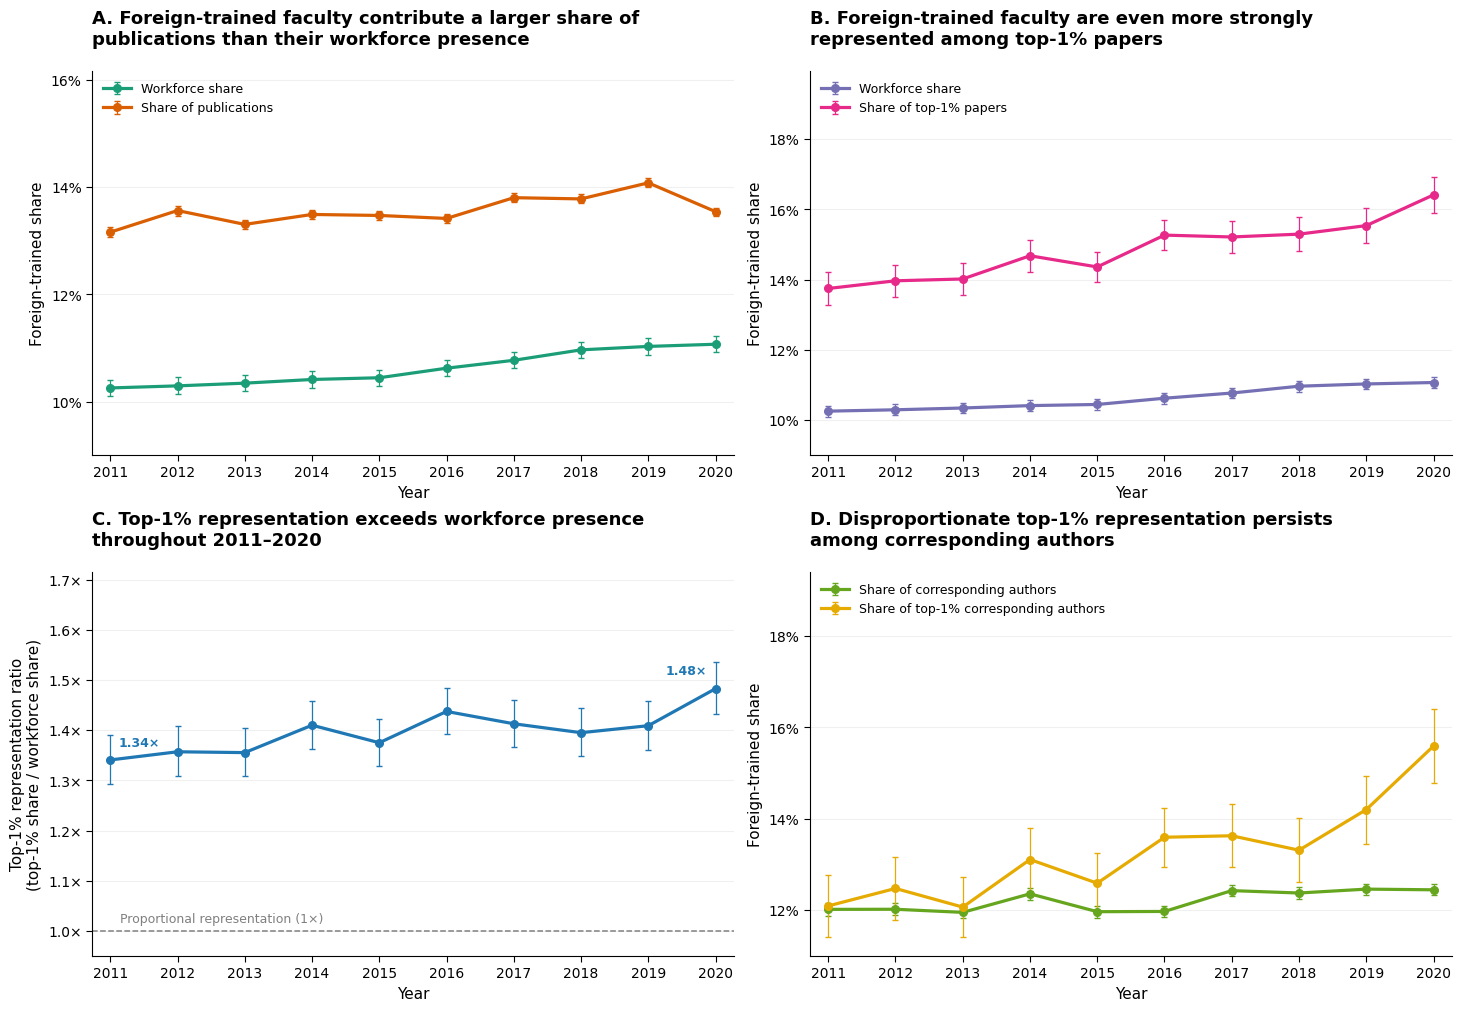

Saved:
 - figure1_top_level.png
 - figure1_top_level.pdf


In [ ]:
# Figure 1: publication-quality version
# Output:
#   - figure1_top_level.png
#   - figure1_top_level.pdf

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator, FormatStrFormatter

# ---------------------------------------------------
# Load data
# ---------------------------------------------------
client = bigquery.Client(project="foreign-phd")

df = client.query("""
    SELECT *
    FROM `foreign-phd.new.figure1_annual_metrics`
    ORDER BY year
""").to_dataframe()

df = df.sort_values("year").reset_index(drop=True)
years = df["year"].astype(int).to_numpy()

# ---------------------------------------------------
# Statistical helpers
# ---------------------------------------------------
def prop_ci(p, n, z=1.96):
    p = np.asarray(p, dtype=float)
    n = np.maximum(np.asarray(n, dtype=float), 1.0)

    se = np.sqrt(np.maximum(p * (1.0 - p), 0.0) / n)

    lo = np.clip(p - z * se, 0.0, 1.0)
    hi = np.clip(p + z * se, 0.0, 1.0)

    return lo, hi


def ratio_ci(p_num, n_num, p_den, n_den, z=1.96):
    p_num = np.clip(np.asarray(p_num, dtype=float), 1e-9, 1.0)
    p_den = np.clip(np.asarray(p_den, dtype=float), 1e-9, 1.0)

    n_num = np.maximum(np.asarray(n_num, dtype=float), 1.0)
    n_den = np.maximum(np.asarray(n_den, dtype=float), 1.0)

    ratio = p_num / p_den

    se_log = np.sqrt(
        (1.0 - p_num) / (n_num * p_num) +
        (1.0 - p_den) / (n_den * p_den)
    )

    lo = ratio * np.exp(-z * se_log)
    hi = ratio * np.exp(z * se_log)

    return lo, hi


# ---------------------------------------------------
# Plot helpers
# ---------------------------------------------------
def style_panel(ax, letter, title):
    ax.text(
        0.0,
        1.06,
        f"{letter}. {title}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

    ax.grid(True, axis="y", alpha=0.18, linewidth=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=10,
        direction="out",
        length=4,
        width=0.8
    )

    ax.margins(x=0.03)


def percent_axis(ax):
    ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=1.0, decimals=0)
    )
    ax.yaxis.set_major_locator(
        MultipleLocator(0.02)
    )


# ---------------------------------------------------
# Data
# ---------------------------------------------------
workforce = df["workforce_share_foreign"].to_numpy()
publication = df["publication_share_foreign"].to_numpy()
top1 = df["top1_share_foreign"].to_numpy()
representation = df["elite_dependency_ratio"].to_numpy()

corresp = df["corresponding_share_foreign"].to_numpy()
corresp_top1 = df["corresponding_top1_share_foreign"].to_numpy()

# denominators
n_work = df["faculty_total"].to_numpy()
n_pub = df["total_papers"].to_numpy()
n_top1 = df["top1_total"].to_numpy()

n_cor = df["corresp_total"].to_numpy()
n_cor_top1 = df["corresp_top1_total"].to_numpy()

# confidence intervals
work_lo, work_hi = prop_ci(workforce, n_work)
pub_lo, pub_hi = prop_ci(publication, n_pub)
top1_lo, top1_hi = prop_ci(top1, n_top1)

cor_lo, cor_hi = prop_ci(corresp, n_cor)
cor_top1_lo, cor_top1_hi = prop_ci(corresp_top1, n_cor_top1)

rep_lo, rep_hi = ratio_ci(
    top1,
    n_top1,
    workforce,
    n_work
)


# ---------------------------------------------------
# Publication-style global formatting
# ---------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "lines.linewidth": 2.3,
    "lines.markersize": 5.5
})


# ---------------------------------------------------
# Distinct palettes
# ---------------------------------------------------

# Panel A
A1 = "#1b9e77"   # teal
A2 = "#d95f02"   # orange

# Panel B
B1 = "#7570b3"   # purple
B2 = "#e7298a"   # magenta

# Panel C
C1 = "#1f78b4"   # blue

# Panel D
D1 = "#66a61e"   # green
D2 = "#e6ab02"   # gold


# ---------------------------------------------------
# Create figure
# ---------------------------------------------------
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14.5, 10),
    constrained_layout=True
)

axes = axes.ravel()


# ===================================================
# Panel A
# ===================================================
ax = axes[0]

ax.errorbar(
    years,
    workforce,
    yerr=[workforce - work_lo, work_hi - workforce],
    fmt="-o",
    color=A1,
    ecolor=A1,
    capsize=2.5,
    elinewidth=0.9,
    label="Workforce share"
)

ax.errorbar(
    years,
    publication,
    yerr=[publication - pub_lo, pub_hi - publication],
    fmt="-o",
    color=A2,
    ecolor=A2,
    capsize=2.5,
    elinewidth=0.9,
    label="Share of publications"
)

style_panel(
    ax,
    "A",
    "Foreign-trained faculty contribute a larger share of\n"
    "publications than their workforce presence"
)

percent_axis(ax)

ax.set_ylabel("Foreign-trained share")
ax.set_xlabel("Year")

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_ylim(
    0.09,
    max(pub_hi.max(), workforce.max()) + 0.02
)

ax.legend(
    frameon=False,
    loc="upper left",
    handlelength=2.2
)


# ===================================================
# Panel B
# ===================================================
ax = axes[1]

ax.errorbar(
    years,
    workforce,
    yerr=[workforce - work_lo, work_hi - workforce],
    fmt="-o",
    color=B1,
    ecolor=B1,
    capsize=2.5,
    elinewidth=0.9,
    label="Workforce share"
)

ax.errorbar(
    years,
    top1,
    yerr=[top1 - top1_lo, top1_hi - top1],
    fmt="-o",
    color=B2,
    ecolor=B2,
    capsize=2.5,
    elinewidth=0.9,
    label="Share of top-1% papers"
)

style_panel(
    ax,
    "B",
    "Foreign-trained faculty are even more strongly\n"
    "represented among top-1% papers"
)

percent_axis(ax)

ax.set_ylabel("Foreign-trained share")
ax.set_xlabel("Year")

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_ylim(
    0.09,
    max(top1_hi.max(), workforce.max()) + 0.03
)

ax.legend(
    frameon=False,
    loc="upper left",
    handlelength=2.2
)


# ===================================================
# Panel C
# ===================================================
ax = axes[2]

ax.errorbar(
    years,
    representation,
    yerr=[
        representation - rep_lo,
        rep_hi - representation
    ],
    fmt="-o",
    color=C1,
    ecolor=C1,
    capsize=2.5,
    elinewidth=0.9
)

# proportional-representation benchmark
ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.1,
    color="gray"
)

# Direct label for benchmark
ax.text(
    years[0] + 0.15,
    1.012,
    "Proportional representation (1×)",
    fontsize=9,
    color="gray",
    ha="left",
    va="bottom"
)

style_panel(
    ax,
    "C",
    "Top-1% representation exceeds workforce presence\n"
    "throughout 2011–2020"
)

ax.set_ylabel(
    "Top-1% representation ratio\n"
    "(top-1% share / workforce share)"
)
ax.set_xlabel("Year")

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.yaxis.set_major_locator(
    MultipleLocator(0.1)
)
ax.yaxis.set_major_formatter(
    FormatStrFormatter("%.1f×")
)

ax.set_ylim(
    0.95,
    max(rep_hi.max(), 1.0) + 0.18
)

# Beginning annotation
ax.annotate(
    f"{representation[0]:.2f}×",
    xy=(years[0], representation[0]),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=9,
    color=C1,
    fontweight="bold",
    ha="left",
    va="bottom"
)

# Ending annotation
ax.annotate(
    f"{representation[-1]:.2f}×",
    xy=(years[-1], representation[-1]),
    xytext=(-6, 8),
    textcoords="offset points",
    fontsize=9,
    color=C1,
    fontweight="bold",
    ha="right",
    va="bottom"
)


# ===================================================
# Panel D
# ===================================================
ax = axes[3]

ax.errorbar(
    years,
    corresp,
    yerr=[corresp - cor_lo, cor_hi - corresp],
    fmt="-o",
    color=D1,
    ecolor=D1,
    capsize=2.5,
    elinewidth=0.9,
    label="Share of corresponding authors"
)

ax.errorbar(
    years,
    corresp_top1,
    yerr=[
        corresp_top1 - cor_top1_lo,
        cor_top1_hi - corresp_top1
    ],
    fmt="-o",
    color=D2,
    ecolor=D2,
    capsize=2.5,
    elinewidth=0.9,
    label="Share of top-1% corresponding authors"
)

style_panel(
    ax,
    "D",
    "Disproportionate top-1% representation persists\n"
    "among corresponding authors"
)

percent_axis(ax)

ax.set_ylabel("Foreign-trained share")
ax.set_xlabel("Year")

ax.set_xticks(years)
ax.set_xticklabels(years)

ax.set_ylim(
    0.11,
    max(cor_top1_hi.max(), corresp.max()) + 0.03
)

ax.legend(
    frameon=False,
    loc="upper left",
    handlelength=2.2
)


# ---------------------------------------------------
# Save outputs
# ---------------------------------------------------
fig.savefig(
    "figure1_top_level.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "figure1_top_level.pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(" - figure1_top_level.png")
print(" - figure1_top_level.pdf")

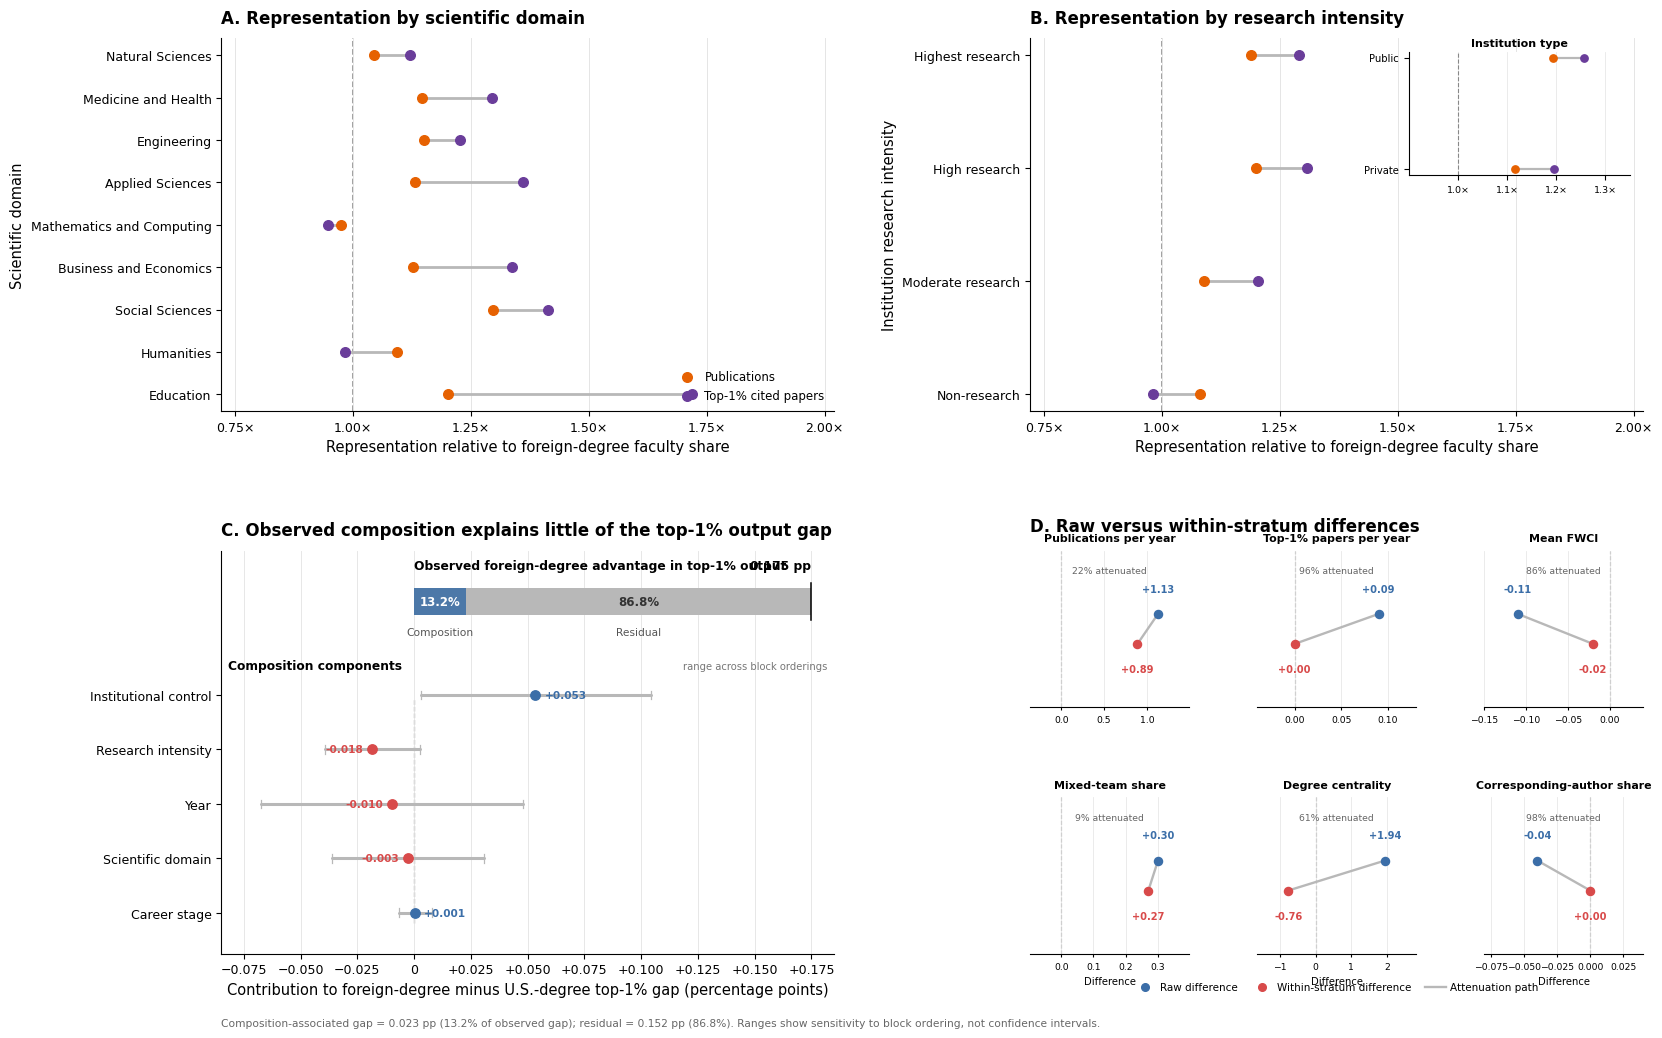

In [ ]:
# ============================================================
# FIGURE 2 — FINAL REDESIGN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from google.cloud import bigquery


# ============================================================
# 0. STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})

# Keep these consistent with Figure 1 if Figure 1 uses
# slightly different exact colors.
COL_PUBLICATION = "#E66101"   # orange
COL_TOP1        = "#6A3D9A"   # purple

COL_POS         = "#3B6EA8"   # positive decomposition contribution
COL_NEG         = "#D84A4A"   # negative decomposition contribution

COL_RAW         = "#3B6EA8"
COL_MATCHED     = "#D84A4A"

COL_COMPOSITION = "#4C78A8"
COL_RESIDUAL    = "#B8B8B8"

CONNECTOR_COLOR = "#B8B8B8"
ZERO_COLOR      = "#888888"
GRID_COLOR      = "#E5E5E5"


# ============================================================
# 1. LOAD DATA
# ============================================================

client = bigquery.Client(project="foreign-phd")

abc = client.query("""
SELECT *
FROM `foreign-phd.new.figure2_panel_abc`
""").to_dataframe().copy()

src = client.query("""
SELECT *
FROM `foreign-phd.new.figure2_model_agg`
""").to_dataframe().copy()

decomp_src = client.query("""
SELECT *
FROM `foreign-phd.new.figure2_fairlie_source`
""").to_dataframe().copy()

matched_src = client.query("""
SELECT *
FROM `foreign-phd.new.figure_matched_faculty_year`
""").to_dataframe().copy()


# ============================================================
# 2. PANEL A / B DATA
# ============================================================

df = abc.copy()

numeric_cols = [
    "faculty_share_foreign",
    "publication_share_foreign",
    "top1_share_foreign",
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


# Representation relative to foreign-degree faculty share.
# 1.0 = proportional representation.
df["publication_ratio"] = (
    df["publication_share_foreign"]
    / df["faculty_share_foreign"]
)

df["top1_ratio"] = (
    df["top1_share_foreign"]
    / df["faculty_share_foreign"]
)


# ------------------------------------------------------------
# Domain ordering
# ------------------------------------------------------------

domain_order = [
    "Natural Sciences",
    "Medicine and Health",
    "Engineering",
    "Applied Sciences",
    "Mathematics and Computing",
    "Business and Economics",
    "Social Sciences",
    "Humanities",
    "Education",
]

domain_df = (
    df.loc[
        (df["dimension"] == "umbrella_domain")
        & (df["level"].isin(domain_order))
    ]
    .set_index("level")
    .reindex(domain_order)
    .reset_index()
)


# ------------------------------------------------------------
# Research-intensity ordering
# ------------------------------------------------------------

research_order = [
    "Highest research",
    "High research",
    "Moderate research",
    "Non-research",
]

research_df = (
    df.loc[
        (df["dimension"] == "research_intensity")
        & (df["level"].isin(research_order))
    ]
    .set_index("level")
    .reindex(research_order)
    .reset_index()
)


# ------------------------------------------------------------
# Institution control — used only as inset in Panel B
# ------------------------------------------------------------

control_order = [
    "Public",
    "Private",
]

control_df = (
    df.loc[
        (df["dimension"] == "institution_control")
        & (df["level"].isin(control_order))
    ]
    .set_index("level")
    .reindex(control_order)
    .reset_index()
)


# ============================================================
# 3. PANEL C — FINAL COMPLETED DECOMPOSITION
# ============================================================
#
# IMPORTANT:
# These are the FINAL values from the completed nonlinear
# decomposition.
#
# DO NOT rerun the computationally expensive decomposition
# here.
#
# Observed gap                         = 0.175 pp
# Composition-associated gap          = 0.023 pp
# Residual                            = 0.152 pp
# Share associated with composition   = 13.2%
# Residual share                      = 86.8%
# ============================================================

observed_gap = 0.175
composition_gap = 0.023
residual_gap = 0.152

composition_share = 13.2
residual_share = 86.8


decomp = pd.DataFrame({
    "component": [
        "Institutional control",
        "Research intensity",
        "Year",
        "Scientific domain",
        "Career stage",
    ],

    "estimate": [
        0.053386,
        -0.018344,
        -0.009777,
        -0.002650,
        0.000504,
    ],

    "order_low": [
        0.002848,
        -0.039215,
        -0.067337,
        -0.036252,
        -0.006815,
    ],

    "order_high": [
        0.104287,
        0.002471,
        0.048139,
        0.030899,
        0.007973,
    ],
})


# ============================================================
# 4. PANEL D — RAW VS WITHIN-STRATUM DIFFERENCES
# ============================================================

panel_d = pd.DataFrame({
    "outcome": [
        "Publications per year",
        "Top-1% papers per year",
        "Mean FWCI",
        "Mixed-team share",
        "Degree centrality",
        "Corresponding-author share",
    ],

    "raw": [
        1.13,
        0.09,
        -0.11,
        0.30,
        1.94,
        -0.04,
    ],

    "matched": [
        0.89,
        0.00,
        -0.02,
        0.27,
        -0.76,
        0.00,
    ],

    "attenuation": [
        22,
        96,
        86,
        9,
        61,
        98,
    ],
})


# ============================================================
# 5. HELPER — REPRESENTATION DOT-RANGE PANEL
# ============================================================

def representation_panel(
    ax,
    data,
    labels,
    title,
    ylabel=None,
    show_legend=False,
):

    y = np.arange(len(data))

    pub = data["publication_ratio"].to_numpy()
    top = data["top1_ratio"].to_numpy()

    # Connector between publication and top-1% representation
    for yi, x1, x2 in zip(y, pub, top):
        ax.plot(
            [x1, x2],
            [yi, yi],
            color=CONNECTOR_COLOR,
            lw=2.0,
            zorder=1,
        )

    ax.scatter(
        pub,
        y,
        s=48,
        color=COL_PUBLICATION,
        zorder=3,
        label="Publications",
    )

    ax.scatter(
        top,
        y,
        s=48,
        color=COL_TOP1,
        zorder=3,
        label="Top-1% cited papers",
    )

    # Proportional representation reference
    ax.axvline(
        1,
        color=ZERO_COLOR,
        ls="--",
        lw=1.1,
        zorder=0,
    )

    # Small label directly above reference line


    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()

    ax.set_xlim(0.72, 2.02)

    ticks = [
        0.75,
        1.00,
        1.25,
        1.50,
        1.75,
        2.00,
    ]

    ax.set_xticks(ticks)
    ax.set_xticklabels(
        [f"{x:.2f}×" for x in ticks]
    )

    ax.set_xlabel(
        "Representation relative to foreign-degree faculty share"
    )

    if ylabel:
        ax.set_ylabel(ylabel)

    ax.set_title(
        title,
        loc="left",
        fontweight="bold",
        pad=11,
    )

    ax.grid(
        axis="x",
        color=GRID_COLOR,
        lw=0.7,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_legend:
        ax.legend(
            frameon=False,
            loc="lower right",
            handletextpad=0.5,
            borderaxespad=0.4,
        )


# ============================================================
# 6. CREATE FIGURE
# ============================================================
#
# No figure-level title or subtitle.
# This keeps Figure 2 consistent with Figure 1.
# The manuscript caption should carry the figure title.
# ============================================================

fig = plt.figure(
    figsize=(15.8, 10.4),
    constrained_layout=False,
)

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,

    left=0.075,
    right=0.975,

    bottom=0.075,
    top=0.955,

    wspace=0.32,
    hspace=0.36,

    height_ratios=[
        1.00,
        1.08,
    ],
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])

# Used only to reserve the Panel-D region and hold its title/legend
axD_container = fig.add_subplot(gs[1, 1])


# ============================================================
# PANEL A
# Representation across scientific domains
# ============================================================

representation_panel(
    axA,
    domain_df,
    domain_df["level"],
    "A. Representation by scientific domain",
    ylabel="Scientific domain",
    show_legend=True,
)


# ============================================================
# PANEL B
# Representation across research intensity
# ============================================================

representation_panel(
    axB,
    research_df,
    research_df["level"],
    "B. Representation by research intensity",
    ylabel="Institution research intensity",
    show_legend=False,
)


# ------------------------------------------------------------
# Interpretive note
# ------------------------------------------------------------




# ------------------------------------------------------------
# Institution-type inset
# ------------------------------------------------------------

axB_in = inset_axes(
    axB,
    width="36%",
    height="33%",
    loc="upper right",
    borderpad=1.15,
)

y_in = np.arange(len(control_df))

pub_in = control_df["publication_ratio"].to_numpy()
top_in = control_df["top1_ratio"].to_numpy()


for yi, x1, x2 in zip(y_in, pub_in, top_in):

    axB_in.plot(
        [x1, x2],
        [yi, yi],
        color=CONNECTOR_COLOR,
        lw=1.6,
        zorder=1,
    )


axB_in.scatter(
    pub_in,
    y_in,
    s=28,
    color=COL_PUBLICATION,
    zorder=3,
)

axB_in.scatter(
    top_in,
    y_in,
    s=28,
    color=COL_TOP1,
    zorder=3,
)


axB_in.axvline(
    1,
    color=ZERO_COLOR,
    ls="--",
    lw=0.8,
)


axB_in.set_yticks(y_in)

axB_in.set_yticklabels(
    control_df["level"],
    fontsize=7.2,
)

axB_in.invert_yaxis()


# Deliberately narrow scale:
# institution-type differences are much smaller than
# research-intensity differences.
axB_in.set_xlim(
    0.90,
    1.35,
)

axB_in.set_xticks([
    1.0,
    1.1,
    1.2,
    1.3,
])

axB_in.set_xticklabels(
    [
        "1.0×",
        "1.1×",
        "1.2×",
        "1.3×",
    ],
    fontsize=6.8,
)


axB_in.set_title(
    "Institution type",
    fontsize=8,
    fontweight="bold",
    pad=4,
)


axB_in.grid(
    axis="x",
    color=GRID_COLOR,
    lw=0.55,
)

axB_in.set_axisbelow(True)

axB_in.spines["top"].set_visible(False)
axB_in.spines["right"].set_visible(False)


# ============================================================
# PANEL C
# Composition versus residual gap
# ============================================================

axC.set_title(
    "C. Observed composition explains little of the top-1% output gap",
    loc="left",
    fontweight="bold",
    pad=11,
)


# Custom coordinate system
axC.set_xlim(
    -0.085,
    0.185,
)

axC.set_ylim(
    -0.75,
    6.65,
)


# ------------------------------------------------------------
# C1. Overall decomposition bar
# ------------------------------------------------------------

bar_y = 5.72
bar_height = 0.50


# Composition-associated portion
axC.barh(
    bar_y,
    composition_gap,
    left=0,
    height=bar_height,
    color=COL_COMPOSITION,
    edgecolor="none",
    zorder=2,
)


# Residual
axC.barh(
    bar_y,
    residual_gap,
    left=composition_gap,
    height=bar_height,
    color=COL_RESIDUAL,
    edgecolor="none",
    zorder=2,
)


# Endpoint marking observed gap
axC.plot(
    [
        observed_gap,
        observed_gap,
    ],
    [
        bar_y - 0.34,
        bar_y + 0.34,
    ],
    color="black",
    lw=1.1,
    zorder=3,
)


# Header
axC.text(
    0,
    6.32,
    "Observed foreign-degree advantage in top-1% output",
    fontsize=8.8,
    fontweight="bold",
    ha="left",
)


axC.text(
    observed_gap,
    6.32,
    f"{observed_gap:.3f} pp",
    fontsize=8.8,
    fontweight="bold",
    ha="right",
)


# Share labels
axC.text(
    composition_gap / 2,
    bar_y,
    f"{composition_share:.1f}%",
    ha="center",
    va="center",
    color="white",
    fontsize=8.5,
    fontweight="bold",
)


axC.text(
    composition_gap + residual_gap / 2,
    bar_y,
    f"{residual_share:.1f}%",
    ha="center",
    va="center",
    color="#333333",
    fontsize=8.5,
    fontweight="bold",
)


# Labels beneath bar
axC.text(
    composition_gap / 2,
    bar_y - 0.48,
    "Composition",
    ha="center",
    va="top",
    fontsize=7.7,
    color="#555555",
)


axC.text(
    composition_gap + residual_gap / 2,
    bar_y - 0.48,
    "Residual",
    ha="center",
    va="top",
    fontsize=7.7,
    color="#555555",
)


# ------------------------------------------------------------
# C2. Decomposition components
# ------------------------------------------------------------

axC.text(
    -0.082,
    4.47,
    "Composition components",
    fontsize=8.8,
    fontweight="bold",
    ha="left",
)


axC.text(
    0.182,
    4.47,
    "range across block orderings",
    fontsize=7.2,
    color="#777777",
    ha="right",
)


component_y = np.arange(
    len(decomp) - 1,
    -1,
    -1,
)


# Zero contribution reference
axC.axvline(
    0,
    ymin=0.075,
    ymax=0.635,
    color=ZERO_COLOR,
    ls="--",
    lw=0.9,
    zorder=0,
)


for yi, row in zip(
    component_y,
    decomp.itertuples(),
):

    # Sensitivity to ordering
    axC.plot(
        [
            row.order_low,
            row.order_high,
        ],
        [
            yi,
            yi,
        ],
        color="#B8B8B8",
        lw=2.2,
        solid_capstyle="round",
        zorder=1,
    )

    # End caps
    axC.plot(
        [
            row.order_low,
            row.order_low,
        ],
        [
            yi - 0.08,
            yi + 0.08,
        ],
        color="#B8B8B8",
        lw=0.9,
    )

    axC.plot(
        [
            row.order_high,
            row.order_high,
        ],
        [
            yi - 0.08,
            yi + 0.08,
        ],
        color="#B8B8B8",
        lw=0.9,
    )


    col = (
        COL_POS
        if row.estimate >= 0
        else COL_NEG
    )


    axC.scatter(
        row.estimate,
        yi,
        s=46,
        color=col,
        zorder=3,
    )


    # Estimate labels
    if row.estimate >= 0:

        label_x = row.estimate + 0.004
        ha = "left"

    else:

        label_x = row.estimate - 0.004
        ha = "right"


    axC.text(
        label_x,
        yi,
        f"{row.estimate:+.3f}",
        ha=ha,
        va="center",
        fontsize=7.6,
        color=col,
        fontweight="bold",
    )


axC.set_yticks(component_y)

axC.set_yticklabels(
    decomp["component"],
)


axC.set_xlabel(
    "Contribution to foreign-degree minus U.S.-degree top-1% gap "
    "(percentage points)"
)


axC.set_xticks([
    -0.075,
    -0.050,
    -0.025,
    0,
    0.025,
    0.050,
    0.075,
    0.100,
    0.125,
    0.150,
    0.175,
])


axC.set_xticklabels([
    "−0.075",
    "−0.050",
    "−0.025",
    "0",
    "+0.025",
    "+0.050",
    "+0.075",
    "+0.100",
    "+0.125",
    "+0.150",
    "+0.175",
])


axC.grid(
    axis="x",
    color=GRID_COLOR,
    lw=0.65,
)

axC.set_axisbelow(True)

axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)


# Compact statistical note
axC.text(
    0,
    -0.16,
    "Composition-associated gap = 0.023 pp (13.2% of observed gap); "
    "residual = 0.152 pp (86.8%). "
    "Ranges show sensitivity to block ordering, not confidence intervals.",
    transform=axC.transAxes,
    fontsize=7.7,
    color="#666666",
    ha="left",
    va="top",
)


# ============================================================
# PANEL D
# Raw versus within-stratum differences
# ============================================================

# Container is only used for panel title and legend.
axD_container.axis("off")


axD_container.set_title(
    "D. Raw versus within-stratum differences",
    loc="left",
    fontweight="bold",
    pad=11,
    y=1.01,
)


subgs = gs[1, 1].subgridspec(
    2,
    3,
    wspace=0.43,
    hspace=0.58,
)


d_axes = []


for i in range(6):

    r = i // 3
    c = i % 3

    ax = fig.add_subplot(
        subgs[r, c]
    )

    d_axes.append(ax)

    row = panel_d.iloc[i]

    raw = row["raw"]
    matched = row["matched"]


    # Outcome-specific range
    vals = np.array([
        0,
        raw,
        matched,
    ])

    xmin = vals.min()
    xmax = vals.max()

    span = xmax - xmin

    if span == 0:
        span = 0.1

    pad = max(
        span * 0.32,
        0.04,
    )

    ax.set_xlim(
        xmin - pad,
        xmax + pad,
    )

    ax.set_ylim(
        -0.52,
        0.52,
    )


    # Zero reference
    ax.axvline(
        0,
        color=ZERO_COLOR,
        ls="--",
        lw=0.8,
        zorder=0,
    )


    # Attenuation path
    ax.plot(
        [
            raw,
            matched,
        ],
        [
            0.10,
            -0.10,
        ],
        color=CONNECTOR_COLOR,
        lw=1.7,
        zorder=1,
    )


    # Raw
    ax.scatter(
        raw,
        0.10,
        s=34,
        color=COL_RAW,
        zorder=3,
    )


    # Within-stratum
    ax.scatter(
        matched,
        -0.10,
        s=34,
        color=COL_MATCHED,
        zorder=3,
    )


    # Raw value
    ax.text(
        raw,
        0.235,
        f"{raw:+.2f}",
        ha="center",
        va="bottom",
        fontsize=7.1,
        color=COL_RAW,
        fontweight="bold",
    )


    # Within-stratum value
    ax.text(
        matched,
        -0.235,
        f"{matched:+.2f}",
        ha="center",
        va="top",
        fontsize=7.1,
        color=COL_MATCHED,
        fontweight="bold",
    )


    # Outcome title
    ax.set_title(
        row["outcome"],
        fontsize=7.9,
        fontweight="bold",
        pad=7,
    )


    # Attenuation label
    ax.text(
        0.5,
        0.90,
        f"{row['attenuation']:.0f}% attenuated",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=6.7,
        color="#666666",
    )


    ax.set_yticks([])

    ax.tick_params(
        axis="x",
        labelsize=6.7,
        length=2.5,
    )


    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


    ax.grid(
        axis="x",
        color=GRID_COLOR,
        lw=0.55,
    )

    ax.set_axisbelow(True)


    # Only bottom row needs x-axis title
    if r == 1:

        ax.set_xlabel(
            "Difference",
            fontsize=7.2,
        )


# ------------------------------------------------------------
# Panel-D legend
# ------------------------------------------------------------

legend_D = [

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=COL_RAW,
        markeredgecolor=COL_RAW,
        markersize=5.5,
        label="Raw difference",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=COL_MATCHED,
        markeredgecolor=COL_MATCHED,
        markersize=5.5,
        label="Within-stratum difference",
    ),

    Line2D(
        [0],
        [0],
        color=CONNECTOR_COLOR,
        lw=1.7,
        label="Attenuation path",
    ),
]


axD_container.legend(
    handles=legend_D,
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        -0.12,
    ),
    ncol=3,
    frameon=False,
    fontsize=7.5,
    columnspacing=1.3,
    handletextpad=0.45,
)


# ============================================================
# 7. SAVE
# ============================================================

plt.savefig(
    "figure2_redesigned.png",
    dpi=400,
    bbox_inches="tight",
)

plt.savefig(
    "figure2_redesigned.pdf",
    bbox_inches="tight",
)

plt.show()

In [ ]:
# =============================================================================
# FIGURE 3 — FINAL ANALYSIS / INFERENCE
#
# PANEL A
#   Adjusted foreign-domestic differences in social-network structure:
#
#       Network reach
#       Network breadth
#       Tie depth
#
#   Adjustment:
#       year FE
#       domain FE
#       research-intensity FE
#
#   NO productivity control in primary specification.
#
#   Network outcomes standardized over the Panel A analytical sample.
#
#   SE clustered by author.
#
#
# PANEL B
#   Current-year top-1% output:
#
#       prior-three-year network reach
#       × foreign-trained status
#
#   Adjustment:
#       year FE
#       domain FE
#       research-intensity FE
#
#   NO productivity control in primary specification.
#
#   Grouped-binomial GLM:
#
#       successes = top1_papers
#       failures  = papers - top1_papers
#
#   Author-clustered sandwich covariance calculated directly from
#   author-year score contributions.
#
#
# OUTPUT
#
#   figure3_panel_a_results.csv
#   figure3_panel_a_descriptives.csv
#   figure3_panel_b_results.csv
#   figure3_panel_b_predictions.csv
#   figure3_panel_b_gap.csv
#
# =============================================================================


import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf

from patsy import dmatrix

from google.cloud import bigquery


# =============================================================================
# 0. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final"
)

client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 1. LOAD
# =============================================================================

query = f"""
SELECT *
FROM `{TABLE}`
WHERE year BETWEEN 2011 AND 2020
"""

df = (
    client
    .query(query)
    .to_dataframe()
)


print("=" * 80)
print("FIGURE 3 — FINAL ANALYSIS / INFERENCE")
print("=" * 80)

print(
    f"\nRows:    "
    f"{len(df):,}"
)

print(
    f"Authors: "
    f"{df['author_id'].nunique():,}"
)

print(
    f"Years:   "
    f"{pd.to_numeric(df['year']).min():.0f}"
    f"–"
    f"{pd.to_numeric(df['year']).max():.0f}"
)


# =============================================================================
# 2. REQUIRED COLUMNS
# =============================================================================

required = [

    "author_id",
    "year",

    "phd_type",

    "primary_domain",
    "research_intensity_level",

    "papers",
    "top1_papers",

    "prior3_papers",

    "prior3_degree",
    "prior3_log_degree",

    "prior3_effective_collaborators",
    "prior3_log_effective_collaborators",

    "prior3_mean_tie_strength",

    "panel_a_eligible",
    "panel_b_eligible",
]


missing = [
    x
    for x in required
    if x not in df.columns
]


if missing:

    raise ValueError(
        "Missing required columns:\n"
        +
        "\n".join(missing)
    )


# =============================================================================
# 3. CLEAN TYPES
# =============================================================================

numeric_cols = [

    "year",

    "research_intensity_level",

    "papers",
    "top1_papers",

    "prior3_papers",

    "prior3_degree",
    "prior3_log_degree",

    "prior3_effective_collaborators",
    "prior3_log_effective_collaborators",

    "prior3_mean_tie_strength",

    "panel_a_eligible",
    "panel_b_eligible",
]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df[
    df["year"].notna()
].copy()


df["year"] = (
    df["year"]
    .astype(int)
)


df["phd_type"] = (
    df["phd_type"]
    .astype(str)
    .str.lower()
    .str.strip()
)


df = df[
    df["phd_type"].isin(
        [
            "domestic",
            "foreign",
        ]
    )
].copy()


# ---------------------------------------------------------------------------
# Categorical controls
# ---------------------------------------------------------------------------

df["year_cat"] = (
    df["year"]
    .astype(str)
)


df["domain_cat"] = (
    df["primary_domain"]
    .fillna("Unknown")
    .astype(str)
)


df["research_cat"] = (
    df["research_intensity_level"]
    .fillna(-999)
    .astype(str)
)


# =============================================================================
# 4. PANEL A SAMPLE
#
# Current-year publication is deliberately NOT required.
# =============================================================================

panel_a = df.loc[
    (df["panel_a_eligible"] == 1)
    &
    df["prior3_log_degree"].notna()
    &
    df[
        "prior3_log_effective_collaborators"
    ].notna()
    &
    df[
        "prior3_mean_tie_strength"
    ].notna()
].copy()


# =============================================================================
# 5. PANEL B SAMPLE
#
# Current-year publication IS required.
# =============================================================================

panel_b = df.loc[
    (df["panel_b_eligible"] == 1)
    &
    (df["papers"] > 0)
    &
    df["prior3_log_degree"].notna()
].copy()


print(
    "\n"
    + "=" * 80
)

print(
    "ANALYTICAL SAMPLES"
)

print(
    "=" * 80
)


print(
    "\nPANEL A — NETWORK POSITION"
)

print(
    f"Author-years: "
    f"{len(panel_a):,}"
)

print(
    f"Authors:      "
    f"{panel_a['author_id'].nunique():,}"
)


print(
    "\nPANEL B — ELITE IMPACT"
)

print(
    f"Author-years: "
    f"{len(panel_b):,}"
)

print(
    f"Authors:      "
    f"{panel_b['author_id'].nunique():,}"
)

print(
    f"Papers:       "
    f"{panel_b['papers'].sum():,.0f}"
)

print(
    f"Top-1%:       "
    f"{panel_b['top1_papers'].sum():,.0f}"
)

print(
    f"Top-1% rate:  "
    f"{panel_b['top1_papers'].sum() / panel_b['papers'].sum():.3%}"
)


# =============================================================================
# 6. PANEL A DESCRIPTIVES
# =============================================================================

panel_a_descriptives = (

    panel_a
    .groupby(
        "phd_type"
    )
    .agg(

        author_years=(
            "author_id",
            "size"
        ),

        authors=(
            "author_id",
            "nunique"
        ),

        degree_mean=(
            "prior3_degree",
            "mean"
        ),

        degree_median=(
            "prior3_degree",
            "median"
        ),

        breadth_mean=(
            "prior3_effective_collaborators",
            "mean"
        ),

        breadth_median=(
            "prior3_effective_collaborators",
            "median"
        ),

        tie_depth_mean=(
            "prior3_mean_tie_strength",
            "mean"
        ),

        tie_depth_median=(
            "prior3_mean_tie_strength",
            "median"
        ),

        prior3_papers_mean=(
            "prior3_papers",
            "mean"
        ),
    )

    .reset_index()
)


print(
    "\n"
    + "=" * 80
)

print(
    "PANEL A — RAW DESCRIPTIVES"
)

print(
    "=" * 80
)

print(
    panel_a_descriptives
    .to_string(
        index=False
    )
)


# =============================================================================
# 7. STANDARDIZATION
#
# Panel A outcomes:
#
#   Reach:
#       z[ log(1 + degree) ]
#
#   Breadth:
#       z[ log(1 + effective collaborators) ]
#
#   Tie depth:
#       z[ mean tie strength ]
#
# Panel B exposure:
#
#       z[ log(1 + degree) ]
#
# Each is standardized within its own analytical sample.
# =============================================================================

def zscore(x):

    x = (
        pd.to_numeric(
            x,
            errors="coerce"
        )
        .astype(float)
    )

    sd = x.std(
        ddof=0
    )

    if (
        not np.isfinite(sd)
        or
        sd == 0
    ):

        raise ValueError(
            "Cannot standardize variable "
            "with zero/nonfinite SD."
        )

    return (
        x - x.mean()
    ) / sd


# Panel A
panel_a[
    "reach_outcome_z"
] = zscore(
    panel_a[
        "prior3_log_degree"
    ]
)


panel_a[
    "breadth_outcome_z"
] = zscore(
    panel_a[
        "prior3_log_effective_collaborators"
    ]
)


panel_a[
    "depth_outcome_z"
] = zscore(
    panel_a[
        "prior3_mean_tie_strength"
    ]
)


# Panel B
panel_b[
    "reach_z"
] = zscore(
    panel_b[
        "prior3_log_degree"
    ]
)


# Save transformation for interpretation
reach_log_mean = (
    panel_b[
        "prior3_log_degree"
    ].mean()
)

reach_log_sd = (
    panel_b[
        "prior3_log_degree"
    ].std(
        ddof=0
    )
)


# =============================================================================
# 8. PANEL A — ADJUSTED FOREIGN-DOMESTIC DIFFERENCES
#
# Primary specification:
#
#     network outcome
#         ~ foreign
#         + year FE
#         + domain FE
#         + research-intensity FE
#
# NO productivity adjustment.
#
# Clustered by author.
# =============================================================================

panel_a_specs = {

    "Network reach":
        "reach_outcome_z",

    "Network breadth":
        "breadth_outcome_z",

    "Tie depth":
        "depth_outcome_z",
}


panel_a_results = []


foreign_term = (
    'C(phd_type, '
    'Treatment(reference="domestic"))'
    '[T.foreign]'
)


for metric, outcome in (
    panel_a_specs.items()
):

    print(
        "\n"
        + "=" * 80
    )

    print(
        metric.upper()
    )

    print(
        "=" * 80
    )


    cols = [

        outcome,

        "phd_type",

        "year_cat",

        "domain_cat",

        "research_cat",

        "author_id",
    ]


    d = (

        panel_a[
            cols
        ]

        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan
        )

        .dropna()

        .copy()
    )


    d[outcome] = (
        pd.to_numeric(
            d[outcome],
            errors="coerce"
        )
        .astype(float)
    )


    for col in [
        "phd_type",
        "year_cat",
        "domain_cat",
        "research_cat",
        "author_id",
    ]:

        d[col] = (
            d[col]
            .astype(str)
        )


    formula = (

        f"{outcome} ~ "

        'C('
        'phd_type, '
        'Treatment(reference="domestic")'
        ') + '

        "C(year_cat) + "

        "C(domain_cat) + "

        "C(research_cat)"
    )


    model = (

        smf.ols(
            formula=formula,
            data=d
        )

        .fit(

            cov_type="cluster",

            cov_kwds={
                "groups":
                    d["author_id"]
            }
        )
    )


    beta = float(
        model.params[
            foreign_term
        ]
    )


    se = float(
        model.bse[
            foreign_term
        ]
    )


    p = float(
        model.pvalues[
            foreign_term
        ]
    )


    ci = (
        model
        .conf_int()
        .loc[
            foreign_term
        ]
    )


    ci_low = float(
        ci.iloc[0]
    )


    ci_high = float(
        ci.iloc[1]
    )


    panel_a_results.append({

        "metric":
            metric,

        "adjusted_difference_sd":
            beta,

        "ci_low":
            ci_low,

        "ci_high":
            ci_high,

        "se":
            se,

        "p":
            p,

        "author_years":
            len(d),

        "authors":
            d[
                "author_id"
            ].nunique(),
    })


    print(
        "Adjusted foreign-domestic "
        f"difference = {beta:+.4f} SD"
    )

    print(
        f"Clustered SE = "
        f"{se:.4f}"
    )

    print(
        "95% CI = "
        f"[{ci_low:+.4f}, "
        f"{ci_high:+.4f}]"
    )

    print(
        f"p = {p:.4g}"
    )


panel_a_results = pd.DataFrame(
    panel_a_results
)


print(
    "\n"
    + "=" * 80
)

print(
    "PANEL A — FINAL ADJUSTED RESULTS"
)

print(
    "=" * 80
)


print(
    panel_a_results[
        [
            "metric",
            "adjusted_difference_sd",
            "ci_low",
            "ci_high",
            "p",
            "author_years",
            "authors",
        ]
    ]
    .to_string(
        index=False
    )
)


# =============================================================================
# 9. PANEL B — BUILD GROUPED BINOMIAL DESIGN MATRIX
#
# We do NOT use freq_weights.
#
# Endogenous response:
#
#     column 1 = top1 papers
#     column 2 = non-top1 papers
#
# This is the standard grouped-binomial representation.
# =============================================================================

panel_b_cols = [

    "top1_papers",
    "papers",

    "reach_z",

    "phd_type",

    "year_cat",

    "domain_cat",

    "research_cat",

    "author_id",
]


d = (

    panel_b[
        panel_b_cols
    ]

    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan
    )

    .dropna()

    .copy()
)


for col in [
    "top1_papers",
    "papers",
    "reach_z",
]:

    d[col] = (
        pd.to_numeric(
            d[col],
            errors="coerce"
        )
        .astype(float)
    )


d = d[
    (d["papers"] > 0)
    &
    (d["top1_papers"] >= 0)
    &
    (
        d["top1_papers"]
        <=
        d["papers"]
    )
].copy()


for col in [
    "phd_type",
    "year_cat",
    "domain_cat",
    "research_cat",
    "author_id",
]:

    d[col] = (
        d[col]
        .astype(str)
    )


# ---------------------------------------------------------------------------
# Design matrix
# ---------------------------------------------------------------------------

rhs_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(domain_cat) + "

    "C(research_cat)"
)


X_df = dmatrix(

    rhs_formula,

    data=d,

    return_type="dataframe"
)


X = np.asarray(
    X_df,
    dtype=float
)


# ---------------------------------------------------------------------------
# Grouped-binomial outcome
# ---------------------------------------------------------------------------

successes = (
    d["top1_papers"]
    .to_numpy(
        dtype=float
    )
)


failures = (
    d["papers"]
    .to_numpy(
        dtype=float
    )
    -
    successes
)


endog = np.column_stack(
    [
        successes,
        failures,
    ]
)


# =============================================================================
# 10. FIT GROUPED-BINOMIAL GLM
# =============================================================================

print(
    "\n"
    + "=" * 80
)

print(
    "PANEL B — NETWORK REACH AND ELITE OUTPUT"
)

print(
    "=" * 80
)


glm_b = sm.GLM(

    endog=endog,

    exog=X,

    family=sm.families.Binomial()
)


fit_b = glm_b.fit()


# =============================================================================
# 11. AUTHOR-CLUSTERED SANDWICH COVARIANCE
#
# Cluster-robust covariance:
#
#     V = B M B
#
# where:
#
#     B = model-based covariance ("bread")
#
#     M = sum_g S_g S_g'
#
#     S_g = summed score contribution for author g
#
# Finite-sample correction:
#
#     G/(G-1) * (N-1)/(N-K)
#
# =============================================================================

score_obs = np.asarray(
    glm_b.score_obs(
        fit_b.params
    ),
    dtype=float
)


cluster_codes, cluster_labels = (
    pd.factorize(
        d["author_id"],
        sort=False
    )
)


G = len(
    cluster_labels
)


N = len(d)


K = X.shape[1]


# Sum score vectors within author
cluster_scores = np.zeros(
    (
        G,
        K,
    ),
    dtype=float
)


np.add.at(
    cluster_scores,
    cluster_codes,
    score_obs
)


meat = (
    cluster_scores.T
    @
    cluster_scores
)


bread = np.asarray(
    fit_b.normalized_cov_params,
    dtype=float
)


cluster_cov = (
    bread
    @
    meat
    @
    bread
)


# finite-sample correction
if G > 1 and N > K:

    correction = (
        G
        /
        (G - 1)
    ) * (
        (N - 1)
        /
        (N - K)
    )

    cluster_cov *= correction


cluster_se = np.sqrt(
    np.diag(
        cluster_cov
    )
)


# =============================================================================
# 12. PANEL B INTERACTION RESULT
# =============================================================================

coef_names = list(
    X_df.columns
)


interaction_candidates = [

    name

    for name in coef_names

    if (
        "reach_z" in name
        and
        "phd_type" in name
        and
        "foreign" in name
        and
        ":" in name
    )
]


if len(
    interaction_candidates
) != 1:

    raise ValueError(
        "Could not uniquely identify "
        "foreign × reach interaction.\n"
        f"Candidates: "
        f"{interaction_candidates}"
    )


interaction_term = (
    interaction_candidates[0]
)


interaction_idx = (
    coef_names.index(
        interaction_term
    )
)


beta = float(
    fit_b.params[
        interaction_idx
    ]
)


se = float(
    cluster_se[
        interaction_idx
    ]
)


z = (
    beta
    /
    se
)


# two-sided normal p
from scipy.stats import norm


p = float(
    2
    *
    norm.sf(
        abs(z)
    )
)


ci_low = (
    beta
    -
    1.96
    *
    se
)


ci_high = (
    beta
    +
    1.96
    *
    se
)


interaction_or = (
    np.exp(
        beta
    )
)


interaction_or_low = (
    np.exp(
        ci_low
    )
)


interaction_or_high = (
    np.exp(
        ci_high
    )
)


print(
    f"\nInteraction term:\n"
    f"{interaction_term}"
)


print(
    f"\nbeta = "
    f"{beta:.5f}"
)


print(
    f"author-clustered SE = "
    f"{se:.5f}"
)


print(
    f"z = "
    f"{z:.3f}"
)


print(
    f"p = "
    f"{p:.4g}"
)


print(
    "\nInteraction OR per "
    "+1 SD prior-3-year network reach = "
    f"{interaction_or:.3f} "
    f"[{interaction_or_low:.3f}, "
    f"{interaction_or_high:.3f}]"
)


panel_b_results = pd.DataFrame(
    [
        {

            "analysis":
                "Prior-3-year network reach",

            "interaction_beta":
                beta,

            "interaction_se":
                se,

            "interaction_OR":
                interaction_or,

            "interaction_OR_low":
                interaction_or_low,

            "interaction_OR_high":
                interaction_or_high,

            "interaction_p":
                p,

            "author_years":
                N,

            "authors":
                G,

            "papers":
                float(
                    d[
                        "papers"
                    ].sum()
                ),

            "top1_papers":
                float(
                    d[
                        "top1_papers"
                    ].sum()
                ),

            "reach_log_mean":
                float(
                    reach_log_mean
                ),

            "reach_log_sd":
                float(
                    reach_log_sd
                ),
        }
    ]
)


# =============================================================================
# 13. PANEL B — POPULATION-STANDARDIZED PREDICTIONS
#
# Marginal standardization:
#
# For every observed author-year:
#
#   retain:
#       observed year
#       observed domain
#       observed research intensity
#
#   set:
#       PhD type = domestic / foreign
#       network reach = specified z value
#
# Then average predicted probabilities.
#
# This avoids presenting predictions for one arbitrary field/year.
# =============================================================================

print(
    "\nComputing standardized predictions..."
)


reach_grid = np.linspace(
    -1.5,
    1.5,
    61
)


design_info = (
    X_df.design_info
)


prediction_base = d[
    [
        "year_cat",
        "domain_cat",
        "research_cat",
    ]
].copy()


def logistic(x):

    return (
        1.0
        /
        (
            1.0
            +
            np.exp(
                -np.clip(
                    x,
                    -35,
                    35
                )
            )
        )
    )


prediction_rows = []


for phd in [
    "domestic",
    "foreign",
]:

    print(
        f"  Predicting: "
        f"{phd}"
    )


    for reach_value in reach_grid:

        tmp = (
            prediction_base
            .copy()
        )


        tmp[
            "reach_z"
        ] = float(
            reach_value
        )


        tmp[
            "phd_type"
        ] = phd


        X_new = np.asarray(

            dmatrix(
                design_info,
                tmp,
                return_type="dataframe"
            ),

            dtype=float
        )


        eta = (
            X_new
            @
            fit_b.params
        )


        prob = logistic(
            eta
        )


        prediction_rows.append(
            {

                "phd_type":
                    phd,

                "reach_z":
                    float(
                        reach_value
                    ),

                "predicted_top1":
                    float(
                        prob.mean()
                    ),
            }
        )


predictions = pd.DataFrame(
    prediction_rows
)


# =============================================================================
# 14. PREDICTION CIs
#
# Parametric simulation from the author-clustered coefficient covariance.
#
# We integrate predictions over a reproducible sample of author-years to keep
# memory/runtime manageable.
# =============================================================================

print(
    "\nComputing prediction confidence intervals..."
)


rng = np.random.default_rng(
    20260827
)


MAX_PREDICTION_ROWS = 30000

N_DRAWS = 400


if len(d) > MAX_PREDICTION_ROWS:

    pred_sample = (
        d.sample(
            n=MAX_PREDICTION_ROWS,
            random_state=20260827
        )
        .copy()
    )

else:

    pred_sample = (
        d.copy()
    )


# Symmetrize covariance
cluster_cov = (
    cluster_cov
    +
    cluster_cov.T
) / 2


# Ensure numerical positive semidefiniteness
eigval, eigvec = np.linalg.eigh(
    cluster_cov
)


eigval = np.clip(
    eigval,
    0,
    None
)


cluster_cov_psd = (
    eigvec
    @
    np.diag(
        eigval
    )
    @
    eigvec.T
)


coef_draws = (
    rng.multivariate_normal(

        mean=np.asarray(
            fit_b.params,
            dtype=float
        ),

        cov=cluster_cov_psd,

        size=N_DRAWS,

        check_valid="ignore"
    )
)


ci_rows = []


for phd in [
    "domestic",
    "foreign",
]:

    print(
        f"  CI simulation: "
        f"{phd}"
    )


    for reach_value in reach_grid:

        tmp = (
            pred_sample[
                [
                    "year_cat",
                    "domain_cat",
                    "research_cat",
                ]
            ]
            .copy()
        )


        tmp[
            "reach_z"
        ] = float(
            reach_value
        )


        tmp[
            "phd_type"
        ] = phd


        X_new = np.asarray(

            dmatrix(
                design_info,
                tmp,
                return_type="dataframe"
            ),

            dtype=float
        )


        # observations × coefficient draws
        eta_draws = (
            X_new
            @
            coef_draws.T
        )


        prob_draws = logistic(
            eta_draws
        )


        marginal_draws = (
            prob_draws
            .mean(
                axis=0
            )
        )


        ci_rows.append(
            {

                "phd_type":
                    phd,

                "reach_z":
                    float(
                        reach_value
                    ),

                "ci_low":
                    float(
                        np.quantile(
                            marginal_draws,
                            0.025
                        )
                    ),

                "ci_high":
                    float(
                        np.quantile(
                            marginal_draws,
                            0.975
                        )
                    ),
            }
        )


prediction_ci = pd.DataFrame(
    ci_rows
)


predictions = (
    predictions
    .merge(

        prediction_ci,

        on=[
            "phd_type",
            "reach_z",
        ],

        how="left"
    )
)


# =============================================================================
# 15. FOREIGN-DOMESTIC PREDICTED GAP
#
# Also calculate the CI for the GAP using joint coefficient draws.
# =============================================================================

print(
    "\nComputing foreign-domestic gap..."
)


gap_rows = []


for reach_value in reach_grid:

    base_tmp = (
        pred_sample[
            [
                "year_cat",
                "domain_cat",
                "research_cat",
            ]
        ]
        .copy()
    )


    # Domestic
    dom_tmp = (
        base_tmp
        .copy()
    )

    dom_tmp[
        "reach_z"
    ] = float(
        reach_value
    )

    dom_tmp[
        "phd_type"
    ] = "domestic"


    X_dom = np.asarray(

        dmatrix(
            design_info,
            dom_tmp,
            return_type="dataframe"
        ),

        dtype=float
    )


    # Foreign
    for_tmp = (
        base_tmp
        .copy()
    )

    for_tmp[
        "reach_z"
    ] = float(
        reach_value
    )

    for_tmp[
        "phd_type"
    ] = "foreign"


    X_for = np.asarray(

        dmatrix(
            design_info,
            for_tmp,
            return_type="dataframe"
        ),

        dtype=float
    )


    # Point estimates
    dom_point = logistic(
        X_dom
        @
        fit_b.params
    ).mean()


    for_point = logistic(
        X_for
        @
        fit_b.params
    ).mean()


    # Joint simulation
    dom_draw = logistic(
        X_dom
        @
        coef_draws.T
    ).mean(
        axis=0
    )


    for_draw = logistic(
        X_for
        @
        coef_draws.T
    ).mean(
        axis=0
    )


    gap_draw_pp = (
        100
        *
        (
            for_draw
            -
            dom_draw
        )
    )


    gap_rows.append(
        {

            "reach_z":
                float(
                    reach_value
                ),

            "foreign_minus_domestic_pp":
                float(
                    100
                    *
                    (
                        for_point
                        -
                        dom_point
                    )
                ),

            "ci_low":
                float(
                    np.quantile(
                        gap_draw_pp,
                        0.025
                    )
                ),

            "ci_high":
                float(
                    np.quantile(
                        gap_draw_pp,
                        0.975
                    )
                ),
        }
    )


gap = pd.DataFrame(
    gap_rows
)


# =============================================================================
# 16. KEY GAP VALUES
# =============================================================================

print(
    "\n"
    + "=" * 80
)

print(
    "ADJUSTED FOREIGN-DOMESTIC GAP"
)

print(
    "=" * 80
)


for target in [
    -1.0,
    0.0,
    1.0,
]:

    idx = (
        gap[
            "reach_z"
        ]
        .sub(
            target
        )
        .abs()
        .idxmin()
    )


    row = (
        gap.loc[
            idx
        ]
    )


    print(

        f"{target:+.1f} SD: "

        f"{row['foreign_minus_domestic_pp']:+.3f} pp "

        f"[{row['ci_low']:+.3f}, "
        f"{row['ci_high']:+.3f}]"
    )


# =============================================================================
# 17. SAVE
# =============================================================================

panel_a_results.to_csv(
    "figure3_panel_a_results.csv",
    index=False
)


panel_a_descriptives.to_csv(
    "figure3_panel_a_descriptives.csv",
    index=False
)


panel_b_results.to_csv(
    "figure3_panel_b_results.csv",
    index=False
)


predictions.to_csv(
    "figure3_panel_b_predictions.csv",
    index=False
)


gap.to_csv(
    "figure3_panel_b_gap.csv",
    index=False
)


print(
    "\n"
    + "=" * 80
)

print(
    "SAVED"
)

print(
    "=" * 80
)


print(
    "figure3_panel_a_results.csv"
)

print(
    "figure3_panel_a_descriptives.csv"
)

print(
    "figure3_panel_b_results.csv"
)

print(
    "figure3_panel_b_predictions.csv"
)

print(
    "figure3_panel_b_gap.csv"
)

FIGURE 3 — FINAL ANALYSIS / INFERENCE

Rows:    1,570,427
Authors: 235,391
Years:   2011–2020

ANALYTICAL SAMPLES

PANEL A — NETWORK POSITION
Author-years: 1,305,841
Authors:      213,119

PANEL B — ELITE IMPACT
Author-years: 1,119,314
Authors:      200,348
Papers:       7,630,784
Top-1%:       354,194
Top-1% rate:  4.642%

PANEL A — RAW DESCRIPTIVES
phd_type  author_years  authors  degree_mean  degree_median  breadth_mean  breadth_median  tie_depth_mean  tie_depth_median  prior3_papers_mean
domestic       1162580   189317    64.821245           18.0     39.953708       13.333333        1.658802          1.414414           16.203575
 foreign        143261    24239    89.105772           29.0     54.018002       19.253165        1.738947          1.500000           19.627568

NETWORK REACH
Adjusted foreign-domestic difference = +0.1305 SD
Clustered SE = 0.0063
95% CI = [+0.1182, +0.1428]
p = 3.377e-96

NETWORK BREADTH
Adjusted foreign-domestic difference = +0.1042 SD
Clustered SE = 0.00

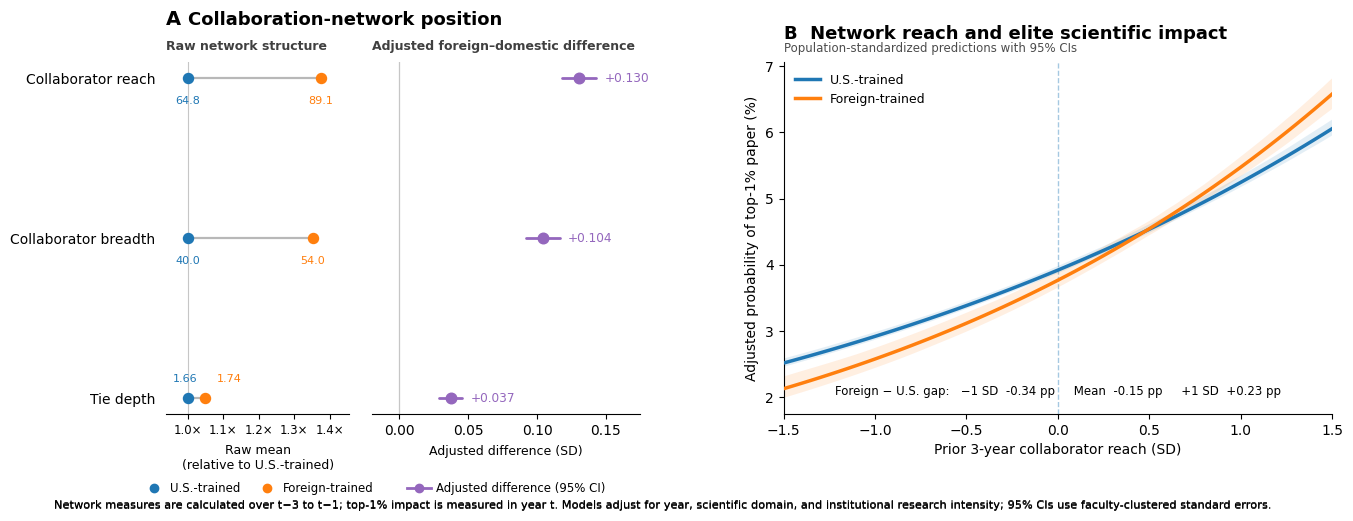

In [ ]:
# =============================================================================
# FIGURE 3 — FINAL REFINED VISUALIZATION
#
# PANEL A
#   Left portion:
#       raw means, U.S.-trained vs foreign-trained
#
#   Right portion:
#       adjusted foreign-domestic difference
#       + 95% CI
#
# PANEL B
#       population-standardized predicted top-1% probability
#       by prior-three-year collaborator reach
#
# NO MODEL FITTING.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# 1. LOAD
# =============================================================================

panel_a = pd.read_csv(
    "figure3_panel_a_results.csv"
)

panel_a_desc = pd.read_csv(
    "figure3_panel_a_descriptives.csv"
)

panel_b = pd.read_csv(
    "figure3_panel_b_results.csv"
)

pred = pd.read_csv(
    "figure3_panel_b_predictions.csv"
)

gap = pd.read_csv(
    "figure3_panel_b_gap.csv"
)


# =============================================================================
# 2. ORGANIZE PANEL A
# =============================================================================

metric_order = [
    "Network reach",
    "Network breadth",
    "Tie depth",
]

panel_a["metric"] = pd.Categorical(
    panel_a["metric"],
    categories=metric_order,
    ordered=True
)

panel_a = (
    panel_a
    .sort_values("metric")
    .reset_index(drop=True)
)


dom = (
    panel_a_desc
    .loc[
        panel_a_desc["phd_type"] == "domestic"
    ]
    .iloc[0]
)

foreign = (
    panel_a_desc
    .loc[
        panel_a_desc["phd_type"] == "foreign"
    ]
    .iloc[0]
)


raw_values = {
    "Network reach": (
        dom["degree_mean"],
        foreign["degree_mean"]
    ),

    "Network breadth": (
        dom["breadth_mean"],
        foreign["breadth_mean"]
    ),

    "Tie depth": (
        dom["tie_depth_mean"],
        foreign["tie_depth_mean"]
    ),
}


metric_labels = {
    "Network reach":
        "Collaborator reach",

    "Network breadth":
        "Collaborator breadth",

    "Tie depth":
        "Tie depth",
}


metric_definitions = {
    "Network reach":
        "Distinct collaborators",

    "Network breadth":
        "Effective collaborators",

    "Tie depth":
        "Shared papers per collaborator",
}


# =============================================================================
# 3. FIGURE LAYOUT
#
# Panel A itself contains two aligned axes:
#
#   A1 = raw comparison
#   A2 = adjusted comparison
#
# This gives the panel much more structure.
# =============================================================================

fig = plt.figure(
    figsize=(13.8, 5.25)
)


outer = fig.add_gridspec(
    1,
    2,
    width_ratios=[
        1.08,
        1.25
    ],
    wspace=0.28
)


left = outer[0].subgridspec(
    1,
    2,
    width_ratios=[
        0.92,
        1.35
    ],
    wspace=0.10
)


ax_raw = fig.add_subplot(
    left[0]
)

ax_adj = fig.add_subplot(
    left[1],
    sharey=ax_raw
)

ax_b = fig.add_subplot(
    outer[1]
)


# =============================================================================
# PANEL A — COLORS
# =============================================================================

US_COLOR = "tab:blue"
FOREIGN_COLOR = "tab:orange"
ADJUSTED_COLOR = "tab:purple"
CONNECTOR_COLOR = "0.72"


# =============================================================================
# PANEL A — RAW COMPARISONS
# =============================================================================

y = np.arange(len(panel_a))


for i, row in panel_a.iterrows():

    metric = row["metric"]

    d_raw, f_raw = raw_values[metric]

    d_rel = 1.0
    f_rel = f_raw / d_raw


    # -------------------------------------------------------------------------
    # Connector
    # -------------------------------------------------------------------------

    ax_raw.plot(
        [d_rel, f_rel],
        [i, i],
        linewidth=1.6,
        color=CONNECTOR_COLOR,
        zorder=1
    )


    # -------------------------------------------------------------------------
    # Points
    # -------------------------------------------------------------------------

    ax_raw.scatter(
        d_rel,
        i,
        s=52,
        color=US_COLOR,
        zorder=3
    )

    ax_raw.scatter(
        f_rel,
        i,
        s=52,
        color=FOREIGN_COLOR,
        zorder=3
    )


    # -------------------------------------------------------------------------
    # Labels
    #
    # Reach and breadth:
    #     below the points
    #
    # Tie depth:
    #     above the points;
    #     foreign value shifted farther right
    # -------------------------------------------------------------------------

    if metric == "Network reach":

        ax_raw.annotate(
            f"{d_raw:.1f}",
            (d_rel, i),
            xytext=(0, -13),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=8,
            color=US_COLOR
        )

        ax_raw.annotate(
            f"{f_raw:.1f}",
            (f_rel, i),
            xytext=(0, -13),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=8,
            color=FOREIGN_COLOR
        )


    elif metric == "Network breadth":

        ax_raw.annotate(
            f"{d_raw:.1f}",
            (d_rel, i),
            xytext=(0, -13),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=8,
            color=US_COLOR
        )

        ax_raw.annotate(
            f"{f_raw:.1f}",
            (f_rel, i),
            xytext=(0, -13),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=8,
            color=FOREIGN_COLOR
        )


    elif metric == "Tie depth":

        # U.S.-trained value — above point
        ax_raw.annotate(
            f"{d_raw:.2f}",
            (d_rel, i),
            xytext=(-2, 10),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color=US_COLOR
        )

        # Foreign-trained value — above AND farther right
        ax_raw.annotate(
            f"{f_raw:.2f}",
            (f_rel, i),
            xytext=(9, 10),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=8,
            color=FOREIGN_COLOR
        )


# =============================================================================
# PANEL A — RAW AXIS
# =============================================================================

ax_raw.axvline(
    1,
    linewidth=0.8,
    color="0.72",
    alpha=0.8
)


ax_raw.set_yticks(y)

ax_raw.set_yticklabels(
    [
        metric_labels[x]
        for x in panel_a["metric"]
    ],
    fontsize=10
)

ax_raw.invert_yaxis()


relative_max = max(
    raw_values[m][1] / raw_values[m][0]
    for m in metric_order
)


ax_raw.set_xlim(
    0.94,
    relative_max + 0.08
)


ax_raw.set_xlabel(
    "Raw mean\n(relative to U.S.-trained)",
    fontsize=9,
    labelpad=5
)


raw_ticks = [
    1.0,
    1.1,
    1.2,
    1.3,
    1.4
]

raw_ticks = [
    x
    for x in raw_ticks
    if x <= relative_max + 0.08
]


ax_raw.set_xticks(raw_ticks)

ax_raw.set_xticklabels(
    [
        f"{x:.1f}×"
        for x in raw_ticks
    ],
    fontsize=8.5
)


ax_raw.tick_params(
    axis="y",
    length=0,
    pad=8
)


ax_raw.spines["top"].set_visible(False)
ax_raw.spines["right"].set_visible(False)
ax_raw.spines["left"].set_visible(False)


# =============================================================================
# PANEL A — ADJUSTED DIFFERENCES
# =============================================================================

ax_adj.axvline(
    0,
    linewidth=0.9,
    color="0.72",
    alpha=0.8
)


for i, row in panel_a.iterrows():

    ax_adj.plot(
        [
            row["ci_low"],
            row["ci_high"]
        ],
        [
            i,
            i
        ],
        linewidth=2,
        color=ADJUSTED_COLOR,
        solid_capstyle="round",
        zorder=2
    )


    ax_adj.scatter(
        row["adjusted_difference_sd"],
        i,
        s=58,
        color=ADJUSTED_COLOR,
        zorder=3
    )


    ax_adj.text(
        row["ci_high"] + 0.006,
        i,
        f"+{row['adjusted_difference_sd']:.3f}",
        va="center",
        ha="left",
        fontsize=8.7,
        color=ADJUSTED_COLOR
    )


ax_adj.tick_params(
    axis="y",
    left=False,
    labelleft=False
)


ax_adj.set_xlim(
    -0.02,
    0.175
)


ax_adj.set_xlabel(
    "Adjusted difference (SD)",
    fontsize=9,
    labelpad=5
)


ax_adj.spines["top"].set_visible(False)
ax_adj.spines["right"].set_visible(False)
ax_adj.spines["left"].set_visible(False)
# =============================================================================
# 7. PANEL A HEADERS
# =============================================================================

# Main panel title
ax_raw.text(
    0.0,
    1.095,
    "A",
    transform=ax_raw.transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom"
)


ax_raw.text(
    0.12,
    1.095,
    "Collaboration-network position",
    transform=ax_raw.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="bottom"
)


ax_raw.text(
    0.0,
    1.035,
    "Raw network structure",
    transform=ax_raw.transAxes,
    fontsize=9,
    fontweight="bold",
    alpha=0.75
)


ax_adj.text(
    0.0,
    1.035,
    "Adjusted foreign–domestic difference",
    transform=ax_adj.transAxes,
    fontsize=9,
    fontweight="bold",
    alpha=0.75
)

# =============================================================================
# PANEL A — LEGENDS
#
# Deliberately separated:
#
#   raw legend      -> beneath left/raw axis
#   adjusted legend -> beneath right/adjusted axis
# =============================================================================

raw_legend = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markersize=6,
        markerfacecolor=US_COLOR,
        markeredgecolor=US_COLOR,
        color=US_COLOR,
        label="U.S.-trained"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markersize=6,
        markerfacecolor=FOREIGN_COLOR,
        markeredgecolor=FOREIGN_COLOR,
        color=FOREIGN_COLOR,
        label="Foreign-trained"
    ),
]


ax_raw.legend(
    handles=raw_legend,

    frameon=False,

    loc="upper center",

    # centered beneath RAW subplot
    bbox_to_anchor=(
        0.50,
        -0.18
    ),

    ncol=2,

    fontsize=8.5,

    handletextpad=0.35,

    columnspacing=1.25,

    borderaxespad=0
)


adjusted_legend = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=6,
        color=ADJUSTED_COLOR,
        markerfacecolor=ADJUSTED_COLOR,
        markeredgecolor=ADJUSTED_COLOR,
        label="Adjusted difference (95% CI)"
    )
]


ax_adj.legend(
    handles=adjusted_legend,

    frameon=False,

    loc="upper center",

    # centered beneath ADJUSTED subplot
    bbox_to_anchor=(
        0.50,
        -0.18
    ),

    ncol=1,

    fontsize=8.5,

    handletextpad=0.45,

    borderaxespad=0
)


# =============================================================================
# FIGURE NOTE
#
# Move below BOTH Panel A legends.
# =============================================================================

fig.text(
    0.5,
    0.018,
    (
        "Network measures are calculated over t−3 to t−1; "
        "top-1% impact is measured in year t. "
        "Models adjust for year, scientific domain, and institutional "
        "research intensity; 95% CIs use faculty-clustered standard errors."
    ),
    ha="center",
    va="bottom",
    fontsize=8.2
)


# =============================================================================
# LAYOUT
#
# More bottom space is required because we now have:
#
#   x-axis titles
#   Panel A legends
#   figure note
# =============================================================================

plt.subplots_adjust(
    left=0.14,
    right=0.985,
    top=0.87,
    bottom=0.28
)

# =============================================================================
# 9. PANEL B — PREDICTED TOP-1% PROBABILITY
# =============================================================================

for phd in [
    "domestic",
    "foreign",
]:

    d = (
        pred.loc[
            pred["phd_type"] == phd
        ]
        .sort_values("reach_z")
    )


    label = (
        "U.S.-trained"
        if phd == "domestic"
        else "Foreign-trained"
    )


    ax_b.plot(
        d["reach_z"],
        100 * d["predicted_top1"],
        linewidth=2.5,
        label=label,
        zorder=3
    )


    ax_b.fill_between(
        d["reach_z"].to_numpy(),
        (
            100
            * d["ci_low"]
        ).to_numpy(),
        (
            100
            * d["ci_high"]
        ).to_numpy(),
        alpha=0.12,
        linewidth=0,
        zorder=1
    )


# Mean reach
ax_b.axvline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.40,
    zorder=0
)


# =============================================================================
# 10. PANEL B — GAP ANNOTATION STRIP
#
# Instead of floating labels on the curves, show the three quantities
# together in one compact annotation.
# =============================================================================

gap_values = {}


for target in [
    -1.0,
    0.0,
    1.0
]:

    idx = (
        gap["reach_z"]
        .sub(target)
        .abs()
        .idxmin()
    )

    gap_values[target] = (
        gap.loc[idx]
    )


gap_text = (
    "Foreign − U.S. gap:   "
    f"−1 SD  {gap_values[-1.0]['foreign_minus_domestic_pp']:+.2f} pp"
    "     "
    f"Mean  {gap_values[0.0]['foreign_minus_domestic_pp']:+.2f} pp"
    "     "
    f"+1 SD  {gap_values[1.0]['foreign_minus_domestic_pp']:+.2f} pp"
)


ax_b.text(
    0.50,
    0.045,
    gap_text,
    transform=ax_b.transAxes,
    ha="center",
    va="bottom",
    fontsize=8.5
)


# =============================================================================
# 11. PANEL B FORMATTING
# =============================================================================

ax_b.set_xlim(
    -1.5,
    1.5
)


ax_b.set_xticks(
    [
        -1.5,
        -1.0,
        -0.5,
        0,
        0.5,
        1.0,
        1.5
    ]
)


ax_b.set_xlabel(
    "Prior 3-year collaborator reach (SD)",
    fontsize=10
)


ax_b.set_ylabel(
    "Adjusted probability of top-1% paper (%)",
    fontsize=10
)


ax_b.set_title(
    "B  Network reach and elite scientific impact",
    loc="left",
    fontweight="bold",
    fontsize=13,
    pad=17
)


ax_b.text(
    0.0,
    1.02,
    "Population-standardized predictions with 95% CIs",
    transform=ax_b.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    alpha=0.70
)


ax_b.legend(
    frameon=False,
    loc="upper left",
    fontsize=9
)


ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)


# =============================================================================
# 12. SHORT FIGURE NOTE
# =============================================================================

fig.text(
    0.5,
    0.015,
    (
        "Network measures are calculated over t−3 to t−1; "
        "top-1% impact is measured in year t. "
        "Models adjust for year, scientific domain, and institutional "
        "research intensity; 95% CIs use faculty-clustered standard errors."
    ),
    ha="center",
    va="bottom",
    fontsize=8.2
)


# =============================================================================
# 13. LAYOUT
# =============================================================================

plt.subplots_adjust(
    left=0.14,
    right=0.985,
    top=0.87,
    bottom=0.20
)


# =============================================================================
# 14. EXPORT
# =============================================================================

plt.savefig(
    "figure3_final_refined.png",
    dpi=400,
    bbox_inches="tight"
)


plt.savefig(
    "figure3_final_refined.pdf",
    bbox_inches="tight"
)


plt.show()

In [ ]:
# =============================================================================
# FIGURE 4 — PART 1: REVISED ANALYSIS / INFERENCE
#
# COGNITIVE PORTFOLIO STRUCTURE AND ELITE SCIENTIFIC IMPACT
#
# INPUT
# -----------------------------------------------------------------------------
# foreign-phd.analysis.figure4_cognitive_author_year
#
#
# CONCEPTUAL DESIGN
# -----------------------------------------------------------------------------
# Figure 3 = SOCIAL structure
# Figure 4 = COGNITIVE structure
#
# Cognitive portfolio measured over t-3 through t-1.
# Elite citation outcome measured in year t.
#
#
# PANEL A — COGNITIVE PORTFOLIO STRUCTURE
# -----------------------------------------------------------------------------
# Main dimensions:
#
#   1. Portfolio-size-adjusted topic breadth
#   2. Cognitive span
#
# Question:
#
#   Do foreign-trained faculty occupy broader but more/less dispersed
#   cognitive portfolios than U.S.-trained faculty?
#
#
# PANEL B — COGNITIVE CONFIGURATION AND ELITE IMPACT
# -----------------------------------------------------------------------------
# Model:
#
#   top1_rate ~
#       adjusted_breadth
#       * cognitive_span
#       + phd_type
#       + year
#       + umbrella_domain
#       + research_intensity
#
# The central quantity is the BREADTH × SPAN interaction.
#
# This asks whether the association between breadth and elite output
# depends on how cognitively dispersed the portfolio is.
#
# Importantly:
#
#   NO current-year productivity covariate.
#
#   prior3_papers enters ONLY in the construction of the
#   portfolio-size-adjusted breadth measure.
#
#
# OUTPUT
# -----------------------------------------------------------------------------
# figure4_results/
#
#   figure4_breadth_adjustment.csv
#   figure4_metric_correlations.csv
#
#   figure4_panel_a_descriptives.csv
#   figure4_panel_a_results.csv
#
#   figure4_panel_b_model_results.csv
#   figure4_panel_b_surface.csv
#   figure4_panel_b_profiles.csv
#
#   figure4_cognitive_position_centroids.csv
#
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.special import expit
from patsy import build_design_matrices

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

BQ_TABLE = (
    "foreign-phd.analysis.figure4_cognitive_author_year"
)

OUTDIR = "figure4_results"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


MIN_PRIOR3_PAPERS = 3

MIN_CURRENT_PAPERS = 1


# Prediction grid for Panel B

BREADTH_GRID = np.round(
    np.arange(
        -1.5,
        1.5001,
        0.10
    ),
    2
)


SPAN_GRID = np.round(
    np.arange(
        -1.5,
        1.5001,
        0.10
    ),
    2
)


# Three intuitive profile lines for visualization

PROFILE_SPAN_VALUES = [
    -1.0,
     0.0,
     1.0
]


# Simulation settings

N_DRAWS = 1000

RANDOM_SEED = 20260827


rng = np.random.default_rng(
    RANDOM_SEED
)


# =============================================================================
# 2. LOAD DATA
# =============================================================================

client = bigquery.Client(
    project=PROJECT
)


query = f"""

SELECT

    aad_year,
    author_id,

    phd_type,
    phd_country,

    umbrella_domain,
    Area,
    TaxonomyLevel01Name,

    InstitutionId,

    research_intensity_level,
    research_intensity_label,

    control_code,
    control_label,

    papers,
    top1_papers,
    top1_rate,

    topic_breadth,
    cognitive_span,
    boundary_spanning,

    prior3_papers

FROM `{BQ_TABLE}`

WHERE aad_year BETWEEN 2011 AND 2020

"""


df = (
    client
    .query(query)
    .to_dataframe()
)


print("=" * 80)
print("FIGURE 4 — REVISED ANALYSIS / INFERENCE")
print("=" * 80)
print()

print(
    f"Rows loaded:    {len(df):,}"
)

print(
    f"Authors loaded: {df['author_id'].nunique():,}"
)

print()


# =============================================================================
# 3. STATSMODELS-SAFE DTYPES
# =============================================================================

numeric_cols = [

    "aad_year",

    "papers",
    "top1_papers",
    "top1_rate",

    "topic_breadth",
    "cognitive_span",
    "boundary_spanning",

    "prior3_papers",

]


for col in numeric_cols:

    df[col] = (

        pd.to_numeric(
            df[col],
            errors="coerce"
        )

        .astype("float64")

    )


categorical_cols = [

    "phd_type",
    "phd_country",

    "umbrella_domain",
    "Area",
    "TaxonomyLevel01Name",

    "InstitutionId",

    "research_intensity_level",
    "research_intensity_label",

    "control_code",
    "control_label",

]


for col in categorical_cols:

    if col in df.columns:

        df[col] = (

            df[col]
            .astype("string")
            .fillna("Missing")
            .astype(str)

        )


df["author_id"] = (

    df["author_id"]
    .astype("string")
    .fillna("Missing")
    .astype(str)

)


df["phd_type"] = (

    df["phd_type"]
    .str.lower()
    .str.strip()

)


df = df[

    df["phd_type"].isin(
        [
            "domestic",
            "foreign"
        ]
    )

].copy()


# =============================================================================
# 4. ANALYTICAL RESTRICTIONS
# =============================================================================

df = df[

    (df["papers"] >= MIN_CURRENT_PAPERS)

    &

    (df["prior3_papers"] >= MIN_PRIOR3_PAPERS)

].copy()


df = df[

    df["papers"].notna()

    &

    df["top1_papers"].notna()

    &

    (df["papers"] > 0)

    &

    (df["top1_papers"] >= 0)

    &

    (df["top1_papers"] <= df["papers"])

].copy()


df["top1_rate"] = (

    df["top1_papers"]

    /

    df["papers"]

).astype("float64")


# Valid cognitive values

df.loc[
    ~np.isfinite(df["topic_breadth"]),
    "topic_breadth"
] = np.nan


df.loc[
    ~np.isfinite(df["cognitive_span"]),
    "cognitive_span"
] = np.nan


df.loc[
    ~np.isfinite(df["boundary_spanning"]),
    "boundary_spanning"
] = np.nan


df.loc[
    df["topic_breadth"] <= 0,
    "topic_breadth"
] = np.nan


df.loc[
    df["cognitive_span"] < 0,
    "cognitive_span"
] = np.nan


df.loc[
    (
        (df["boundary_spanning"] < 0)
        |
        (df["boundary_spanning"] > 1)
    ),
    "boundary_spanning"
] = np.nan


# Main Figure 4 analysis requires breadth + span

df = df.dropna(
    subset=[
        "topic_breadth",
        "cognitive_span",
        "prior3_papers",
        "aad_year",
        "author_id",
    ]
).copy()


print("=" * 80)
print("BASE ANALYTICAL SAMPLE")
print("=" * 80)
print()

print(
    f"Author-years: {len(df):,}"
)

print(
    f"Authors:      {df['author_id'].nunique():,}"
)

print(
    f"Years:        "
    f"{int(df['aad_year'].min())}"
    f"–"
    f"{int(df['aad_year'].max())}"
)

print(
    f"Papers:       {df['papers'].sum():,.0f}"
)

print(
    f"Top-1%:       {df['top1_papers'].sum():,.0f}"
)

print(
    "Top-1% rate:  "
    f"{100 * df['top1_papers'].sum() / df['papers'].sum():.3f}%"
)

print()


# =============================================================================
# 5. DIAGNOSE PORTFOLIO-SIZE DEPENDENCE
# =============================================================================

df["log_prior3_papers"] = np.log1p(
    df["prior3_papers"]
).astype("float64")


df["log_topic_breadth"] = np.log(
    df["topic_breadth"]
).astype("float64")


raw_corr = df[
    [
        "topic_breadth",
        "prior3_papers"
    ]
].corr().iloc[0, 1]


log_corr = df[
    [
        "log_topic_breadth",
        "log_prior3_papers"
    ]
].corr().iloc[0, 1]


print("=" * 80)
print("TOPIC BREADTH — PORTFOLIO-SIZE DIAGNOSTIC")
print("=" * 80)
print()

print(
    f"Corr(raw breadth, prior3 papers) = "
    f"{raw_corr:.3f}"
)

print(
    f"Corr(log breadth, log prior3 papers) = "
    f"{log_corr:.3f}"
)

print()


# =============================================================================
# 6. PORTFOLIO-SIZE-ADJUSTED TOPIC BREADTH
# =============================================================================
#
# The author-year table does not retain individual prior papers, so literal
# paper-level rarefaction cannot be performed from this table alone.
#
# Instead, estimate expected log topic breadth flexibly as a function of
# prior-three-year portfolio size.
#
# Model:
#
# log(topic breadth)
#     ~ log(prior3 papers)
#       + [log(prior3 papers)]^2
#       + [log(prior3 papers)]^3
#       + year FE
#
# Residual:
#
# observed breadth - expected breadth given portfolio size
#
# Positive:
#   broader topic portfolio than expected for that amount of prior output.
#
# Negative:
#   narrower portfolio than expected.
#
# This is a MEASUREMENT adjustment, not a productivity control in
# the elite-impact model.
#
# =============================================================================


breadth_adjustment_model = smf.ols(

    formula="""

    log_topic_breadth
    ~ log_prior3_papers
    + I(log_prior3_papers ** 2)
    + I(log_prior3_papers ** 3)
    + C(aad_year)

    """,

    data=df

).fit()


df["expected_log_topic_breadth"] = (

    breadth_adjustment_model
    .predict(df)
    .astype("float64")

)


df["adjusted_breadth_raw"] = (

    df["log_topic_breadth"]

    -

    df["expected_log_topic_breadth"]

).astype("float64")


# Standardize residual breadth

adjusted_breadth_mean = (
    df["adjusted_breadth_raw"].mean()
)

adjusted_breadth_sd = (
    df["adjusted_breadth_raw"].std(ddof=1)
)


df["breadth_z"] = (

    (
        df["adjusted_breadth_raw"]
        -
        adjusted_breadth_mean
    )

    /

    adjusted_breadth_sd

).astype("float64")


# Standardize cognitive span

span_mean = (
    df["cognitive_span"].mean()
)

span_sd = (
    df["cognitive_span"].std(ddof=1)
)


df["span_z"] = (

    (
        df["cognitive_span"]
        -
        span_mean
    )

    /

    span_sd

).astype("float64")


# Retain standardized boundary spanning only as diagnostic

boundary_mean = (
    df["boundary_spanning"].mean()
)

boundary_sd = (
    df["boundary_spanning"].std(ddof=1)
)


df["boundary_z"] = (

    (
        df["boundary_spanning"]
        -
        boundary_mean
    )

    /

    boundary_sd

).astype("float64")


# =============================================================================
# 7. CHECK WHETHER SIZE DEPENDENCE HAS BEEN REMOVED
# =============================================================================

adjusted_corr = df[
    [
        "breadth_z",
        "log_prior3_papers"
    ]
].corr().iloc[0, 1]


print("=" * 80)
print("PORTFOLIO-SIZE ADJUSTMENT")
print("=" * 80)
print()

print(
    f"Raw log breadth / log portfolio-size correlation: "
    f"{log_corr:.3f}"
)

print(
    f"Adjusted breadth / log portfolio-size correlation: "
    f"{adjusted_corr:.4f}"
)

print()

print(
    "Breadth adjustment model R²: "
    f"{breadth_adjustment_model.rsquared:.3f}"
)

print()


breadth_adjustment_summary = pd.DataFrame({

    "quantity": [

        "raw_corr",
        "log_corr",
        "adjusted_corr",
        "breadth_model_r2",

        "adjusted_breadth_mean",
        "adjusted_breadth_sd",

        "cognitive_span_mean",
        "cognitive_span_sd",

    ],

    "value": [

        raw_corr,
        log_corr,
        adjusted_corr,
        breadth_adjustment_model.rsquared,

        adjusted_breadth_mean,
        adjusted_breadth_sd,

        span_mean,
        span_sd,

    ]

})


breadth_adjustment_summary.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_breadth_adjustment.csv"
    ),

    index=False

)


# =============================================================================
# 8. CORRELATION STRUCTURE AFTER BREADTH ADJUSTMENT
# =============================================================================

corr = df[
    [
        "breadth_z",
        "span_z",
        "boundary_z"
    ]
].corr()


print("=" * 80)
print("COGNITIVE DIMENSION CORRELATIONS")
print("=" * 80)
print()

print(
    corr.round(3)
)

print()


corr.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_metric_correlations.csv"
    )

)


# =============================================================================
# 9. PANEL A — RAW / ADJUSTED DESCRIPTIVES
# =============================================================================

desc_rows = []


for phd in [
    "domestic",
    "foreign"
]:

    d = df[
        df["phd_type"] == phd
    ].copy()


    desc_rows.append({

        "phd_type":
            phd,

        "author_years":
            len(d),

        "authors":
            d["author_id"].nunique(),

        "papers":
            d["papers"].sum(),

        "top1_papers":
            d["top1_papers"].sum(),

        "top1_rate":
            (
                d["top1_papers"].sum()
                /
                d["papers"].sum()
            ),

        # Raw breadth
        "raw_topic_breadth_mean":
            d["topic_breadth"].mean(),

        "raw_topic_breadth_median":
            d["topic_breadth"].median(),

        # Size-adjusted breadth
        "adjusted_breadth_z_mean":
            d["breadth_z"].mean(),

        "adjusted_breadth_z_median":
            d["breadth_z"].median(),

        # Span
        "cognitive_span_mean":
            d["cognitive_span"].mean(),

        "cognitive_span_median":
            d["cognitive_span"].median(),

        "span_z_mean":
            d["span_z"].mean(),

        # Diagnostic only
        "boundary_spanning_mean":
            d["boundary_spanning"].mean(),

        # Portfolio size
        "prior3_papers_mean":
            d["prior3_papers"].mean(),

        "prior3_papers_median":
            d["prior3_papers"].median(),

    })


panel_a_desc = pd.DataFrame(
    desc_rows
)


print("=" * 80)
print("PANEL A — DESCRIPTIVES")
print("=" * 80)
print()

print(
    panel_a_desc.to_string(
        index=False
    )
)

print()


panel_a_desc.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_panel_a_descriptives.csv"
    ),

    index=False

)


# =============================================================================
# 10. PANEL A — ADJUSTED FOREIGN-DOMESTIC DIFFERENCES
# =============================================================================
#
# Main-text dimensions:
#
#   adjusted topic breadth
#   cognitive span
#
# Same adjustment framework for both:
#
#   cognitive position
#       ~ foreign
#       + year
#       + umbrella domain
#       + research intensity
#
# Author-clustered SEs.
#
# =============================================================================


PANEL_A_METRICS = {

    "breadth_z":
        "Adjusted topic breadth",

    "span_z":
        "Cognitive span",

}


panel_a_rows = []


formula_template_a = """

{outcome}
~
C(phd_type, Treatment(reference="domestic"))
+ C(aad_year)
+ C(umbrella_domain)
+ C(research_intensity_level)

"""


for outcome, label in PANEL_A_METRICS.items():

    d = df.dropna(
        subset=[
            outcome,
            "aad_year",
            "author_id",
            "phd_type",
            "umbrella_domain",
            "research_intensity_level",
        ]
    ).copy()


    d[outcome] = (
        d[outcome]
        .astype("float64")
    )


    d["aad_year"] = (
        d["aad_year"]
        .astype("float64")
    )


    print("=" * 80)
    print(
        f"PANEL A — {label.upper()}"
    )
    print("=" * 80)
    print()


    model = smf.ols(

        formula=formula_template_a.format(
            outcome=outcome
        ),

        data=d

    ).fit(

        cov_type="cluster",

        cov_kwds={
            "groups":
                d["author_id"].to_numpy()
        }

    )


    term = (

        'C(phd_type, Treatment(reference="domestic"))'
        '[T.foreign]'

    )


    beta = float(
        model.params[term]
    )

    se = float(
        model.bse[term]
    )

    p = float(
        model.pvalues[term]
    )


    ci_low = (
        beta
        -
        1.96 * se
    )

    ci_high = (
        beta
        +
        1.96 * se
    )


    print(
        f"Adjusted foreign-domestic difference = "
        f"{beta:+.4f} SD"
    )

    print(
        f"Author-clustered SE = "
        f"{se:.4f}"
    )

    print(
        f"95% CI = "
        f"[{ci_low:+.4f}, {ci_high:+.4f}]"
    )

    print(
        f"p = {p:.6g}"
    )

    print()


    panel_a_rows.append({

        "metric":
            label,

        "metric_code":
            outcome,

        "adjusted_difference_sd":
            beta,

        "ci_low":
            ci_low,

        "ci_high":
            ci_high,

        "p":
            p,

        "author_years":
            len(d),

        "authors":
            d["author_id"].nunique(),

    })


panel_a_results = pd.DataFrame(
    panel_a_rows
)


print("=" * 80)
print("PANEL A — FINAL RESULTS")
print("=" * 80)
print()

print(
    panel_a_results.to_string(
        index=False
    )
)

print()


panel_a_results.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_panel_a_results.csv"
    ),

    index=False

)


# =============================================================================
# 11. COGNITIVE POSITION CENTROIDS
# =============================================================================
#
# These locate foreign- and domestic-trained faculty in the 2-D
# breadth × span space.
#
# Useful for Panel A or for overlaying positions on Panel B.
#
# =============================================================================


centroid_rows = []


for phd in [
    "domestic",
    "foreign"
]:

    d = df[
        df["phd_type"] == phd
    ]


    centroid_rows.append({

        "phd_type":
            phd,

        "breadth_z_mean":
            d["breadth_z"].mean(),

        "span_z_mean":
            d["span_z"].mean(),

        "breadth_z_median":
            d["breadth_z"].median(),

        "span_z_median":
            d["span_z"].median(),

        "author_years":
            len(d),

        "authors":
            d["author_id"].nunique(),

    })


centroids = pd.DataFrame(
    centroid_rows
)


print("=" * 80)
print("COGNITIVE POSITION CENTROIDS")
print("=" * 80)
print()

print(
    centroids.to_string(
        index=False
    )
)

print()


centroids.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_cognitive_position_centroids.csv"
    ),

    index=False

)


# =============================================================================
# 12. PANEL B — COGNITIVE CONFIGURATION MODEL
# =============================================================================
#
# Central model:
#
# top1_rate
#     ~ breadth_z * span_z
#     + phd_type
#     + year
#     + umbrella domain
#     + research intensity
#
#
# Interpretation:
#
# breadth_z:
#   portfolio breadth conditional on portfolio size
#
# span_z:
#   average hierarchical distance among topics
#
# breadth_z × span_z:
#   whether the association between breadth and elite impact differs
#   according to cognitive dispersion.
#
#
# IMPORTANT:
#
# phd_type is included as an adjustment variable.
#
# We are NOT testing a foreign × cognition interaction here.
#
# =============================================================================


panel_b = df.dropna(
    subset=[
        "top1_rate",
        "papers",
        "breadth_z",
        "span_z",
        "phd_type",
        "aad_year",
        "umbrella_domain",
        "research_intensity_level",
        "author_id",
    ]
).copy()


panel_b["top1_rate"] = (
    panel_b["top1_rate"]
    .astype("float64")
)

panel_b["papers"] = (
    panel_b["papers"]
    .astype("float64")
)

panel_b["breadth_z"] = (
    panel_b["breadth_z"]
    .astype("float64")
)

panel_b["span_z"] = (
    panel_b["span_z"]
    .astype("float64")
)

panel_b["aad_year"] = (
    panel_b["aad_year"]
    .astype("float64")
)


print("=" * 80)
print("PANEL B — COGNITIVE CONFIGURATION AND ELITE OUTPUT")
print("=" * 80)
print()

print(
    f"Author-years: "
    f"{len(panel_b):,}"
)

print(
    f"Authors:      "
    f"{panel_b['author_id'].nunique():,}"
)

print(
    f"Papers:       "
    f"{panel_b['papers'].sum():,.0f}"
)

print(
    f"Top-1%:       "
    f"{panel_b['top1_papers'].sum():,.0f}"
)

print(
    "Top-1% rate:  "
    f"{100 * panel_b['top1_papers'].sum() / panel_b['papers'].sum():.3f}%"
)

print()


panel_b_formula = """

top1_rate
~
breadth_z * span_z
+ C(phd_type, Treatment(reference="domestic"))
+ C(aad_year)
+ C(umbrella_domain)
+ C(research_intensity_level)

"""


panel_b_model = smf.glm(

    formula=panel_b_formula,

    data=panel_b,

    family=sm.families.Binomial(),

    freq_weights=
        panel_b["papers"].to_numpy()

).fit(

    cov_type="cluster",

    cov_kwds={

        "groups":
            panel_b["author_id"].to_numpy()

    }

)


# =============================================================================
# 13. PANEL B — EXTRACT CORE TERMS
# =============================================================================

terms_of_interest = [

    "breadth_z",

    "span_z",

    "breadth_z:span_z",

    (
        'C(phd_type, Treatment(reference="domestic"))'
        '[T.foreign]'
    ),

]


panel_b_rows = []


for term in terms_of_interest:

    beta = float(
        panel_b_model.params[term]
    )

    se = float(
        panel_b_model.bse[term]
    )

    p = float(
        panel_b_model.pvalues[term]
    )

    ci_low = (
        beta
        -
        1.96 * se
    )

    ci_high = (
        beta
        +
        1.96 * se
    )


    panel_b_rows.append({

        "term":
            term,

        "beta":
            beta,

        "se":
            se,

        "ci_low":
            ci_low,

        "ci_high":
            ci_high,

        "p":
            p,

        "odds_ratio":
            np.exp(beta),

        "or_low":
            np.exp(ci_low),

        "or_high":
            np.exp(ci_high),

    })


panel_b_results = pd.DataFrame(
    panel_b_rows
)


print("=" * 80)
print("PANEL B — CORE MODEL RESULTS")
print("=" * 80)
print()

print(
    panel_b_results.to_string(
        index=False
    )
)

print()


interaction_row = panel_b_results[
    panel_b_results["term"]
    ==
    "breadth_z:span_z"
].iloc[0]


print(
    "Breadth × span interaction:"
)

print(
    f"beta = "
    f"{interaction_row['beta']:.5f}"
)

print(
    f"SE = "
    f"{interaction_row['se']:.5f}"
)

print(
    f"OR = "
    f"{interaction_row['odds_ratio']:.3f} "
    f"["
    f"{interaction_row['or_low']:.3f}, "
    f"{interaction_row['or_high']:.3f}"
    f"]"
)

print(
    f"p = "
    f"{interaction_row['p']:.6g}"
)

print()


panel_b_results.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_panel_b_model_results.csv"
    ),

    index=False

)


# =============================================================================
# 14. POPULATION-STANDARDIZED PREDICTION FUNCTION
# =============================================================================
#
# We average predictions across the observed analytical population.
#
# For each breadth/span combination:
#
#   - retain each observation's year
#   - retain umbrella domain
#   - retain research intensity
#   - retain observed PhD type
#
# Only breadth and span are changed.
#
# Thus Panel B represents the association between COGNITIVE CONFIGURATION
# and elite output standardized to the observed faculty population.
#
# =============================================================================


design_info = (
    panel_b_model
    .model
    .data
    .design_info
)


beta_hat = np.asarray(
    panel_b_model.params,
    dtype=float
)


covariance = np.asarray(
    panel_b_model.cov_params(),
    dtype=float
)


coefficient_draws = (
    rng.multivariate_normal(
        mean=beta_hat,
        cov=covariance,
        size=N_DRAWS
    )
)


def predict_configuration(
    breadth_value,
    span_value,
    calculate_ci=True
):

    pred_data = (
        panel_b.copy()
    )


    pred_data["breadth_z"] = (
        float(breadth_value)
    )

    pred_data["span_z"] = (
        float(span_value)
    )


    X = (

        build_design_matrices(

            [design_info],

            pred_data,

            return_type="dataframe"

        )[0]

        .to_numpy(
            dtype=float
        )

    )


    # Point prediction

    eta = (
        X
        @
        beta_hat
    )


    mean_probability = float(
        expit(eta).mean()
    )


    if not calculate_ci:

        return (
            mean_probability,
            np.nan,
            np.nan
        )


    # Parameter simulation

    simulated_means = np.empty(
        N_DRAWS,
        dtype=float
    )


    draw_chunk = 50


    for start in range(
        0,
        N_DRAWS,
        draw_chunk
    ):

        stop = min(
            start + draw_chunk,
            N_DRAWS
        )


        eta_draws = (

            X

            @

            coefficient_draws[
                start:stop
            ].T

        )


        p_draws = (
            expit(
                eta_draws
            )
        )


        simulated_means[
            start:stop
        ] = (
            p_draws.mean(
                axis=0
            )
        )


    ci_low = float(
        np.quantile(
            simulated_means,
            0.025
        )
    )


    ci_high = float(
        np.quantile(
            simulated_means,
            0.975
        )
    )


    return (
        mean_probability,
        ci_low,
        ci_high
    )


# =============================================================================
# 15. PANEL B — FULL 2-D PREDICTION SURFACE
# =============================================================================
#
# CIs are unnecessary for every point of a dense heatmap and would be
# computationally expensive.
#
# Therefore:
#
#   full surface = point estimates
#   profile lines = point estimates + 95% CIs
#
# =============================================================================


print("=" * 80)
print("COMPUTING PANEL B — 2-D COGNITIVE SURFACE")
print("=" * 80)
print()


surface_rows = []


for span_value in SPAN_GRID:

    print(
        f"Span = {span_value:+.1f} SD"
    )


    for breadth_value in BREADTH_GRID:

        probability, _, _ = (

            predict_configuration(

                breadth_value=
                    breadth_value,

                span_value=
                    span_value,

                calculate_ci=False

            )

        )


        surface_rows.append({

            "breadth_z":
                breadth_value,

            "span_z":
                span_value,

            "predicted_probability":
                probability,

            "predicted_percent":
                100 * probability,

        })


panel_b_surface = pd.DataFrame(
    surface_rows
)


panel_b_surface.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_panel_b_surface.csv"
    ),

    index=False

)


# =============================================================================
# 16. PANEL B — INTUITIVE PROFILE LINES WITH CIs
# =============================================================================
#
# We calculate breadth gradients at:
#
#   -1 SD span = cognitively coherent / concentrated
#    0 SD span = typical
#   +1 SD span = cognitively dispersed
#
# These may be easier to communicate than the heatmap.
#
# =============================================================================


print()
print("=" * 80)
print("COMPUTING PANEL B — PROFILE LINES")
print("=" * 80)
print()


profile_rows = []


for span_value in PROFILE_SPAN_VALUES:

    print(
        f"Profile: span = {span_value:+.1f} SD"
    )


    for breadth_value in BREADTH_GRID:

        (
            probability,
            ci_low,
            ci_high
        ) = predict_configuration(

            breadth_value=
                breadth_value,

            span_value=
                span_value,

            calculate_ci=True

        )


        profile_rows.append({

            "breadth_z":
                breadth_value,

            "span_z":
                span_value,

            "predicted_probability":
                probability,

            "ci_low":
                ci_low,

            "ci_high":
                ci_high,

            "predicted_percent":
                100 * probability,

            "ci_low_percent":
                100 * ci_low,

            "ci_high_percent":
                100 * ci_high,

        })


panel_b_profiles = pd.DataFrame(
    profile_rows
)


panel_b_profiles.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_panel_b_profiles.csv"
    ),

    index=False

)


# =============================================================================
# 17. INTUITIVE 2 × 2 COGNITIVE CONFIGURATION COMPARISON
# =============================================================================
#
# Four reference configurations:
#
#   Narrow + coherent
#   Broad  + coherent
#   Narrow + dispersed
#   Broad  + dispersed
#
# Defined at ±1 SD.
#
# =============================================================================


CONFIGURATIONS = [

    (
        "Narrow / coherent",
        -1.0,
        -1.0
    ),

    (
        "Broad / coherent",
        +1.0,
        -1.0
    ),

    (
        "Narrow / dispersed",
        -1.0,
        +1.0
    ),

    (
        "Broad / dispersed",
        +1.0,
        +1.0
    ),

]


configuration_rows = []


print()
print("=" * 80)
print("REFERENCE COGNITIVE CONFIGURATIONS")
print("=" * 80)
print()


for (
    label,
    breadth_value,
    span_value
) in CONFIGURATIONS:

    (
        probability,
        ci_low,
        ci_high
    ) = predict_configuration(

        breadth_value=
            breadth_value,

        span_value=
            span_value,

        calculate_ci=True

    )


    configuration_rows.append({

        "configuration":
            label,

        "breadth_z":
            breadth_value,

        "span_z":
            span_value,

        "predicted_probability":
            probability,

        "predicted_percent":
            100 * probability,

        "ci_low_percent":
            100 * ci_low,

        "ci_high_percent":
            100 * ci_high,

    })


    print(

        f"{label:22s}  "

        f"{100 * probability:.3f}% "

        f"["
        f"{100 * ci_low:.3f}, "
        f"{100 * ci_high:.3f}"
        f"]"

    )


configuration_results = pd.DataFrame(
    configuration_rows
)


configuration_results.to_csv(

    os.path.join(
        OUTDIR,
        "figure4_panel_b_configurations.csv"
    ),

    index=False

)


# =============================================================================
# 18. FINAL SUMMARY
# =============================================================================

print()
print("=" * 80)
print("FIGURE 4 — REVISED ANALYSIS COMPLETE")
print("=" * 80)
print()


print("PANEL A")
print("-" * 80)

print(

    panel_a_results[
        [
            "metric",
            "adjusted_difference_sd",
            "ci_low",
            "ci_high",
            "p",
            "author_years",
            "authors",
        ]
    ]

    .to_string(
        index=False
    )

)

print()


print("PANEL B")
print("-" * 80)

print(

    panel_b_results[
        [
            "term",
            "beta",
            "se",
            "odds_ratio",
            "or_low",
            "or_high",
            "p",
        ]
    ]

    .to_string(
        index=False
    )

)

print()


print("COGNITIVE POSITION CENTROIDS")
print("-" * 80)

print(
    centroids.to_string(
        index=False
    )
)

print()


print("REFERENCE CONFIGURATIONS")
print("-" * 80)

print(

    configuration_results[
        [
            "configuration",
            "predicted_percent",
            "ci_low_percent",
            "ci_high_percent",
        ]
    ]

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 19. SAVED FILES
# =============================================================================

print("=" * 80)
print("SAVED")
print("=" * 80)
print()

saved_files = [

    "figure4_breadth_adjustment.csv",

    "figure4_metric_correlations.csv",

    "figure4_panel_a_descriptives.csv",

    "figure4_panel_a_results.csv",

    "figure4_cognitive_position_centroids.csv",

    "figure4_panel_b_model_results.csv",

    "figure4_panel_b_surface.csv",

    "figure4_panel_b_profiles.csv",

    "figure4_panel_b_configurations.csv",

]


for file in saved_files:

    print(file)

FIGURE 4 — REVISED ANALYSIS / INFERENCE

Rows loaded:    906,761
Authors loaded: 175,187

BASE ANALYTICAL SAMPLE

Author-years: 853,822
Authors:      165,990
Years:        2012–2020
Papers:       6,298,359
Top-1%:       293,067
Top-1% rate:  4.653%

TOPIC BREADTH — PORTFOLIO-SIZE DIAGNOSTIC

Corr(raw breadth, prior3 papers) = 0.337
Corr(log breadth, log prior3 papers) = 0.702

PORTFOLIO-SIZE ADJUSTMENT

Raw log breadth / log portfolio-size correlation: 0.702
Adjusted breadth / log portfolio-size correlation: 0.0000

Breadth adjustment model R²: 0.497

COGNITIVE DIMENSION CORRELATIONS

            breadth_z  span_z  boundary_z
breadth_z       1.000   0.181       0.339
span_z          0.181   1.000       0.765
boundary_z      0.339   0.765       1.000

PANEL A — DESCRIPTIVES

phd_type  author_years  authors    papers  top1_papers  top1_rate  raw_topic_breadth_mean  raw_topic_breadth_median  adjusted_breadth_z_mean  adjusted_breadth_z_median  cognitive_span_mean  cognitive_span_median  sp

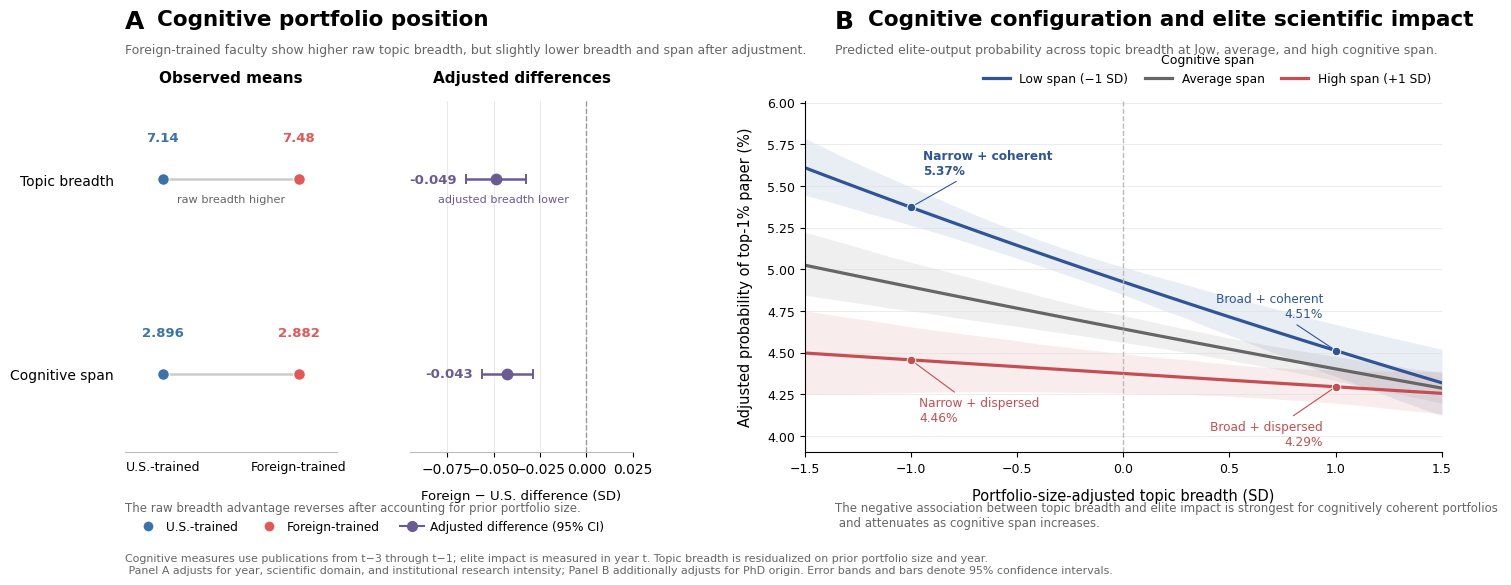

In [ ]:
# =============================================================================
# FIGURE 4 — VISUALIZATION ONLY
# Revised spacing / annotation version
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# 1. SETTINGS
# =============================================================================

OUTDIR = "figure4_results"

SAVE_PNG = os.path.join(OUTDIR, "figure4_final.png")
SAVE_PDF = os.path.join(OUTDIR, "figure4_final.pdf")

DOMESTIC = "#3B73A8"
FOREIGN = "#E45756"
ADJUSTED = "#6B5B95"

SPAN_LOW = "#2F5597"
SPAN_MEAN = "#666666"
SPAN_HIGH = "#C44E52"

TEXT = "#202020"
SUBTEXT = "#666666"
GRID = "#DDDDDD"
CONNECTOR = "#CCCCCC"


# =============================================================================
# 2. LOAD RESULTS
# =============================================================================

desc = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panel_a_descriptives.csv"
    )
)

results = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panel_a_results.csv"
    )
)

profiles = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panel_b_profiles.csv"
    )
)

configs = pd.read_csv(
    os.path.join(
        OUTDIR,
        "figure4_panel_b_configurations.csv"
    )
)


# =============================================================================
# 3. PANEL A VALUES
# =============================================================================

dom = desc.loc[
    desc["phd_type"] == "domestic"
].iloc[0]

foreign = desc.loc[
    desc["phd_type"] == "foreign"
].iloc[0]


raw = {
    "Topic breadth": (
        dom["raw_topic_breadth_mean"],
        foreign["raw_topic_breadth_mean"],
    ),
    "Cognitive span": (
        dom["cognitive_span_mean"],
        foreign["cognitive_span_mean"],
    ),
}


res = results.set_index("metric")

adjusted = {
    "Topic breadth": (
        res.loc[
            "Adjusted topic breadth",
            "adjusted_difference_sd"
        ],
        res.loc[
            "Adjusted topic breadth",
            "ci_low"
        ],
        res.loc[
            "Adjusted topic breadth",
            "ci_high"
        ],
    ),

    "Cognitive span": (
        res.loc[
            "Cognitive span",
            "adjusted_difference_sd"
        ],
        res.loc[
            "Cognitive span",
            "ci_low"
        ],
        res.loc[
            "Cognitive span",
            "ci_high"
        ],
    ),
}


# =============================================================================
# 4. PANEL B VALUES
# =============================================================================

profile_settings = [
    (-1.0, "Low span (−1 SD)", SPAN_LOW),
    ( 0.0, "Average span",     SPAN_MEAN),
    ( 1.0, "High span (+1 SD)", SPAN_HIGH),
]


cfg = configs.set_index("configuration")

narrow_coherent = cfg.loc[
    "Narrow / coherent",
    "predicted_percent"
]

broad_coherent = cfg.loc[
    "Broad / coherent",
    "predicted_percent"
]

narrow_dispersed = cfg.loc[
    "Narrow / dispersed",
    "predicted_percent"
]

broad_dispersed = cfg.loc[
    "Broad / dispersed",
    "predicted_percent"
]


# =============================================================================
# 5. FIGURE LAYOUT
#
# IMPORTANT:
#
# Top title/subtitle region:
#     y = .965 to .865
#
# Plot region:
#     y = .235 to .805
#
# Bottom legend/note region:
#     y = .045 to .155
#
# This prevents text from competing with the plotting areas.
# =============================================================================

fig = plt.figure(
    figsize=(14.8, 6.15),
    facecolor="white"
)

outer = fig.add_gridspec(
    nrows=1,
    ncols=2,

    width_ratios=[
        1.02,
        1.28
    ],

    left=0.075,
    right=0.965,

    bottom=0.235,
    top=0.805,

    wspace=0.30
)


# =============================================================================
# 6. PANEL A
# =============================================================================

gs_a = outer[0].subgridspec(
    1,
    2,

    width_ratios=[
        1.00,
        1.05
    ],

    wspace=0.34
)

ax_raw = fig.add_subplot(gs_a[0])
ax_adj = fig.add_subplot(gs_a[1])

metrics = [
    "Topic breadth",
    "Cognitive span"
]

ys = [
    1,
    0
]


# =============================================================================
# 7. PANEL A — OBSERVED MEANS
# =============================================================================

for metric, y in zip(metrics, ys):

    dval, fval = raw[metric]

    # Connector
    ax_raw.plot(
        [0, 1],
        [y, y],
        color=CONNECTOR,
        linewidth=1.8,
        zorder=1
    )

    # Points
    ax_raw.scatter(
        0,
        y,
        s=70,
        color=DOMESTIC,
        edgecolor="white",
        linewidth=0.8,
        zorder=3
    )

    ax_raw.scatter(
        1,
        y,
        s=70,
        color=FOREIGN,
        edgecolor="white",
        linewidth=0.8,
        zorder=3
    )

    # Labels
    if metric == "Topic breadth":
        dlabel = f"{dval:.2f}"
        flabel = f"{fval:.2f}"
    else:
        dlabel = f"{dval:.3f}"
        flabel = f"{fval:.3f}"

    ax_raw.text(
        0,
        y + 0.18,
        dlabel,
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=DOMESTIC
    )

    ax_raw.text(
        1,
        y + 0.18,
        flabel,
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color=FOREIGN
    )


ax_raw.set_xlim(-0.28, 1.28)
ax_raw.set_ylim(-0.40, 1.40)

ax_raw.set_yticks(ys)
ax_raw.set_yticklabels(
    metrics,
    fontsize=10
)

ax_raw.tick_params(
    axis="y",
    length=0,
    pad=8
)

ax_raw.set_xticks([0, 1])
ax_raw.set_xticklabels(
    [
        "U.S.-trained",
        "Foreign-trained"
    ],
    fontsize=9
)

ax_raw.tick_params(
    axis="x",
    length=0,
    pad=6
)

ax_raw.set_title(
    "Observed means",
    fontsize=11,
    fontweight="bold",
    pad=14
)

for spine in [
    "top",
    "right",
    "left"
]:
    ax_raw.spines[spine].set_visible(False)

ax_raw.spines["bottom"].set_color("#BBBBBB")


# -----------------------------------------------------------------------------
# Small raw-breadth annotation
#
# Put BELOW the first connector rather than on it.
# -----------------------------------------------------------------------------

ax_raw.text(
    0.50,
    0.72,
    "raw breadth higher",
    transform=ax_raw.transAxes,
    ha="center",
    va="center",
    fontsize=8.1,
    color=SUBTEXT
)


# =============================================================================
# 8. PANEL A — ADJUSTED DIFFERENCES
# =============================================================================

for metric, y in zip(metrics, ys):

    estimate, low, high = adjusted[metric]

    ax_adj.errorbar(
        estimate,
        y,

        xerr=np.array(
            [
                [estimate - low],
                [high - estimate]
            ]
        ),

        fmt="o",

        color=ADJUSTED,
        ecolor=ADJUSTED,

        markersize=7.5,
        elinewidth=1.8,

        capsize=3.5,
        capthick=1.4,

        zorder=3
    )

    # Estimate text left of CI
    ax_adj.text(
        low - 0.005,
        y,
        f"{estimate:+.3f}",
        ha="right",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color=ADJUSTED
    )


ax_adj.axvline(
    0,
    color="#999999",
    linestyle="--",
    linewidth=1.0
)

ax_adj.set_xlim(
    -0.095,
    0.025
)

ax_adj.set_ylim(
    -0.40,
    1.40
)

ax_adj.set_yticks([])

ax_adj.set_xlabel(
    "Foreign − U.S. difference (SD)",
    fontsize=9.5,
    labelpad=10
)

ax_adj.set_title(
    "Adjusted differences",
    fontsize=11,
    fontweight="bold",
    pad=14
)

ax_adj.grid(
    axis="x",
    color=GRID,
    linewidth=0.7,
    alpha=0.65
)

for spine in [
    "top",
    "right",
    "left"
]:
    ax_adj.spines[spine].set_visible(False)

ax_adj.spines["bottom"].set_color("#BBBBBB")


# -----------------------------------------------------------------------------
# Adjusted-breadth annotation
#
# Keep this BELOW the CI rather than beside/over it.
# -----------------------------------------------------------------------------

ax_adj.text(
    0.42,
    0.72,
    "adjusted breadth lower",
    transform=ax_adj.transAxes,
    ha="center",
    va="center",
    fontsize=8.1,
    color=ADJUSTED
)


# =============================================================================
# 9. PANEL B
# =============================================================================

ax_b = fig.add_subplot(
    outer[1]
)


for (
    span_value,
    label,
    color
) in profile_settings:

    d = (
        profiles[
            np.isclose(
                profiles["span_z"],
                span_value
            )
        ]
        .sort_values(
            "breadth_z"
        )
    )

    # CI
    ax_b.fill_between(
        d["breadth_z"],
        d["ci_low_percent"],
        d["ci_high_percent"],
        color=color,
        alpha=0.10,
        linewidth=0
    )

    # Prediction
    ax_b.plot(
        d["breadth_z"],
        d["predicted_percent"],
        color=color,
        linewidth=2.3,
        label=label
    )


# =============================================================================
# 10. PANEL B — REFERENCE POINTS
# =============================================================================

reference_points = [
    (-1.0, narrow_coherent,  SPAN_LOW),
    ( 1.0, broad_coherent,   SPAN_LOW),
    (-1.0, narrow_dispersed, SPAN_HIGH),
    ( 1.0, broad_dispersed,  SPAN_HIGH),
]


for x, y, color in reference_points:

    ax_b.scatter(
        x,
        y,
        s=38,
        color=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=5
    )


# =============================================================================
# 11. PANEL B — CLEAN CONFIGURATION LABELS
#
# Important change:
#
# Do NOT put all four labels immediately next to their points.
#
# Put the two LEFT labels above/below their points.
# Put the two RIGHT labels above/below their points.
#
# This creates four separate annotation zones.
# =============================================================================


# Narrow + coherent ------------------------------------------------------------

ax_b.annotate(
    f"Narrow + coherent\n{narrow_coherent:.2f}%",

    xy=(-1.0, narrow_coherent),

    xytext=(-0.94, narrow_coherent + 0.18),

    ha="left",
    va="bottom",

    fontsize=8.7,
    fontweight="bold",
    color=SPAN_LOW,

    arrowprops=dict(
        arrowstyle="-",
        color=SPAN_LOW,
        linewidth=0.8
    )
)


# Narrow + dispersed -----------------------------------------------------------

ax_b.annotate(
    f"Narrow + dispersed\n{narrow_dispersed:.2f}%",

    xy=(-1.0, narrow_dispersed),

    xytext=(-0.96, narrow_dispersed - 0.22),

    ha="left",
    va="top",

    fontsize=8.7,
    color=SPAN_HIGH,

    arrowprops=dict(
        arrowstyle="-",
        color=SPAN_HIGH,
        linewidth=0.8
    )
)


# Broad + coherent -------------------------------------------------------------

ax_b.annotate(
    f"Broad + coherent\n{broad_coherent:.2f}%",

    xy=(1.0, broad_coherent),

    xytext=(0.94, broad_coherent + 0.18),

    ha="right",
    va="bottom",

    fontsize=8.7,
    color=SPAN_LOW,

    arrowprops=dict(
        arrowstyle="-",
        color=SPAN_LOW,
        linewidth=0.8
    )
)


# Broad + dispersed ------------------------------------------------------------

ax_b.annotate(
    f"Broad + dispersed\n{broad_dispersed:.2f}%",

    xy=(1.0, broad_dispersed),

    xytext=(0.94, broad_dispersed - 0.20),

    ha="right",
    va="top",

    fontsize=8.7,
    color=SPAN_HIGH,

    arrowprops=dict(
        arrowstyle="-",
        color=SPAN_HIGH,
        linewidth=0.8
    )
)


# =============================================================================
# 12. PANEL B — AXES
# =============================================================================

ax_b.axvline(
    0,
    color="#BBBBBB",
    linestyle="--",
    linewidth=1.0
)


all_low = profiles[
    "ci_low_percent"
].min()

all_high = profiles[
    "ci_high_percent"
].max()


# Give labels substantially more vertical breathing room.
ax_b.set_ylim(
    all_low - 0.22,
    all_high + 0.22
)

ax_b.set_xlim(
    -1.5,
    1.5
)


ax_b.set_xlabel(
    "Portfolio-size-adjusted topic breadth (SD)",
    fontsize=10.5,
    labelpad=10
)

ax_b.set_ylabel(
    "Adjusted probability of top-1% paper (%)",
    fontsize=10.5,
    labelpad=10
)


ax_b.grid(
    axis="y",
    color=GRID,
    linewidth=0.7,
    alpha=0.55
)

for spine in [
    "top",
    "right"
]:
    ax_b.spines[spine].set_visible(False)

ax_b.tick_params(
    labelsize=9
)


# =============================================================================
# 13. PANEL B LEGEND
#
# Put legend ABOVE the plotting area, not inside it.
# =============================================================================

ax_b.legend(
    title="Cognitive span",
    frameon=False,

    loc="lower right",

    bbox_to_anchor=(
        1.00,
        1.015
    ),

    ncol=3,

    fontsize=8.7,
    title_fontsize=9,

    columnspacing=1.4,
    handlelength=2.2
)


# =============================================================================
# 14. PANEL TITLES / SUBTITLES
#
# Deliberately separate title and subtitle vertically.
# =============================================================================

# A ---------------------------------------------------------------------------

fig.text(
    0.075,
    0.955,
    "A",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.097,
    0.955,
    "Cognitive portfolio position",
    fontsize=15.5,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.075,
    0.900,
    (
        "Foreign-trained faculty show higher raw topic breadth, "
        "but slightly lower breadth and span after adjustment."
    ),
    fontsize=9,
    color=SUBTEXT,
    ha="left",
    va="top"
)


# B ---------------------------------------------------------------------------

fig.text(
    0.555,
    0.955,
    "B",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.577,
    0.955,
    "Cognitive configuration and elite scientific impact",
    fontsize=15.5,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.555,
    0.900,
    (
        "Predicted elite-output probability across topic breadth "
        "at low, average, and high cognitive span."
    ),
    fontsize=9,
    color=SUBTEXT,
    ha="left",
    va="top"
)


# =============================================================================
# 15. PANEL A LEGEND
#
# Move well below axes and away from x labels.
# =============================================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=DOMESTIC,
        markeredgecolor="white",
        markersize=8,
        label="U.S.-trained"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=FOREIGN,
        markeredgecolor="white",
        markersize=8,
        label="Foreign-trained"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color=ADJUSTED,
        markerfacecolor=ADJUSTED,
        markersize=7,
        linewidth=1.5,
        label="Adjusted difference (95% CI)"
    ),
]


fig.legend(
    handles=legend_handles,

    loc="lower left",

    bbox_to_anchor=(
        0.075,
        0.085
    ),

    frameon=False,

    ncol=3,

    fontsize=8.7,

    handletextpad=0.5,
    columnspacing=1.6
)


# =============================================================================
# 16. PANEL A EXPLANATORY NOTE
#
# One short sentence, below plot but ABOVE legend.
# =============================================================================

fig.text(
    0.075,
    0.155,
    (
        "The raw breadth advantage reverses after accounting for "
        "prior portfolio size."
    ),
    fontsize=8.5,
    color=SUBTEXT,
    ha="left",
    va="top"
)


# =============================================================================
# 17. PANEL B EXPLANATORY NOTE
#
# Remove text from inside plot.
# Put interpretation below plot.
# =============================================================================

fig.text(
    0.555,
    0.155,
    (
        "The negative association between topic breadth and elite impact "
        "is strongest for cognitively coherent portfolios \n and attenuates "
        "as cognitive span increases."
    ),
    fontsize=8.5,
    color=SUBTEXT,
    ha="left",
    va="top"
)


# =============================================================================
# 18. METHODS NOTE
#
# Put this at the very bottom, across the full figure.
# =============================================================================

fig.text(
    0.075,
    0.035,
    (
        "Cognitive measures use publications from t−3 through t−1; elite impact "
        "is measured in year t. Topic breadth is residualized on prior portfolio "
        "size and year. \n Panel A adjusts for year, scientific domain, and "
        "institutional research intensity; Panel B additionally adjusts for "
        "PhD origin. Error bands and bars denote 95% confidence intervals."
    ),
    fontsize=7.9,
    color=SUBTEXT,
    ha="left",
    va="bottom"
)


# =============================================================================
# 19. SAVE
# =============================================================================

plt.savefig(
    SAVE_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    SAVE_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [ ]:
# =============================================================================
# FIGURE 3 — HETEROGENEITY #1: CAREER STAGE
# EXACTLY COMPARABLE TO FINAL FIGURE 3 PANEL B
#
# Main Figure 3 specification:
#
#   Exposure:
#       z[ log(1 + prior-3-year network degree) ]
#
#   Model:
#       grouped-binomial GLM
#
#       successes = top1_papers
#       failures  = papers - top1_papers
#
#   Adjustment:
#       year FE
#       domain FE
#       research-intensity FE
#
#   NO productivity control.
#
#   Inference:
#       author-clustered sandwich covariance calculated directly from
#       author-year score contributions.
#
# Comparability:
#
#   reach_z is defined ONCE using the ORIGINAL Figure 3 Panel B sample,
#   exactly as in the final Figure 3 notebook:
#
#       z[prior3_log_degree], ddof=0
#
#   The identical transformation is then applied to:
#
#       1. Original Figure 3 Panel B
#       2. Rank-observed pooled sample
#       3. Assistant professors
#       4. Associate professors
#       5. Full professors
#
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

ORIGINAL_TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final"
)

RANK_TABLE = (
    "foreign-phd.facultyraw."
    "figure3_rank_heterogeneity"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD ORIGINAL FIGURE 3 PANEL B SAMPLE
# =============================================================================

query_original = f"""

SELECT

    author_id,
    year,

    phd_type,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree

FROM `{ORIGINAL_TABLE}`

WHERE year BETWEEN 2011 AND 2020

  AND panel_b_eligible = 1

  AND papers > 0

  AND prior3_log_degree IS NOT NULL

"""


original = (
    client
    .query(query_original)
    .to_dataframe()
)


# =============================================================================
# 3. LOAD RANK-OBSERVED PANEL B SAMPLE
# =============================================================================

query_rank = f"""

SELECT

    author_id,
    year,

    phd_type,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree,

    rank_type_id,
    career_stage

FROM `{RANK_TABLE}`

WHERE year BETWEEN 2011 AND 2020

  AND panel_b_eligible = 1

  AND papers > 0

  AND prior3_log_degree IS NOT NULL

  AND rank_type_id IN (1, 2, 3)

"""


rank_df = (
    client
    .query(query_rank)
    .to_dataframe()
)


# =============================================================================
# 4. CLEAN DATA
# =============================================================================

def clean_data(
    data,
    include_rank=False
):

    d = data.copy()


    # -------------------------------------------------------------------------
    # Numeric
    # -------------------------------------------------------------------------

    numeric_cols = [

        "year",

        "research_intensity_level",

        "papers",
        "top1_papers",

        "prior3_degree",
        "prior3_log_degree",

    ]


    if include_rank:

        numeric_cols.append(
            "rank_type_id"
        )


    for col in numeric_cols:

        d[col] = pd.to_numeric(
            d[col],
            errors="coerce"
        )


    # -------------------------------------------------------------------------
    # Valid year
    # -------------------------------------------------------------------------

    d = d[
        d["year"].notna()
    ].copy()


    d["year"] = (
        d["year"]
        .astype(int)
    )


    # -------------------------------------------------------------------------
    # PhD type
    # -------------------------------------------------------------------------

    d["phd_type"] = (

        d["phd_type"]

        .astype(str)

        .str.lower()

        .str.strip()

    )


    d = d[
        d["phd_type"].isin(
            [
                "domestic",
                "foreign",
            ]
        )
    ].copy()


    # -------------------------------------------------------------------------
    # Categorical controls
    #
    # EXACTLY as final Figure 3.
    # -------------------------------------------------------------------------

    d["year_cat"] = (
        d["year"]
        .astype(str)
    )


    d["domain_cat"] = (

        d["primary_domain"]

        .fillna(
            "Unknown"
        )

        .astype(str)

    )


    d["research_cat"] = (

        d["research_intensity_level"]

        .fillna(-999)

        .astype(str)

    )


    # -------------------------------------------------------------------------
    # Valid grouped-binomial observations
    # -------------------------------------------------------------------------

    valid = (

        d["papers"].notna()

        &

        d["top1_papers"].notna()

        &

        d["prior3_log_degree"].notna()

        &

        (
            d["papers"]
            >
            0
        )

        &

        (
            d["top1_papers"]
            >=
            0
        )

        &

        (
            d["top1_papers"]
            <=
            d["papers"]
        )

    )


    if include_rank:

        valid = (

            valid

            &

            d["rank_type_id"].isin(
                [
                    1,
                    2,
                    3,
                ]
            )

        )


    d = (
        d.loc[valid]
        .copy()
    )


    return d


original = clean_data(
    original,
    include_rank=False
)


rank_df = clean_data(
    rank_df,
    include_rank=True
)


# =============================================================================
# 5. SAMPLE AUDIT
# =============================================================================

print("=" * 80)

print(
    "FIGURE 3 — CAREER-STAGE HETEROGENEITY"
)

print(
    "EXACT FIGURE 3 PANEL B SPECIFICATION"
)

print("=" * 80)

print()


print(
    "ORIGINAL FIGURE 3 PANEL B"
)

print("-" * 80)

print(
    f"Author-years: "
    f"{len(original):,}"
)

print(
    f"Authors:      "
    f"{original['author_id'].nunique():,}"
)

print(
    f"Papers:       "
    f"{original['papers'].sum():,.0f}"
)

print(
    f"Top-1%:       "
    f"{original['top1_papers'].sum():,.0f}"
)

print()


print(
    "RANK-OBSERVED PANEL B"
)

print("-" * 80)

print(
    f"Author-years: "
    f"{len(rank_df):,}"
)

print(
    f"Authors:      "
    f"{rank_df['author_id'].nunique():,}"
)

print(
    f"Papers:       "
    f"{rank_df['papers'].sum():,.0f}"
)

print(
    f"Top-1%:       "
    f"{rank_df['top1_papers'].sum():,.0f}"
)

print()


print(
    "Rank retention:"
)

print(
    "  Author-years: "
    f"{100 * len(rank_df) / len(original):.2f}%"
)

print(
    "  Authors:      "
    f"{100 * rank_df['author_id'].nunique() / original['author_id'].nunique():.2f}%"
)

print()


# =============================================================================
# 6. EXACT FIGURE 3 REACH STANDARDIZATION
#
# FINAL FIGURE 3:
#
#     reach_z = z[prior3_log_degree]
#
# with:
#
#     prior3_log_degree = log(1 + prior3_degree)
#
# and:
#
#     SD uses ddof = 0
#
# =============================================================================

REACH_LOG_MEAN = (

    original[
        "prior3_log_degree"
    ]

    .astype(float)

    .mean()

)


REACH_LOG_SD = (

    original[
        "prior3_log_degree"
    ]

    .astype(float)

    .std(
        ddof=0
    )

)


print("=" * 80)

print(
    "ORIGINAL FIGURE 3 REACH TRANSFORMATION"
)

print("=" * 80)

print()


print(
    "Exposure = "
    "z[log(1 + prior-3-year network reach)]"
)

print()

print(
    f"Mean log reach = "
    f"{REACH_LOG_MEAN:.6f}"
)

print(
    f"SD log reach   = "
    f"{REACH_LOG_SD:.6f}"
)

print()


# =============================================================================
# 7. APPLY IDENTICAL TRANSFORMATION
# =============================================================================

original["reach_z"] = (

    (
        original[
            "prior3_log_degree"
        ].astype(float)

        -

        REACH_LOG_MEAN
    )

    /

    REACH_LOG_SD

)


rank_df["reach_z"] = (

    (
        rank_df[
            "prior3_log_degree"
        ].astype(float)

        -

        REACH_LOG_MEAN
    )

    /

    REACH_LOG_SD

)


# =============================================================================
# 8. STANDARDIZATION AUDIT
# =============================================================================

print("=" * 80)

print(
    "STANDARDIZATION AUDIT"
)

print("=" * 80)

print()


print(
    "Original Figure 3:"
)

print(
    f"  mean = "
    f"{original['reach_z'].mean():.6f}"
)

print(
    f"  SD   = "
    f"{original['reach_z'].std(ddof=0):.6f}"
)

print()


print(
    "Rank-observed sample on SAME scale:"
)

print(
    f"  mean = "
    f"{rank_df['reach_z'].mean():.6f}"
)

print(
    f"  SD   = "
    f"{rank_df['reach_z'].std(ddof=0):.6f}"
)

print()


# =============================================================================
# 9. EXACT FIGURE 3 MODEL FORMULA
# =============================================================================

rhs_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(domain_cat) + "

    "C(research_cat)"

)


# =============================================================================
# 10. MODEL FUNCTION
#
# This duplicates the final Figure 3 grouped-binomial estimation and
# author-clustered sandwich covariance.
# =============================================================================

def fit_exact_figure3_model(
    data,
    label
):

    # -------------------------------------------------------------------------
    # Exact model columns
    # -------------------------------------------------------------------------

    cols = [

        "top1_papers",
        "papers",

        "reach_z",

        "phd_type",

        "year_cat",
        "domain_cat",
        "research_cat",

        "author_id",

        "prior3_degree",
        "prior3_log_degree",

    ]


    d = (

        data[
            cols
        ]

        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan
        )

        .dropna()

        .copy()

    )


    # -------------------------------------------------------------------------
    # Exact numeric conversions
    # -------------------------------------------------------------------------

    for col in [

        "top1_papers",
        "papers",
        "reach_z",

    ]:

        d[col] = (

            pd.to_numeric(
                d[col],
                errors="coerce"
            )

            .astype(float)

        )


    d = d[

        (d["papers"] > 0)

        &

        (d["top1_papers"] >= 0)

        &

        (
            d["top1_papers"]
            <=
            d["papers"]
        )

    ].copy()


    # -------------------------------------------------------------------------
    # Exact string conversions
    # -------------------------------------------------------------------------

    for col in [

        "phd_type",
        "year_cat",
        "domain_cat",
        "research_cat",
        "author_id",

    ]:

        d[col] = (
            d[col]
            .astype(str)
        )


    # =========================================================================
    # DESIGN MATRIX
    # =========================================================================

    X_df = dmatrix(

        rhs_formula,

        data=d,

        return_type="dataframe"

    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # =========================================================================
    # GROUPED-BINOMIAL OUTCOME
    # =========================================================================

    successes = (

        d[
            "top1_papers"
        ]

        .to_numpy(
            dtype=float
        )

    )


    failures = (

        d[
            "papers"
        ]

        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # =========================================================================
    # GLM
    # =========================================================================

    glm = sm.GLM(

        endog=endog,

        exog=X,

        family=sm.families.Binomial()

    )


    fit = glm.fit()


    # =========================================================================
    # AUTHOR-CLUSTERED SANDWICH COVARIANCE
    #
    # EXACTLY follows final Figure 3.
    # =========================================================================

    score_obs = np.asarray(

        glm.score_obs(
            fit.params
        ),

        dtype=float

    )


    cluster_codes, cluster_labels = (

        pd.factorize(

            d[
                "author_id"
            ],

            sort=False

        )

    )


    G = len(
        cluster_labels
    )


    N = len(d)


    K = X.shape[1]


    # -------------------------------------------------------------------------
    # Sum score vectors within author
    # -------------------------------------------------------------------------

    cluster_scores = np.zeros(

        (
            G,
            K,
        ),

        dtype=float

    )


    np.add.at(

        cluster_scores,

        cluster_codes,

        score_obs

    )


    meat = (

        cluster_scores.T

        @

        cluster_scores

    )


    bread = np.asarray(

        fit.normalized_cov_params,

        dtype=float

    )


    cluster_cov = (

        bread

        @

        meat

        @

        bread

    )


    # -------------------------------------------------------------------------
    # Exact finite-sample correction
    # -------------------------------------------------------------------------

    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )


        cluster_cov *= (
            correction
        )


    cluster_se = np.sqrt(

        np.diag(
            cluster_cov
        )

    )


    # =========================================================================
    # IDENTIFY INTERACTION
    # =========================================================================

    coef_names = list(
        X_df.columns
    )


    interaction_candidates = [

        name

        for name in coef_names

        if (

            "reach_z" in name

            and

            "phd_type" in name

            and

            "foreign" in name

            and

            ":" in name

        )

    ]


    if (
        len(
            interaction_candidates
        )
        !=
        1
    ):

        raise ValueError(

            "Could not uniquely identify "
            "foreign × reach interaction.\n"

            f"Candidates: "
            f"{interaction_candidates}"

        )


    interaction_term = (
        interaction_candidates[0]
    )


    interaction_idx = (

        coef_names.index(
            interaction_term
        )

    )


    # =========================================================================
    # INTERACTION ESTIMATE
    # =========================================================================

    beta = float(

        fit.params[
            interaction_idx
        ]

    )


    se = float(

        cluster_se[
            interaction_idx
        ]

    )


    z = (
        beta
        /
        se
    )


    p = float(

        2
        *
        norm.sf(
            abs(z)
        )

    )


    ci_low = (

        beta
        -
        1.96 * se

    )


    ci_high = (

        beta
        +
        1.96 * se

    )


    interaction_or = (
        np.exp(beta)
    )


    interaction_or_low = (
        np.exp(ci_low)
    )


    interaction_or_high = (
        np.exp(ci_high)
    )


    # =========================================================================
    # DOMESTIC AND FOREIGN REACH SLOPES
    # =========================================================================

    reach_idx = (
        coef_names.index(
            "reach_z"
        )
    )


    domestic_reach_beta = float(

        fit.params[
            reach_idx
        ]

    )


    foreign_reach_beta = (

        domestic_reach_beta
        +
        beta

    )


    domestic_reach_or = (
        np.exp(
            domestic_reach_beta
        )
    )


    foreign_reach_or = (
        np.exp(
            foreign_reach_beta
        )
    )


    # =========================================================================
    # OUTPUT
    # =========================================================================

    print("=" * 80)

    print(
        label.upper()
    )

    print("=" * 80)

    print()


    print(
        f"Author-years: "
        f"{N:,}"
    )

    print(
        f"Authors:      "
        f"{G:,}"
    )

    print(
        f"Papers:       "
        f"{d['papers'].sum():,.0f}"
    )

    print(
        f"Top-1%:       "
        f"{d['top1_papers'].sum():,.0f}"
    )

    print(
        "Top-1% rate:  "
        f"{d['top1_papers'].sum() / d['papers'].sum():.3%}"
    )

    print()


    print(
        "Raw prior-3-year network reach:"
    )

    print(
        f"  mean   = "
        f"{d['prior3_degree'].mean():.3f}"
    )

    print(
        f"  median = "
        f"{d['prior3_degree'].median():.3f}"
    )

    print()


    print(
        "Figure 3 standardized log reach:"
    )

    print(
        f"  mean = "
        f"{d['reach_z'].mean():.4f}"
    )

    print(
        f"  SD   = "
        f"{d['reach_z'].std(ddof=0):.4f}"
    )

    print()


    print(
        "Foreign × network-reach interaction"
    )

    print()


    print(
        f"beta = "
        f"{beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = "
        f"{z:.3f}"
    )

    print(
        f"p = "
        f"{p:.6g}"
    )

    print()


    print(
        "Interaction OR per +1 ORIGINAL "
        "Figure 3 SD log network reach = "
        f"{interaction_or:.3f} "
        f"["
        f"{interaction_or_low:.3f}, "
        f"{interaction_or_high:.3f}"
        f"]"
    )

    print()


    print(
        "Within-group reach associations:"
    )

    print(
        f"  U.S.-trained OR:     "
        f"{domestic_reach_or:.3f}"
    )

    print(
        f"  Foreign-trained OR: "
        f"{foreign_reach_or:.3f}"
    )

    print()


    return {

        "sample":
            label,

        "author_years":
            N,

        "authors":
            G,

        "papers":
            float(
                d[
                    "papers"
                ].sum()
            ),

        "top1_papers":
            float(
                d[
                    "top1_papers"
                ].sum()
            ),

        "top1_rate":
            float(
                d[
                    "top1_papers"
                ].sum()
                /
                d[
                    "papers"
                ].sum()
            ),

        "raw_reach_mean":
            float(
                d[
                    "prior3_degree"
                ].mean()
            ),

        "raw_reach_median":
            float(
                d[
                    "prior3_degree"
                ].median()
            ),

        "reach_z_mean":
            float(
                d[
                    "reach_z"
                ].mean()
            ),

        "reach_z_sd":
            float(
                d[
                    "reach_z"
                ].std(
                    ddof=0
                )
            ),

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            interaction_or,

        "interaction_or_low":
            interaction_or_low,

        "interaction_or_high":
            interaction_or_high,

        "domestic_reach_or":
            domestic_reach_or,

        "foreign_reach_or":
            foreign_reach_or,

    }


# =============================================================================
# 11. ORIGINAL FIGURE 3 REPLICATION
#
# This should recover:
#
#     beta ≈ 0.08713
#     SE   ≈ 0.01782
#     OR   ≈ 1.091
#
# =============================================================================

results = []


original_result = (

    fit_exact_figure3_model(

        original,

        "Original Figure 3 Panel B"

    )

)


results.append(
    original_result
)


# =============================================================================
# 12. RANK-OBSERVED POOLED REPLICATION
# =============================================================================

pooled_result = (

    fit_exact_figure3_model(

        rank_df,

        "Rank-observed sample — pooled"

    )

)


results.append(
    pooled_result
)


# =============================================================================
# 13. CAREER-STAGE MODELS
#
# SAME reach_z transformation.
# SAME model.
# SAME inference.
#
# Only difference = sample stratification.
# =============================================================================

RANKS = [

    (
        3,
        "Assistant"
    ),

    (
        2,
        "Associate"
    ),

    (
        1,
        "Full"
    ),

]


for rank_id, stage in RANKS:

    d_rank = (

        rank_df.loc[
            rank_df[
                "rank_type_id"
            ]
            ==
            rank_id
        ]

        .copy()

    )


    result = (

        fit_exact_figure3_model(

            d_rank,

            stage

        )

    )


    result[
        "rank_type_id"
    ] = (
        rank_id
    )


    results.append(
        result
    )


# =============================================================================
# 14. FINAL RESULTS
# =============================================================================

results_df = pd.DataFrame(
    results
)


print("=" * 80)

print(
    "CAREER-STAGE HETEROGENEITY — FINAL EXACTLY COMPARABLE RESULTS"
)

print("=" * 80)

print()


display_cols = [

    "sample",

    "interaction_beta",
    "interaction_se",

    "interaction_or",
    "interaction_or_low",
    "interaction_or_high",
    "interaction_p",

    "domestic_reach_or",
    "foreign_reach_or",

    "author_years",
    "authors",

]


print(

    results_df[
        display_cols
    ]

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 15. RANK-LINKAGE VALIDATION
# =============================================================================

original_or = (
    original_result[
        "interaction_or"
    ]
)


pooled_or = (
    pooled_result[
        "interaction_or"
    ]
)


print("=" * 80)

print(
    "RANK-LINKAGE COMPARABILITY"
)

print("=" * 80)

print()


print(
    "Original Figure 3 OR: "
    f"{original_or:.4f}"
)

print(
    "Rank-observed pooled OR: "
    f"{pooled_or:.4f}"
)

print(
    "Absolute difference: "
    f"{pooled_or - original_or:+.4f}"
)

print()


# =============================================================================
# 16. DESCRIPTIVE NETWORK REACH BY RANK AND PHD ORIGIN
# =============================================================================

rank_descriptives = (

    rank_df

    .groupby(
        [
            "career_stage",
            "phd_type",
        ],
        as_index=False
    )

    .agg(

        author_years=(
            "author_id",
            "size"
        ),

        authors=(
            "author_id",
            "nunique"
        ),

        mean_reach=(
            "prior3_degree",
            "mean"
        ),

        median_reach=(
            "prior3_degree",
            "median"
        ),

        mean_log_reach=(
            "prior3_log_degree",
            "mean"
        ),

        papers=(
            "papers",
            "sum"
        ),

        top1_papers=(
            "top1_papers",
            "sum"
        ),

    )

)


rank_descriptives[
    "top1_rate"
] = (

    rank_descriptives[
        "top1_papers"
    ]

    /

    rank_descriptives[
        "papers"
    ]

)


stage_order = {

    "Assistant": 1,
    "Associate": 2,
    "Full": 3,

}


rank_descriptives[
    "_order"
] = (

    rank_descriptives[
        "career_stage"
    ]

    .map(
        stage_order
    )

)


rank_descriptives = (

    rank_descriptives

    .sort_values(
        [
            "_order",
            "phd_type",
        ]
    )

    .drop(
        columns="_order"
    )

)


print("=" * 80)

print(
    "NETWORK REACH BY CAREER STAGE AND PHD ORIGIN"
)

print("=" * 80)

print()


print(

    rank_descriptives

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 17. SAVE
# =============================================================================

results_file = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_career_stage_final.csv"

)


descriptives_file = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_career_stage_descriptives_final.csv"

)


results_df.to_csv(
    results_file,
    index=False
)


rank_descriptives.to_csv(
    descriptives_file,
    index=False
)


print("=" * 80)

print(
    "SAVED"
)

print("=" * 80)

print()

print(
    results_file
)

print(
    descriptives_file
)

FIGURE 3 — CAREER-STAGE HETEROGENEITY
EXACT FIGURE 3 PANEL B SPECIFICATION

ORIGINAL FIGURE 3 PANEL B
--------------------------------------------------------------------------------
Author-years: 1,119,314
Authors:      200,348
Papers:       7,630,784
Top-1%:       354,194

RANK-OBSERVED PANEL B
--------------------------------------------------------------------------------
Author-years: 1,115,056
Authors:      200,220
Papers:       7,604,838
Top-1%:       352,961

Rank retention:
  Author-years: 99.62%
  Authors:      99.94%

ORIGINAL FIGURE 3 REACH TRANSFORMATION

Exposure = z[log(1 + prior-3-year network reach)]

Mean log reach = 3.231555
SD log reach   = 1.328886

STANDARDIZATION AUDIT

Original Figure 3:
  mean = 0.000000
  SD   = 1.000000

Rank-observed sample on SAME scale:
  mean = -0.000094
  SD   = 1.000023

ORIGINAL FIGURE 3 PANEL B

Author-years: 1,119,314
Authors:      200,348
Papers:       7,630,784
Top-1%:       354,194
Top-1% rate:  4.642%

Raw prior-3-year network re

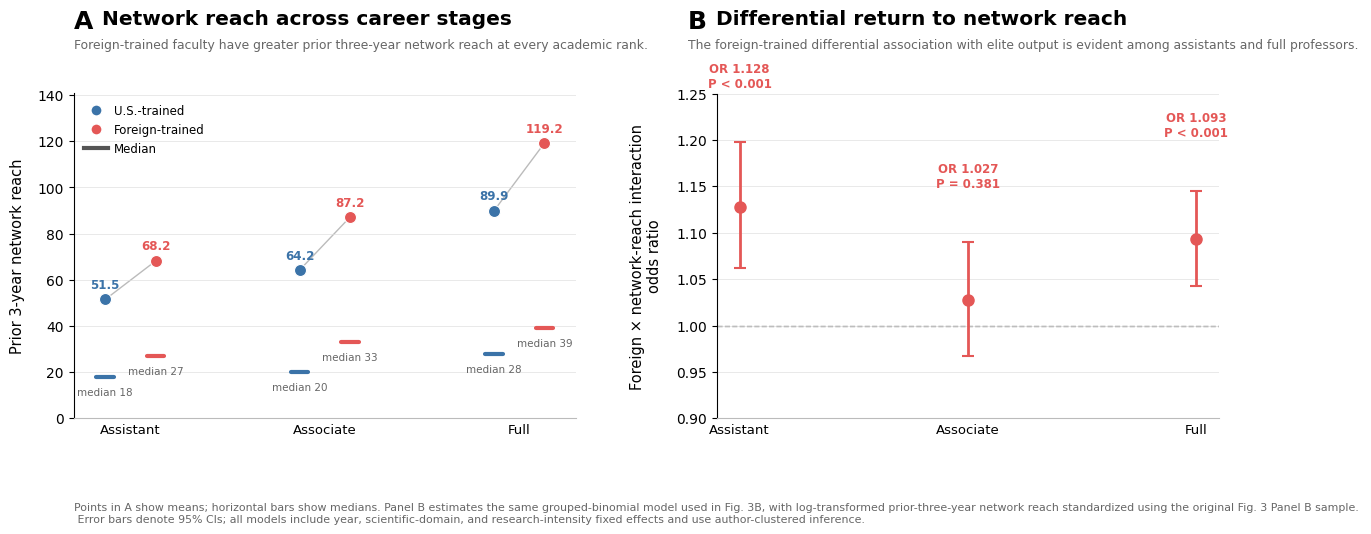

In [ ]:
# =============================================================================
# SUPPLEMENTARY FIGURE — CAREER-STAGE HETEROGENEITY
#
# Panel A:
#   Network reach by career stage and PhD origin
#
# Panel B:
#   Foreign x network-reach interaction OR by career stage
#
# Uses outputs from:
#   figure3_heterogeneity_career_stage_descriptives_final.csv
#   figure3_heterogeneity_career_stage_final.csv
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# SETTINGS
# =============================================================================

OUTDIR = "figure3_heterogeneity"

DESC_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_career_stage_descriptives_final.csv"
)

RESULT_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_career_stage_final.csv"
)

SAVE_PNG = os.path.join(
    OUTDIR,
    "figure3_career_stage_heterogeneity.png"
)

SAVE_PDF = os.path.join(
    OUTDIR,
    "figure3_career_stage_heterogeneity.pdf"
)


DOMESTIC = "#3B73A8"
FOREIGN = "#E45756"
ZERO = "#888888"
GRID = "#DDDDDD"
TEXT = "#202020"
SUBTEXT = "#666666"


# =============================================================================
# LOAD
# =============================================================================

desc = pd.read_csv(
    DESC_FILE
)

results = pd.read_csv(
    RESULT_FILE
)


# =============================================================================
# ORDER
# =============================================================================

stage_order = [
    "Assistant",
    "Associate",
    "Full"
]

stage_x = {
    "Assistant": 0,
    "Associate": 1,
    "Full": 2
}


desc["career_stage"] = pd.Categorical(
    desc["career_stage"],
    categories=stage_order,
    ordered=True
)

desc["phd_type"] = pd.Categorical(
    desc["phd_type"],
    categories=[
        "domestic",
        "foreign"
    ],
    ordered=True
)

desc = desc.sort_values(
    [
        "career_stage",
        "phd_type"
    ]
)


# =============================================================================
# EXTRACT RANK-SPECIFIC MODEL RESULTS
# =============================================================================

rank_results = results[
    results["sample"].isin(
        [
            "Assistant",
            "Associate",
            "Full"
        ]
    )
].copy()


rank_results["career_stage"] = pd.Categorical(
    rank_results["sample"],
    categories=stage_order,
    ordered=True
)

rank_results = rank_results.sort_values(
    "career_stage"
)


# =============================================================================
# FIGURE
# =============================================================================

fig = plt.figure(
    figsize=(12.8, 5.8),
    facecolor="white"
)

gs = fig.add_gridspec(
    1,
    2,
    left=0.075,
    right=0.97,
    bottom=0.22,
    top=0.78,
    wspace=0.28
)


ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])


# =============================================================================
# PANEL A
# NETWORK REACH
# =============================================================================

offset = {
    "domestic": -0.13,
    "foreign": 0.13
}

origin_color = {
    "domestic": DOMESTIC,
    "foreign": FOREIGN
}

origin_label = {
    "domestic": "U.S.-trained",
    "foreign": "Foreign-trained"
}


for _, row in desc.iterrows():

    x = (
        stage_x[
            str(row["career_stage"])
        ]
        +
        offset[
            str(row["phd_type"])
        ]
    )

    mean = row["mean_reach"]
    median = row["median_reach"]

    color = origin_color[
        str(row["phd_type"])
    ]

    # Mean
    ax_a.scatter(
        x,
        mean,
        s=75,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        zorder=4
    )

    # Median
    ax_a.plot(
        [
            x - 0.045,
            x + 0.045
        ],
        [
            median,
            median
        ],
        color=color,
        linewidth=3.0,
        solid_capstyle="round",
        zorder=5
    )

    # Mean label
    ax_a.text(
        x,
        mean + 3.5,
        f"{mean:.1f}",
        ha="center",
        va="bottom",
        fontsize=8.6,
        fontweight="bold",
        color=color
    )

    # Median label, positioned below mean
    ax_a.text(
        x,
        median - 4.5,
        f"median {median:.0f}",
        ha="center",
        va="top",
        fontsize=7.5,
        color=SUBTEXT
    )


ax_a.set_xticks(
    [0, 1, 2]
)

ax_a.set_xticklabels(
    stage_order,
    fontsize=9.5
)

ax_a.set_ylabel(
    "Prior 3-year network reach",
    fontsize=10.5,
    labelpad=9
)

ax_a.tick_params(
    axis="x",
    length=0
)

ax_a.grid(
    axis="y",
    color=GRID,
    linewidth=0.7,
    alpha=0.65
)

for spine in [
    "top",
    "right"
]:
    ax_a.spines[
        spine
    ].set_visible(False)

ax_a.spines[
    "bottom"
].set_color(
    "#BBBBBB"
)


# =============================================================================
# PANEL A — CONNECT U.S. AND FOREIGN MEANS
# =============================================================================

for stage in stage_order:

    subset = desc[
        desc["career_stage"]
        ==
        stage
    ]

    us = subset[
        subset["phd_type"]
        ==
        "domestic"
    ]["mean_reach"].iloc[0]

    foreign = subset[
        subset["phd_type"]
        ==
        "foreign"
    ]["mean_reach"].iloc[0]

    x0 = stage_x[stage] + offset["domestic"]
    x1 = stage_x[stage] + offset["foreign"]

    ax_a.plot(
        [x0, x1],
        [us, foreign],
        color="#BBBBBB",
        linewidth=1.0,
        zorder=1
    )


# =============================================================================
# PANEL A — LEGEND
# =============================================================================

legend_a = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=DOMESTIC,
        markeredgecolor="white",
        markersize=8,
        label="U.S.-trained"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=FOREIGN,
        markeredgecolor="white",
        markersize=8,
        label="Foreign-trained"
    ),

    Line2D(
        [0],
        [0],
        color="#555555",
        linewidth=3,
        label="Median"
    )
]

ax_a.legend(
    handles=legend_a,
    frameon=False,
    loc="upper left",
    fontsize=8.5,
    handletextpad=0.5
)


# =============================================================================
# PANEL A — Y LIMIT
# =============================================================================

max_reach = desc["mean_reach"].max()

ax_a.set_ylim(
    0,
    max_reach * 1.18
)


# =============================================================================
# PANEL B
# FOREIGN x REACH INTERACTION
# =============================================================================

x = np.arange(
    len(rank_results)
)

or_values = (
    rank_results[
        "interaction_or"
    ]
    .to_numpy()
)

or_low = (
    rank_results[
        "interaction_or_low"
    ]
    .to_numpy()
)

or_high = (
    rank_results[
        "interaction_or_high"
    ]
    .to_numpy()
)


yerr = np.vstack(
    [
        or_values - or_low,
        or_high - or_values
    ]
)


ax_b.errorbar(
    x,
    or_values,

    yerr=yerr,

    fmt="o",

    color=FOREIGN,
    ecolor=FOREIGN,

    markersize=8,

    elinewidth=2.0,

    capsize=4,
    capthick=1.5,

    zorder=4
)


# Zero / null-effect reference
ax_b.axhline(
    1.0,
    color=ZERO,
    linestyle="--",
    linewidth=1.0,
    zorder=1
)


# =============================================================================
# PANEL B — LABELS
# =============================================================================

p_labels = []

for _, row in rank_results.iterrows():

    p = row["interaction_p"]

    if p < 0.001:
        p_text = "P < 0.001"
    else:
        p_text = f"P = {p:.3f}"

    p_labels.append(
        p_text
    )


for i, row in rank_results.iterrows():

    xi = stage_x[
        str(row["career_stage"])
    ]

    yi = row["interaction_or"]

    ci_low = row[
        "interaction_or_low"
    ]

    ci_high = row[
        "interaction_or_high"
    ]

    p = row["interaction_p"]


    if str(row["career_stage"]) == "Assistant":

        xtext = xi
        ytext = ci_high + 0.055

        ha = "center"

    elif str(row["career_stage"]) == "Associate":

        xtext = xi
        ytext = ci_high + 0.055

        ha = "center"

    else:

        xtext = xi
        ytext = ci_high + 0.055

        ha = "center"


    p_text = (
        "P < 0.001"
        if p < 0.001
        else
        f"P = {p:.3f}"
    )


    ax_b.text(
        xtext,
        ytext,
        f"OR {yi:.3f}\n{p_text}",
        ha=ha,
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color=FOREIGN
    )


ax_b.set_xticks(
    x
)

ax_b.set_xticklabels(
    stage_order,
    fontsize=9.5
)

ax_b.set_ylabel(
    "Foreign × network-reach interaction\nodds ratio",
    fontsize=10.5,
    labelpad=10
)

ax_b.tick_params(
    axis="x",
    length=0
)

ax_b.grid(
    axis="y",
    color=GRID,
    linewidth=0.7,
    alpha=0.65
)

for spine in [
    "top",
    "right"
]:
    ax_b.spines[
        spine
    ].set_visible(False)

ax_b.spines[
    "bottom"
].set_color(
    "#BBBBBB"
)


# Reasonable scale around null
ax_b.set_ylim(
    0.90,
    1.25
)


# =============================================================================
# PANEL TITLES
# =============================================================================

fig.text(
    0.075,
    0.925,
    "A",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.097,
    0.925,
    "Network reach across career stages",
    fontsize=14.5,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.075,
    0.875,
    (
        "Foreign-trained faculty have greater prior three-year network "
        "reach at every academic rank."
    ),
    fontsize=8.9,
    color=SUBTEXT,
    ha="left",
    va="top"
)


fig.text(
    0.555,
    0.925,
    "B",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.577,
    0.925,
    "Differential return to network reach",
    fontsize=14.5,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.555,
    0.875,
    (
        "The foreign-trained differential association with elite output "
        "is evident among assistants and full professors."
    ),
    fontsize=8.9,
    color=SUBTEXT,
    ha="left",
    va="top"
)


# =============================================================================
# BOTTOM NOTE
# =============================================================================

fig.text(
    0.075,
    0.075,
    (
        "Points in A show means; horizontal bars show medians. "
        "Panel B estimates the same grouped-binomial model used in Fig. 3B, "
        "with log-transformed prior-three-year network reach standardized "
        "using the original Fig. 3 Panel B sample. \n Error bars denote 95% CIs; "
        "all models include year, scientific-domain, and research-intensity "
        "fixed effects and use author-clustered inference."
    ),
    fontsize=7.9,
    color=SUBTEXT,
    ha="left",
    va="top"
)


# =============================================================================
# SAVE
# =============================================================================

plt.savefig(
    SAVE_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    SAVE_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [ ]:
# =============================================================================
# FIGURE 3 — HETEROGENEITY #2
# INSTITUTIONAL RESEARCH ENVIRONMENT
#
# EXACTLY COMPARABLE TO FINAL FIGURE 3 PANEL B
#
# Strata:
#   1. Highest research
#   2. Other institutions
#
# Exposure:
#   z[log(1 + prior-3-year network reach)]
#
# IMPORTANT:
#   Standardization uses ORIGINAL Figure 3 Panel B mean/SD.
#
# Outcome:
#   grouped-binomial:
#       successes = top1_papers
#       failures  = papers - top1_papers
#
# Inference:
#   direct author-clustered sandwich covariance
#
# Controls:
#
#   Original pooled:
#       year FE + domain FE + research-intensity FE
#
#   Highest research:
#       year FE + domain FE
#       (research intensity is constant)
#
#   Other institutions:
#       year FE + domain FE + research-intensity FE
#
# No productivity control.
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

ORIGINAL_TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final"
)

HET_TABLE = (
    "foreign-phd.facultyraw."
    "figure3_institution_heterogeneity"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD ORIGINAL FIGURE 3 PANEL B
# =============================================================================

query_original = f"""

SELECT

    author_id,
    year,

    phd_type,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree

FROM `{ORIGINAL_TABLE}`

WHERE year BETWEEN 2011 AND 2020

  AND panel_b_eligible = 1

  AND papers > 0

  AND prior3_log_degree IS NOT NULL

"""


original = (
    client
    .query(query_original)
    .to_dataframe()
)


# =============================================================================
# 3. LOAD INSTITUTIONAL HETEROGENEITY SAMPLE
# =============================================================================

query_het = f"""

SELECT

    author_id,
    year,

    phd_type,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree,

    institutional_stratum

FROM `{HET_TABLE}`

WHERE year BETWEEN 2011 AND 2020

  AND panel_b_eligible = 1

  AND papers > 0

  AND prior3_log_degree IS NOT NULL

  AND institutional_stratum IS NOT NULL

"""


het = (
    client
    .query(query_het)
    .to_dataframe()
)


# =============================================================================
# 4. CLEAN
# =============================================================================

def clean_data(data):

    d = data.copy()


    for col in [

        "year",
        "research_intensity_level",

        "papers",
        "top1_papers",

        "prior3_degree",
        "prior3_log_degree",

    ]:

        d[col] = pd.to_numeric(
            d[col],
            errors="coerce"
        )


    d = d[
        d["year"].notna()
    ].copy()


    d["year"] = (
        d["year"]
        .astype(int)
    )


    d["phd_type"] = (

        d["phd_type"]

        .astype(str)

        .str.lower()

        .str.strip()

    )


    d = d[
        d["phd_type"].isin(
            [
                "domestic",
                "foreign",
            ]
        )
    ].copy()


    # -------------------------------------------------------------------------
    # Same categorical construction as Figure 3
    # -------------------------------------------------------------------------

    d["year_cat"] = (
        d["year"]
        .astype(str)
    )


    d["domain_cat"] = (

        d["primary_domain"]

        .fillna("Unknown")

        .astype(str)

    )


    d["research_cat"] = (

        d["research_intensity_level"]

        .fillna(-999)

        .astype(str)

    )


    valid = (

        d["papers"].notna()

        &

        d["top1_papers"].notna()

        &

        d["prior3_log_degree"].notna()

        &

        (d["papers"] > 0)

        &

        (d["top1_papers"] >= 0)

        &

        (
            d["top1_papers"]
            <=
            d["papers"]
        )

    )


    return (
        d.loc[valid]
        .copy()
    )


original = clean_data(
    original
)

het = clean_data(
    het
)


# =============================================================================
# 5. ORIGINAL FIGURE 3 EXPOSURE SCALE
#
# EXACTLY:
#
#   z[prior3_log_degree]
#
#   SD uses ddof=0
# =============================================================================

REACH_LOG_MEAN = (

    original[
        "prior3_log_degree"
    ]

    .astype(float)

    .mean()

)


REACH_LOG_SD = (

    original[
        "prior3_log_degree"
    ]

    .astype(float)

    .std(ddof=0)

)


original["reach_z"] = (

    (
        original[
            "prior3_log_degree"
        ]

        -

        REACH_LOG_MEAN
    )

    /

    REACH_LOG_SD

).astype(float)


het["reach_z"] = (

    (
        het[
            "prior3_log_degree"
        ]

        -

        REACH_LOG_MEAN
    )

    /

    REACH_LOG_SD

).astype(float)


# =============================================================================
# 6. AUDIT
# =============================================================================

print("=" * 80)
print("FIGURE 3 — INSTITUTIONAL-ENVIRONMENT HETEROGENEITY")
print("=" * 80)
print()


print(
    "Original Figure 3 reach scale:"
)

print(
    f"  log-reach mean = "
    f"{REACH_LOG_MEAN:.6f}"
)

print(
    f"  log-reach SD   = "
    f"{REACH_LOG_SD:.6f}"
)

print()


print(
    "Original Panel B:"
)

print(
    f"  Author-years: "
    f"{len(original):,}"
)

print(
    f"  Authors:      "
    f"{original['author_id'].nunique():,}"
)

print()


print(
    "Institution-classified Panel B:"
)

print(
    f"  Author-years: "
    f"{len(het):,}"
)

print(
    f"  Authors:      "
    f"{het['author_id'].nunique():,}"
)

print(
    "  Retention:    "
    f"{100 * len(het) / len(original):.2f}% "
    "of author-years"
)

print()


# =============================================================================
# 7. MODEL FUNCTION
# =============================================================================

def fit_exact_model(
    data,
    label,
    include_research_fe=True
):

    d = data.copy()


    # -------------------------------------------------------------------------
    # Model specification
    # -------------------------------------------------------------------------

    if include_research_fe:

        rhs_formula = (

            "reach_z * "

            'C('
            'phd_type, '
            'Treatment(reference="domestic")'
            ') + '

            "C(year_cat) + "

            "C(domain_cat) + "

            "C(research_cat)"

        )

    else:

        rhs_formula = (

            "reach_z * "

            'C('
            'phd_type, '
            'Treatment(reference="domestic")'
            ') + '

            "C(year_cat) + "

            "C(domain_cat)"

        )


    # -------------------------------------------------------------------------
    # Required columns
    # -------------------------------------------------------------------------

    cols = [

        "top1_papers",
        "papers",

        "reach_z",

        "phd_type",

        "year_cat",
        "domain_cat",

        "author_id",

        "prior3_degree",
        "prior3_log_degree",

    ]


    if include_research_fe:

        cols.append(
            "research_cat"
        )


    d = (

        d[
            cols
        ]

        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan
        )

        .dropna()

        .copy()

    )


    # -------------------------------------------------------------------------
    # Numeric
    # -------------------------------------------------------------------------

    for col in [

        "top1_papers",
        "papers",
        "reach_z",

    ]:

        d[col] = (

            pd.to_numeric(
                d[col],
                errors="coerce"
            )

            .astype(float)

        )


    d = d[

        (d["papers"] > 0)

        &

        (d["top1_papers"] >= 0)

        &

        (
            d["top1_papers"]
            <=
            d["papers"]
        )

    ].copy()


    # -------------------------------------------------------------------------
    # Strings
    # -------------------------------------------------------------------------

    string_cols = [

        "phd_type",
        "year_cat",
        "domain_cat",
        "author_id",

    ]


    if include_research_fe:

        string_cols.append(
            "research_cat"
        )


    for col in string_cols:

        d[col] = (
            d[col]
            .astype(str)
        )


    # =========================================================================
    # DESIGN MATRIX
    # =========================================================================

    X_df = dmatrix(

        rhs_formula,

        data=d,

        return_type="dataframe"

    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # =========================================================================
    # GROUPED-BINOMIAL OUTCOME
    # =========================================================================

    successes = (

        d[
            "top1_papers"
        ]

        .to_numpy(
            dtype=float
        )

    )


    failures = (

        d[
            "papers"
        ]

        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # =========================================================================
    # GLM
    # =========================================================================

    glm = sm.GLM(

        endog=endog,

        exog=X,

        family=sm.families.Binomial()

    )


    fit = glm.fit()


    # =========================================================================
    # AUTHOR-CLUSTERED SANDWICH
    # =========================================================================

    score_obs = np.asarray(

        glm.score_obs(
            fit.params
        ),

        dtype=float

    )


    cluster_codes, cluster_labels = (

        pd.factorize(

            d[
                "author_id"
            ],

            sort=False

        )

    )


    G = len(
        cluster_labels
    )

    N = len(d)

    K = X.shape[1]


    cluster_scores = np.zeros(

        (
            G,
            K,
        ),

        dtype=float

    )


    np.add.at(

        cluster_scores,

        cluster_codes,

        score_obs

    )


    meat = (

        cluster_scores.T

        @

        cluster_scores

    )


    bread = np.asarray(

        fit.normalized_cov_params,

        dtype=float

    )


    cluster_cov = (

        bread

        @

        meat

        @

        bread

    )


    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )


        cluster_cov *= (
            correction
        )


    cluster_se = np.sqrt(

        np.diag(
            cluster_cov
        )

    )


    # =========================================================================
    # INTERACTION
    # =========================================================================

    coef_names = list(
        X_df.columns
    )


    interaction_candidates = [

        name

        for name in coef_names

        if (

            "reach_z" in name

            and

            "phd_type" in name

            and

            "foreign" in name

            and

            ":" in name

        )

    ]


    if (
        len(
            interaction_candidates
        )
        !=
        1
    ):

        raise ValueError(

            "Could not uniquely identify "
            "foreign × reach interaction.\n"

            f"Candidates: "
            f"{interaction_candidates}"

        )


    interaction_term = (
        interaction_candidates[0]
    )


    interaction_idx = (
        coef_names.index(
            interaction_term
        )
    )


    beta = float(
        fit.params[
            interaction_idx
        ]
    )


    se = float(
        cluster_se[
            interaction_idx
        ]
    )


    z = (
        beta
        /
        se
    )


    p = float(

        2
        *
        norm.sf(
            abs(z)
        )

    )


    beta_low = (
        beta
        -
        1.96 * se
    )


    beta_high = (
        beta
        +
        1.96 * se
    )


    interaction_or = (
        np.exp(beta)
    )


    interaction_or_low = (
        np.exp(beta_low)
    )


    interaction_or_high = (
        np.exp(beta_high)
    )


    # =========================================================================
    # WITHIN-GROUP REACH SLOPES
    # =========================================================================

    reach_idx = (
        coef_names.index(
            "reach_z"
        )
    )


    domestic_beta = float(
        fit.params[
            reach_idx
        ]
    )


    foreign_beta = (
        domestic_beta
        +
        beta
    )


    domestic_or = (
        np.exp(
            domestic_beta
        )
    )


    foreign_or = (
        np.exp(
            foreign_beta
        )
    )


    # =========================================================================
    # PRINT
    # =========================================================================

    print("=" * 80)
    print(label.upper())
    print("=" * 80)
    print()


    print(
        f"Author-years: "
        f"{N:,}"
    )

    print(
        f"Authors:      "
        f"{G:,}"
    )

    print(
        f"Papers:       "
        f"{d['papers'].sum():,.0f}"
    )

    print(
        f"Top-1%:       "
        f"{d['top1_papers'].sum():,.0f}"
    )

    print(
        "Top-1% rate:  "
        f"{d['top1_papers'].sum() / d['papers'].sum():.3%}"
    )

    print()


    print(
        "Raw network reach:"
    )

    print(
        f"  mean   = "
        f"{d['prior3_degree'].mean():.3f}"
    )

    print(
        f"  median = "
        f"{d['prior3_degree'].median():.3f}"
    )

    print()


    print(
        "Figure 3 standardized log reach:"
    )

    print(
        f"  mean = "
        f"{d['reach_z'].mean():.4f}"
    )

    print(
        f"  SD   = "
        f"{d['reach_z'].std(ddof=0):.4f}"
    )

    print()


    print(
        "Foreign × network-reach interaction"
    )

    print()


    print(
        f"beta = "
        f"{beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = "
        f"{z:.3f}"
    )

    print(
        f"p = "
        f"{p:.6g}"
    )

    print()


    print(
        "Interaction OR per +1 ORIGINAL "
        "Figure 3 SD log network reach = "
        f"{interaction_or:.3f} "
        f"["
        f"{interaction_or_low:.3f}, "
        f"{interaction_or_high:.3f}"
        f"]"
    )

    print()


    print(
        "Within-group reach associations:"
    )

    print(
        f"  U.S.-trained OR:     "
        f"{domestic_or:.3f}"
    )

    print(
        f"  Foreign-trained OR: "
        f"{foreign_or:.3f}"
    )

    print()


    print(
        "Research-intensity FE: "
        f"{'Yes' if include_research_fe else 'No — stratum is constant'}"
    )

    print()


    return {

        "sample":
            label,

        "author_years":
            N,

        "authors":
            G,

        "papers":
            float(
                d["papers"].sum()
            ),

        "top1_papers":
            float(
                d["top1_papers"].sum()
            ),

        "top1_rate":
            float(
                d["top1_papers"].sum()
                /
                d["papers"].sum()
            ),

        "raw_reach_mean":
            float(
                d["prior3_degree"].mean()
            ),

        "raw_reach_median":
            float(
                d["prior3_degree"].median()
            ),

        "reach_z_mean":
            float(
                d["reach_z"].mean()
            ),

        "reach_z_sd":
            float(
                d["reach_z"].std(
                    ddof=0
                )
            ),

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            interaction_or,

        "interaction_or_low":
            interaction_or_low,

        "interaction_or_high":
            interaction_or_high,

        "domestic_reach_or":
            domestic_or,

        "foreign_reach_or":
            foreign_or,

        "research_intensity_fe":
            include_research_fe,

    }


# =============================================================================
# 8. FIT MODELS
# =============================================================================

results = []


# -----------------------------------------------------------------------------
# Original Figure 3 validation
# -----------------------------------------------------------------------------

result = fit_exact_model(

    original,

    "Original Figure 3 Panel B",

    include_research_fe=True

)

results.append(
    result
)


# -----------------------------------------------------------------------------
# Highest-research institutions
# -----------------------------------------------------------------------------

highest = (

    het[
        het[
            "institutional_stratum"
        ]
        ==
        "Highest research"
    ]

    .copy()

)


result = fit_exact_model(

    highest,

    "Highest research",

    include_research_fe=False

)

results.append(
    result
)


# -----------------------------------------------------------------------------
# Other institutions
# -----------------------------------------------------------------------------

other = (

    het[
        het[
            "institutional_stratum"
        ]
        ==
        "Other institutions"
    ]

    .copy()

)


result = fit_exact_model(

    other,

    "Other institutions",

    include_research_fe=True

)

results.append(
    result
)


# =============================================================================
# 9. FINAL TABLE
# =============================================================================

results_df = pd.DataFrame(
    results
)


print("=" * 80)

print(
    "INSTITUTIONAL-ENVIRONMENT HETEROGENEITY — FINAL RESULTS"
)

print("=" * 80)

print()


print(

    results_df[
        [

            "sample",

            "interaction_beta",
            "interaction_se",

            "interaction_or",
            "interaction_or_low",
            "interaction_or_high",
            "interaction_p",

            "domestic_reach_or",
            "foreign_reach_or",

            "author_years",
            "authors",

        ]
    ]

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 10. DESCRIPTIVES BY STRATUM × PHD ORIGIN
# =============================================================================

descriptives = (

    het

    .groupby(
        [
            "institutional_stratum",
            "phd_type",
        ],
        as_index=False
    )

    .agg(

        author_years=(
            "author_id",
            "size"
        ),

        authors=(
            "author_id",
            "nunique"
        ),

        mean_reach=(
            "prior3_degree",
            "mean"
        ),

        median_reach=(
            "prior3_degree",
            "median"
        ),

        mean_log_reach=(
            "prior3_log_degree",
            "mean"
        ),

        papers=(
            "papers",
            "sum"
        ),

        top1_papers=(
            "top1_papers",
            "sum"
        ),

    )

)


descriptives[
    "top1_rate"
] = (

    descriptives[
        "top1_papers"
    ]

    /

    descriptives[
        "papers"
    ]

)


print("=" * 80)

print(
    "DESCRIPTIVES BY INSTITUTIONAL ENVIRONMENT"
)

print("=" * 80)

print()


print(
    descriptives.to_string(
        index=False
    )
)

print()


# =============================================================================
# 11. SAVE
# =============================================================================

results_file = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_institution_final.csv"

)


descriptives_file = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_institution_descriptives_final.csv"

)


results_df.to_csv(
    results_file,
    index=False
)


descriptives.to_csv(
    descriptives_file,
    index=False
)


print("=" * 80)

print(
    "SAVED"
)

print("=" * 80)

print()


print(
    results_file
)

print(
    descriptives_file
)

FIGURE 3 — INSTITUTIONAL-ENVIRONMENT HETEROGENEITY

Original Figure 3 reach scale:
  log-reach mean = 3.231555
  log-reach SD   = 1.328886

Original Panel B:
  Author-years: 1,119,314
  Authors:      200,348

Institution-classified Panel B:
  Author-years: 1,113,110
  Authors:      199,250
  Retention:    99.45% of author-years

ORIGINAL FIGURE 3 PANEL B

Author-years: 1,119,314
Authors:      200,348
Papers:       7,630,784
Top-1%:       354,194
Top-1% rate:  4.642%

Raw network reach:
  mean   = 75.681
  median = 24.000

Figure 3 standardized log reach:
  mean = 0.0000
  SD   = 1.0000

Foreign × network-reach interaction

beta = 0.08713
author-clustered SE = 0.01782
z = 4.888
p = 1.01676e-06

Interaction OR per +1 ORIGINAL Figure 3 SD log network reach = 1.091 [1.054, 1.130]

Within-group reach associations:
  U.S.-trained OR:     1.359
  Foreign-trained OR: 1.483

Research-intensity FE: Yes

HIGHEST RESEARCH

Author-years: 991,308
Authors:      173,331
Papers:       6,927,285
Top-1%:

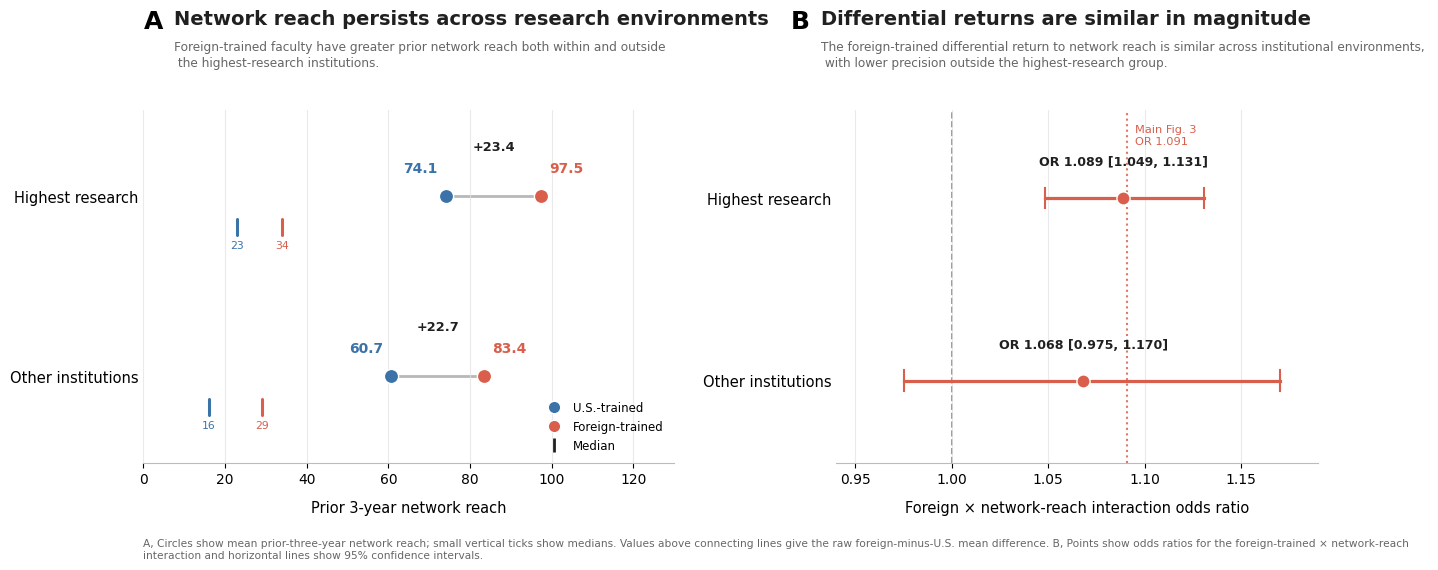

Saved:
figure3_heterogeneity/figure3_institution_heterogeneity_supplement.png
figure3_heterogeneity/figure3_institution_heterogeneity_supplement.pdf


In [ ]:
# =============================================================================
# SUPPLEMENTARY FIGURE
# NETWORK POSITION AND ELITE-OUTPUT RETURNS ACROSS
# INSTITUTIONAL RESEARCH ENVIRONMENTS
#
# Panel A
#   Raw prior-3-year network reach by PhD origin
#   within institutional environment.
#
#   - circles = means
#   - small vertical ticks = medians
#   - connecting line = within-environment foreign-domestic difference
#
# Panel B
#   Foreign × network-reach interaction OR
#   from the exact Figure 3 specification.
#
#   - points = OR
#   - horizontal lines = 95% CI
#   - dashed vertical line = null (OR = 1)
#   - dotted vertical line = pooled Fig. 3 estimate
#
# Input files:
#   figure3_heterogeneity_institution_final.csv
#   figure3_heterogeneity_institution_descriptives_final.csv
#
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# =============================================================================
# 1. SETTINGS
# =============================================================================

OUTDIR = "figure3_heterogeneity"

RESULT_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_institution_final.csv"
)

DESC_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_institution_descriptives_final.csv"
)

PNG_FILE = os.path.join(
    OUTDIR,
    "figure3_institution_heterogeneity_supplement.png"
)

PDF_FILE = os.path.join(
    OUTDIR,
    "figure3_institution_heterogeneity_supplement.pdf"
)


# -----------------------------------------------------------------------------
# Colors
# -----------------------------------------------------------------------------

DOMESTIC = "#3B73A8"
FOREIGN = "#D95F4C"

CONNECTOR = "#B8B8B8"
GRID = "#E3E3E3"

TEXT = "#202020"
SUBTEXT = "#666666"

REFERENCE = "#8A8A8A"


# =============================================================================
# 2. LOAD
# =============================================================================

results = pd.read_csv(
    RESULT_FILE
)

desc = pd.read_csv(
    DESC_FILE
)


# =============================================================================
# 3. CLEAN LABELS
# =============================================================================

origin_labels = {
    "domestic": "U.S.-trained",
    "foreign": "Foreign-trained",
}

environment_labels = {
    "Highest research": "Highest research",
    "Other institutions": "Other institutions",
}


desc["origin_label"] = (
    desc["phd_type"]
    .map(origin_labels)
)

desc["environment_label"] = (
    desc["institutional_stratum"]
    .map(environment_labels)
)


# =============================================================================
# 4. ORDER
# =============================================================================

ENV_ORDER = [
    "Highest research",
    "Other institutions",
]


desc["institutional_stratum"] = pd.Categorical(
    desc["institutional_stratum"],
    categories=ENV_ORDER,
    ordered=True
)

desc = desc.sort_values(
    [
        "institutional_stratum",
        "phd_type",
    ]
)


# =============================================================================
# 5. EXTRACT MODEL RESULTS
# =============================================================================

pooled = results[
    results["sample"]
    ==
    "Original Figure 3 Panel B"
].iloc[0]


stratified = results[
    results["sample"].isin(
        ENV_ORDER
    )
].copy()


stratified["sample"] = pd.Categorical(
    stratified["sample"],
    categories=ENV_ORDER,
    ordered=True
)

stratified = stratified.sort_values(
    "sample"
)


POOLED_OR = float(
    pooled["interaction_or"]
)

POOLED_LOW = float(
    pooled["interaction_or_low"]
)

POOLED_HIGH = float(
    pooled["interaction_or_high"]
)


# =============================================================================
# 6. FIGURE
# =============================================================================

fig = plt.figure(
    figsize=(13.2, 6.3),
    facecolor="white"
)


gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[
        1.10,
        1.00,
    ],
    left=0.075,
    right=0.965,
    bottom=0.205,
    top=0.765,
    wspace=0.32,
)


ax_a = fig.add_subplot(
    gs[0, 0]
)

ax_b = fig.add_subplot(
    gs[0, 1]
)


# =============================================================================
# 7. PANEL A
# NETWORK REACH
# =============================================================================

# Use environments as rows.
# This makes the domestic → foreign gap extremely easy to read.

y_positions = {
    "Highest research": 1,
    "Other institutions": 0,
}


for environment in ENV_ORDER:

    subset = desc[
        desc["institutional_stratum"]
        ==
        environment
    ]


    domestic = subset[
        subset["phd_type"]
        ==
        "domestic"
    ].iloc[0]


    foreign = subset[
        subset["phd_type"]
        ==
        "foreign"
    ].iloc[0]


    y = y_positions[
        environment
    ]


    d_mean = float(
        domestic["mean_reach"]
    )

    f_mean = float(
        foreign["mean_reach"]
    )


    d_median = float(
        domestic["median_reach"]
    )

    f_median = float(
        foreign["median_reach"]
    )


    difference = (
        f_mean
        -
        d_mean
    )


    # -------------------------------------------------------------------------
    # Connector
    # -------------------------------------------------------------------------

    ax_a.plot(
        [
            d_mean,
            f_mean,
        ],
        [
            y,
            y,
        ],
        color=CONNECTOR,
        linewidth=2.0,
        zorder=1,
    )


    # -------------------------------------------------------------------------
    # Mean points
    # -------------------------------------------------------------------------

    ax_a.scatter(
        d_mean,
        y,
        s=105,
        color=DOMESTIC,
        edgecolor="white",
        linewidth=1.0,
        zorder=4,
    )


    ax_a.scatter(
        f_mean,
        y,
        s=105,
        color=FOREIGN,
        edgecolor="white",
        linewidth=1.0,
        zorder=4,
    )


    # -------------------------------------------------------------------------
    # Mean labels
    #
    # Put labels on opposite sides of points so they do not collide with
    # the connector or each other.
    # -------------------------------------------------------------------------

    ax_a.text(
        d_mean - 2.0,
        y + 0.12,
        f"{d_mean:.1f}",
        ha="right",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=DOMESTIC,
    )


    ax_a.text(
        f_mean + 2.0,
        y + 0.12,
        f"{f_mean:.1f}",
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=FOREIGN,
    )


    # -------------------------------------------------------------------------
    # Difference label
    # -------------------------------------------------------------------------

    midpoint = (
        d_mean
        +
        f_mean
    ) / 2


    ax_a.text(
        midpoint,
        y + 0.24,
        f"+{difference:.1f}",
        ha="center",
        va="bottom",
        fontsize=9.3,
        fontweight="bold",
        color=TEXT,
    )


    # -------------------------------------------------------------------------
    # Median markers
    #
    # Put these slightly below the main dumbbell row.
    # -------------------------------------------------------------------------

    median_y = (
        y
        -
        0.17
    )


    ax_a.plot(
        [
            d_median,
            d_median,
        ],
        [
            median_y - 0.045,
            median_y + 0.045,
        ],
        color=DOMESTIC,
        linewidth=2.2,
        solid_capstyle="round",
        zorder=3,
    )


    ax_a.plot(
        [
            f_median,
            f_median,
        ],
        [
            median_y - 0.045,
            median_y + 0.045,
        ],
        color=FOREIGN,
        linewidth=2.2,
        solid_capstyle="round",
        zorder=3,
    )


    # Median text is deliberately placed below each marker.

    ax_a.text(
        d_median,
        median_y - 0.075,
        f"{d_median:.0f}",
        ha="center",
        va="top",
        fontsize=7.8,
        color=DOMESTIC,
    )


    ax_a.text(
        f_median,
        median_y - 0.075,
        f"{f_median:.0f}",
        ha="center",
        va="top",
        fontsize=7.8,
        color=FOREIGN,
    )


# =============================================================================
# 8. PANEL A FORMATTING
# =============================================================================

ax_a.set_yticks(
    [
        1,
        0,
    ]
)

ax_a.set_yticklabels(
    [
        "Highest research",
        "Other institutions",
    ],
    fontsize=10.5,
)


ax_a.set_xlabel(
    "Prior 3-year network reach",
    fontsize=10.5,
    labelpad=10,
)


ax_a.set_xlim(
    0,
    130,
)

ax_a.set_ylim(
    -0.48,
    1.48,
)


ax_a.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    alpha=0.75,
)


ax_a.tick_params(
    axis="y",
    length=0,
)


for spine in [
    "top",
    "right",
    "left",
]:

    ax_a.spines[
        spine
    ].set_visible(False)


ax_a.spines[
    "bottom"
].set_color(
    "#BBBBBB"
)


# =============================================================================
# 9. PANEL A LEGEND
# =============================================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=DOMESTIC,
        markeredgecolor="white",
        markersize=9,
        label="U.S.-trained",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=FOREIGN,
        markeredgecolor="white",
        markersize=9,
        label="Foreign-trained",
    ),

    Line2D(
        [0],
        [0],
        marker="|",
        linestyle="none",
        color=TEXT,
        markersize=10,
        markeredgewidth=2,
        label="Median",
    ),

]


ax_a.legend(
    handles=legend_handles,
    loc="lower right",
    frameon=False,
    fontsize=8.5,
    ncol=1,
    borderaxespad=0.5,
    handletextpad=0.6,
)


# =============================================================================
# 10. PANEL B
# FOREIGN × NETWORK-REACH INTERACTION
# =============================================================================

# We use a horizontal forest plot.
# This gives the confidence intervals more room and makes comparison with
# OR = 1 and the pooled Figure 3 estimate straightforward.

forest_y = {
    "Highest research": 1,
    "Other institutions": 0,
}


# -----------------------------------------------------------------------------
# Null reference
# -----------------------------------------------------------------------------

ax_b.axvline(
    1.0,
    color=REFERENCE,
    linestyle="--",
    linewidth=1.2,
    zorder=1,
)


# -----------------------------------------------------------------------------
# Main Figure 3 reference
# -----------------------------------------------------------------------------

ax_b.axvline(
    POOLED_OR,
    color=FOREIGN,
    linestyle=":",
    linewidth=1.5,
    alpha=0.85,
    zorder=1,
)


for _, row in stratified.iterrows():

    environment = str(
        row["sample"]
    )

    y = forest_y[
        environment
    ]


    estimate = float(
        row["interaction_or"]
    )

    low = float(
        row["interaction_or_low"]
    )

    high = float(
        row["interaction_or_high"]
    )


    # -------------------------------------------------------------------------
    # CI
    # -------------------------------------------------------------------------

    ax_b.plot(
        [
            low,
            high,
        ],
        [
            y,
            y,
        ],
        color=FOREIGN,
        linewidth=2.3,
        zorder=2,
    )


    # CI caps

    ax_b.plot(
        [
            low,
            low,
        ],
        [
            y - 0.055,
            y + 0.055,
        ],
        color=FOREIGN,
        linewidth=1.5,
        zorder=2,
    )


    ax_b.plot(
        [
            high,
            high,
        ],
        [
            y - 0.055,
            y + 0.055,
        ],
        color=FOREIGN,
        linewidth=1.5,
        zorder=2,
    )


    # -------------------------------------------------------------------------
    # Point
    # -------------------------------------------------------------------------

    ax_b.scatter(
        estimate,
        y,
        s=90,
        color=FOREIGN,
        edgecolor="white",
        linewidth=1.0,
        zorder=4,
    )


    # -------------------------------------------------------------------------
    # OR + CI label
    #
    # Put text above the CI rather than directly beside the point.
    # This avoids the overlay problem from the earlier figures.
    # -------------------------------------------------------------------------

    ax_b.text(
        estimate,
        y + 0.16,
        (
            f"OR {estimate:.3f} "
            f"[{low:.3f}, {high:.3f}]"
        ),
        ha="center",
        va="bottom",
        fontsize=9.1,
        fontweight="bold",
        color=TEXT,
    )


# =============================================================================
# 11. PANEL B — POOLED FIGURE 3 REFERENCE LABEL
# =============================================================================

ax_b.text(
    POOLED_OR + 0.004,
    1.40,
    (
        f"Main Fig. 3\n"
        f"OR {POOLED_OR:.3f}"
    ),
    ha="left",
    va="top",
    fontsize=8.2,
    color=FOREIGN,
)


# =============================================================================
# 12. PANEL B FORMATTING
# =============================================================================

ax_b.set_yticks(
    [
        1,
        0,
    ]
)

ax_b.set_yticklabels(
    [
        "Highest research",
        "Other institutions",
    ],
    fontsize=10.5,
)


ax_b.set_xlabel(
    "Foreign × network-reach interaction odds ratio",
    fontsize=10.5,
    labelpad=10,
)


ax_b.set_xlim(
    0.94,
    1.19,
)

ax_b.set_ylim(
    -0.45,
    1.48,
)


ax_b.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    alpha=0.75,
)


ax_b.tick_params(
    axis="y",
    length=0,
)


for spine in [
    "top",
    "right",
    "left",
]:

    ax_b.spines[
        spine
    ].set_visible(False)


ax_b.spines[
    "bottom"
].set_color(
    "#BBBBBB"
)


# =============================================================================
# 13. PANEL HEADERS
# =============================================================================

fig.text(
    0.075,
    0.925,
    "A",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top",
)


fig.text(
    0.098,
    0.925,
    "Network reach persists across research environments",
    fontsize=14.0,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="top",
)


fig.text(
    0.098,
    0.875,
    (
        "Foreign-trained faculty have greater prior network reach "
        "both within and outside \n the highest-research institutions."
    ),
    fontsize=8.7,
    color=SUBTEXT,
    ha="left",
    va="top",
)


fig.text(
    0.565,
    0.925,
    "B",
    fontsize=18,
    fontweight="bold",
    ha="left",
    va="top",
)


fig.text(
    0.588,
    0.925,
    "Differential returns are similar in magnitude",
    fontsize=14.0,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="top",
)


fig.text(
    0.588,
    0.875,
    (
        "The foreign-trained differential return to network reach "
        "is similar across institutional environments, \n with lower "
        "precision outside the highest-research group."
    ),
    fontsize=8.7,
    color=SUBTEXT,
    ha="left",
    va="top",
)


# =============================================================================
# 14. BOTTOM NOTE
# =============================================================================

fig.text(
    0.075,
    0.085,
    (
        "A, Circles show mean prior-three-year network reach; small vertical "
        "ticks show medians. Values above connecting lines give the raw "
        "foreign-minus-U.S. mean difference. "
        "B, Points show odds ratios for the foreign-trained × network-reach "
        "interaction and horizontal lines show 95% confidence intervals. "

    ),
    fontsize=7.7,
    color=SUBTEXT,
    ha="left",
    va="top",
    wrap=True,
)


# =============================================================================
# 15. SAVE
# =============================================================================

plt.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


plt.savefig(
    PDF_FILE,
    bbox_inches="tight",
    facecolor="white",
)


plt.show()


print("Saved:")
print(PNG_FILE)
print(PDF_FILE)

In [ ]:
# =============================================================================
# FIGURE 3 — ROBUSTNESS #3
# NETWORK-WINDOW ROBUSTNESS
#
# Tests:
#
#   A. WINDOW-SPECIFIC SAMPLES
#      prior 1 year  -> all 1-year-eligible author-years
#      prior 3 years -> all 3-year-eligible author-years
#      prior 5 years -> all 5-year-eligible author-years
#
#   B. COMMON SAMPLE
#      all three network definitions estimated on exactly the same
#      author-years: panel_b_common_eligible == 1
#
# Model is otherwise EXACTLY Figure 3 Panel B:
#
#   grouped-binomial top-1% outcome
#   reach_z × PhD origin
#   year FE
#   domain FE
#   research-intensity FE
#   author-clustered sandwich covariance
#
# No productivity control.
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

TABLE = (
    "foreign-phd.facultyraw."
    "figure3_network_window_robustness"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD
# =============================================================================

query = f"""

SELECT

    author_id,
    year,

    phd_type,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior1_degree,
    prior1_log_degree,

    prior3_degree,
    prior3_log_degree,

    prior5_degree,
    prior5_log_degree,

    panel_b_1yr_eligible,
    panel_b_3yr_eligible,
    panel_b_5yr_eligible,
    panel_b_common_eligible

FROM `{TABLE}`

WHERE year BETWEEN 2011 AND 2020

"""


df = (
    client
    .query(query)
    .to_dataframe()
)


# =============================================================================
# 3. CLEAN
# =============================================================================

numeric_cols = [

    "year",
    "research_intensity_level",

    "papers",
    "top1_papers",

    "prior1_degree",
    "prior1_log_degree",

    "prior3_degree",
    "prior3_log_degree",

    "prior5_degree",
    "prior5_log_degree",

    "panel_b_1yr_eligible",
    "panel_b_3yr_eligible",
    "panel_b_5yr_eligible",
    "panel_b_common_eligible",

]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df[
    df["year"].notna()
].copy()


df["year"] = (
    df["year"]
    .astype(int)
)


df["phd_type"] = (

    df["phd_type"]

    .astype(str)

    .str.lower()

    .str.strip()

)


df = df[
    df["phd_type"].isin(
        [
            "domestic",
            "foreign",
        ]
    )
].copy()


df["year_cat"] = (
    df["year"]
    .astype(str)
)


df["domain_cat"] = (

    df["primary_domain"]

    .fillna("Unknown")

    .astype(str)

)


df["research_cat"] = (

    df["research_intensity_level"]

    .fillna(-999)

    .astype(str)

)


# =============================================================================
# 4. AUDIT
# =============================================================================

print("=" * 80)

print(
    "FIGURE 3 — NETWORK-WINDOW ROBUSTNESS"
)

print("=" * 80)

print()


for years in [
    1,
    3,
    5,
]:

    eligible_col = (
        f"panel_b_{years}yr_eligible"
    )

    d = df[
        df[eligible_col] == 1
    ]

    print(
        f"PRIOR {years}-YEAR WINDOW"
    )

    print(
        f"  Author-years: "
        f"{len(d):,}"
    )

    print(
        f"  Authors:      "
        f"{d['author_id'].nunique():,}"
    )

    print(
        f"  Papers:       "
        f"{d['papers'].sum():,.0f}"
    )

    print()


common = df[
    df["panel_b_common_eligible"] == 1
]


print(
    "COMMON SAMPLE"
)

print(
    f"  Author-years: "
    f"{len(common):,}"
)

print(
    f"  Authors:      "
    f"{common['author_id'].nunique():,}"
)

print()


# =============================================================================
# 5. EXACT FIGURE 3 MODEL FUNCTION
# =============================================================================

rhs_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(domain_cat) + "

    "C(research_cat)"

)


def fit_window_model(
    data,
    degree_col,
    log_degree_col,
    label,
    analysis_type,
):

    d = data.copy()


    # =========================================================================
    # VALID OBSERVATIONS
    # =========================================================================

    d = d[

        d["papers"].notna()

        &

        d["top1_papers"].notna()

        &

        d[log_degree_col].notna()

        &

        (d["papers"] > 0)

        &

        (d["top1_papers"] >= 0)

        &

        (
            d["top1_papers"]
            <=
            d["papers"]
        )

    ].copy()


    # =========================================================================
    # STANDARDIZE THIS NETWORK MEASURE WITHIN THIS ESTIMATION SAMPLE
    # =========================================================================

    log_mean = float(

        d[
            log_degree_col
        ].mean()

    )


    log_sd = float(

        d[
            log_degree_col
        ].std(
            ddof=0
        )

    )


    d["reach_z"] = (

        (
            d[
                log_degree_col
            ]
            -
            log_mean
        )

        /

        log_sd

    )


    # =========================================================================
    # MODEL DATA
    # =========================================================================

    cols = [

        "top1_papers",
        "papers",

        "reach_z",

        "phd_type",

        "year_cat",
        "domain_cat",
        "research_cat",

        "author_id",

        degree_col,
        log_degree_col,

    ]


    d = (

        d[
            cols
        ]

        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan
        )

        .dropna()

        .copy()

    )


    for col in [

        "top1_papers",
        "papers",
        "reach_z",

    ]:

        d[col] = (

            pd.to_numeric(
                d[col],
                errors="coerce"
            )

            .astype(float)

        )


    for col in [

        "phd_type",
        "year_cat",
        "domain_cat",
        "research_cat",
        "author_id",

    ]:

        d[col] = (
            d[col]
            .astype(str)
        )


    # =========================================================================
    # DESIGN MATRIX
    # =========================================================================

    X_df = dmatrix(

        rhs_formula,

        data=d,

        return_type="dataframe"

    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # =========================================================================
    # GROUPED-BINOMIAL OUTCOME
    # =========================================================================

    successes = (

        d[
            "top1_papers"
        ]

        .to_numpy(
            dtype=float
        )

    )


    failures = (

        d[
            "papers"
        ]

        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # =========================================================================
    # GLM
    # =========================================================================

    glm = sm.GLM(

        endog=endog,

        exog=X,

        family=sm.families.Binomial()

    )


    fit = glm.fit()


    # =========================================================================
    # AUTHOR-CLUSTERED SANDWICH COVARIANCE
    # =========================================================================

    score_obs = np.asarray(

        glm.score_obs(
            fit.params
        ),

        dtype=float

    )


    cluster_codes, cluster_labels = (

        pd.factorize(

            d[
                "author_id"
            ],

            sort=False

        )

    )


    G = len(
        cluster_labels
    )

    N = len(d)

    K = X.shape[1]


    cluster_scores = np.zeros(

        (
            G,
            K,
        ),

        dtype=float

    )


    np.add.at(

        cluster_scores,

        cluster_codes,

        score_obs

    )


    meat = (

        cluster_scores.T

        @

        cluster_scores

    )


    bread = np.asarray(

        fit.normalized_cov_params,

        dtype=float

    )


    cluster_cov = (

        bread

        @

        meat

        @

        bread

    )


    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )


        cluster_cov *= (
            correction
        )


    cluster_se = np.sqrt(

        np.diag(
            cluster_cov
        )

    )


    # =========================================================================
    # COEFFICIENT NAMES
    # =========================================================================

    coef_names = list(
        X_df.columns
    )


    interaction_candidates = [

        name

        for name in coef_names

        if (

            "reach_z" in name

            and

            "phd_type" in name

            and

            "foreign" in name

            and

            ":" in name

        )

    ]


    if (
        len(
            interaction_candidates
        )
        !=
        1
    ):

        raise ValueError(

            "Could not identify "
            "foreign × reach interaction.\n"

            f"{interaction_candidates}"

        )


    interaction_term = (
        interaction_candidates[0]
    )


    interaction_idx = (
        coef_names.index(
            interaction_term
        )
    )


    reach_idx = (
        coef_names.index(
            "reach_z"
        )
    )


    # =========================================================================
    # INTERACTION
    # =========================================================================

    beta = float(
        fit.params[
            interaction_idx
        ]
    )


    se = float(
        cluster_se[
            interaction_idx
        ]
    )


    z = (
        beta
        /
        se
    )


    p = float(

        2
        *
        norm.sf(
            abs(z)
        )

    )


    ci_low = (
        beta
        -
        1.96 * se
    )


    ci_high = (
        beta
        +
        1.96 * se
    )


    interaction_or = (
        np.exp(beta)
    )


    interaction_or_low = (
        np.exp(ci_low)
    )


    interaction_or_high = (
        np.exp(ci_high)
    )


    # =========================================================================
    # WITHIN-GROUP NETWORK-REACH ASSOCIATIONS
    # =========================================================================

    domestic_beta = float(
        fit.params[
            reach_idx
        ]
    )


    foreign_beta = (
        domestic_beta
        +
        beta
    )


    domestic_or = (
        np.exp(
            domestic_beta
        )
    )


    foreign_or = (
        np.exp(
            foreign_beta
        )
    )


    # =========================================================================
    # PRINT
    # =========================================================================

    print("=" * 80)

    print(
        f"{analysis_type.upper()} — {label.upper()}"
    )

    print("=" * 80)

    print()


    print(
        f"Author-years: "
        f"{N:,}"
    )

    print(
        f"Authors:      "
        f"{G:,}"
    )

    print(
        f"Papers:       "
        f"{d['papers'].sum():,.0f}"
    )

    print(
        f"Top-1%:       "
        f"{d['top1_papers'].sum():,.0f}"
    )

    print(
        "Top-1% rate:  "
        f"{d['top1_papers'].sum() / d['papers'].sum():.3%}"
    )

    print()


    print(
        "Raw network reach:"
    )

    print(
        f"  mean   = "
        f"{d[degree_col].mean():.3f}"
    )

    print(
        f"  median = "
        f"{d[degree_col].median():.3f}"
    )

    print()


    print(
        "Log-reach standardization:"
    )

    print(
        f"  mean = "
        f"{log_mean:.6f}"
    )

    print(
        f"  SD   = "
        f"{log_sd:.6f}"
    )

    print()


    print(
        "Foreign × network-reach interaction"
    )

    print()


    print(
        f"beta = "
        f"{beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = "
        f"{z:.3f}"
    )

    print(
        f"p = "
        f"{p:.6g}"
    )

    print()


    print(
        "Interaction OR per +1 SD log network reach = "
        f"{interaction_or:.3f} "
        f"["
        f"{interaction_or_low:.3f}, "
        f"{interaction_or_high:.3f}"
        f"]"
    )

    print()


    print(
        "Within-group reach associations:"
    )

    print(
        f"  U.S.-trained OR:     "
        f"{domestic_or:.3f}"
    )

    print(
        f"  Foreign-trained OR: "
        f"{foreign_or:.3f}"
    )

    print()


    return {

        "analysis_type":
            analysis_type,

        "window":
            label,

        "degree_col":
            degree_col,

        "log_degree_col":
            log_degree_col,

        "author_years":
            N,

        "authors":
            G,

        "papers":
            float(
                d["papers"].sum()
            ),

        "top1_papers":
            float(
                d["top1_papers"].sum()
            ),

        "top1_rate":
            float(
                d["top1_papers"].sum()
                /
                d["papers"].sum()
            ),

        "raw_reach_mean":
            float(
                d[degree_col].mean()
            ),

        "raw_reach_median":
            float(
                d[degree_col].median()
            ),

        "log_reach_mean":
            log_mean,

        "log_reach_sd":
            log_sd,

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            interaction_or,

        "interaction_or_low":
            interaction_or_low,

        "interaction_or_high":
            interaction_or_high,

        "domestic_reach_or":
            domestic_or,

        "foreign_reach_or":
            foreign_or,

    }


# =============================================================================
# 6. WINDOW-SPECIFIC SAMPLE MODELS
# =============================================================================

results = []


WINDOWS = [

    (
        1,
        "Prior 1 year",
        "prior1_degree",
        "prior1_log_degree",
    ),

    (
        3,
        "Prior 3 years",
        "prior3_degree",
        "prior3_log_degree",
    ),

    (
        5,
        "Prior 5 years",
        "prior5_degree",
        "prior5_log_degree",
    ),

]


print()
print("#" * 80)
print("A. WINDOW-SPECIFIC ANALYTICAL SAMPLES")
print("#" * 80)
print()


for years, label, degree_col, log_col in WINDOWS:

    eligible_col = (
        f"panel_b_{years}yr_eligible"
    )


    d = (

        df[
            df[eligible_col] == 1
        ]

        .copy()

    )


    result = fit_window_model(

        data=d,

        degree_col=degree_col,

        log_degree_col=log_col,

        label=label,

        analysis_type="Window-specific sample",

    )


    results.append(
        result
    )


# =============================================================================
# 7. COMMON-SAMPLE MODELS
#
# Exactly the same 980,186 author-years for all three windows.
# =============================================================================

print()
print("#" * 80)
print("B. COMMON ANALYTICAL SAMPLE")
print("#" * 80)
print()


common = (

    df[
        df[
            "panel_b_common_eligible"
        ]
        ==
        1
    ]

    .copy()

)


for years, label, degree_col, log_col in WINDOWS:

    result = fit_window_model(

        data=common,

        degree_col=degree_col,

        log_degree_col=log_col,

        label=label,

        analysis_type="Common sample",

    )


    results.append(
        result
    )


# =============================================================================
# 8. FINAL RESULTS
# =============================================================================

results_df = pd.DataFrame(
    results
)


print("=" * 100)

print(
    "NETWORK-WINDOW ROBUSTNESS — FINAL RESULTS"
)

print("=" * 100)

print()


display_cols = [

    "analysis_type",
    "window",

    "interaction_or",
    "interaction_or_low",
    "interaction_or_high",
    "interaction_p",

    "domestic_reach_or",
    "foreign_reach_or",

    "raw_reach_mean",
    "raw_reach_median",

    "author_years",
    "authors",

]


print(

    results_df[
        display_cols
    ]

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 9. SAVE
# =============================================================================

outfile = os.path.join(

    OUTDIR,

    "figure3_robustness_network_windows_final.csv"

)


results_df.to_csv(
    outfile,
    index=False
)


print("=" * 80)
print("SAVED")
print("=" * 80)
print()

print(
    outfile
)

FIGURE 3 — NETWORK-WINDOW ROBUSTNESS

PRIOR 1-YEAR WINDOW
  Author-years: 980,186
  Authors:      187,813
  Papers:       7,212,747

PRIOR 3-YEAR WINDOW
  Author-years: 1,119,314
  Authors:      200,348
  Papers:       7,630,784

PRIOR 5-YEAR WINDOW
  Author-years: 1,152,549
  Authors:      204,199
  Papers:       7,720,000

COMMON SAMPLE
  Author-years: 980,186
  Authors:      187,813


################################################################################
A. WINDOW-SPECIFIC ANALYTICAL SAMPLES
################################################################################

WINDOW-SPECIFIC SAMPLE — PRIOR 1 YEAR

Author-years: 980,186
Authors:      187,813
Papers:       7,212,747
Top-1%:       341,977
Top-1% rate:  4.741%

Raw network reach:
  mean   = 39.059
  median = 11.000

Log-reach standardization:
  mean = 2.607741
  SD   = 1.200900

Foreign × network-reach interaction

beta = 0.07762
author-clustered SE = 0.01622
z = 4.786
p = 1.70112e-06

Interaction OR per +1 SD log

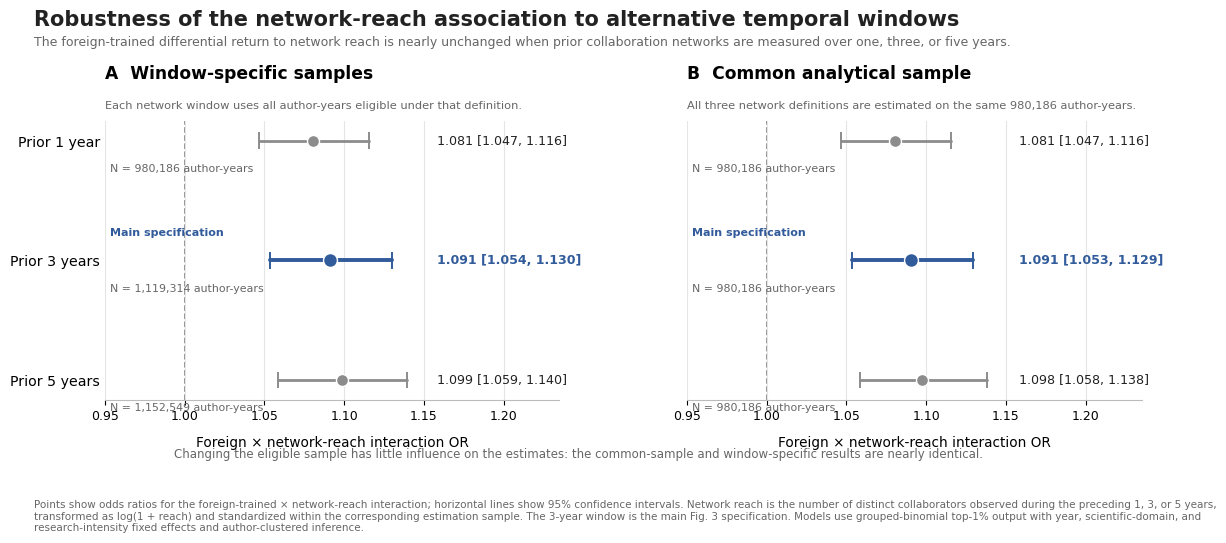

Saved:
figure3_heterogeneity/figure3_network_window_robustness_both_samples.png
figure3_heterogeneity/figure3_network_window_robustness_both_samples.pdf


In [ ]:
# =============================================================================
# SUPPLEMENTARY FIGURE
# ROBUSTNESS TO ALTERNATIVE NETWORK WINDOWS
#
# Panel A — Window-specific analytical samples
# Panel B — Common analytical sample
#
# Points = foreign × network-reach interaction OR
# Lines  = 95% CI
#
# 3-year window = main Figure 3 specification
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================================
# 1. SETTINGS
# =============================================================================

OUTDIR = "figure3_heterogeneity"

INPUT_FILE = os.path.join(
    OUTDIR,
    "figure3_robustness_network_windows_final.csv"
)

PNG_FILE = os.path.join(
    OUTDIR,
    "figure3_network_window_robustness_both_samples.png"
)

PDF_FILE = os.path.join(
    OUTDIR,
    "figure3_network_window_robustness_both_samples.pdf"
)


# =============================================================================
# 2. LOAD
# =============================================================================

df = pd.read_csv(INPUT_FILE)


# =============================================================================
# 3. ORDER WINDOWS
# =============================================================================

WINDOW_ORDER = [
    "Prior 1 year",
    "Prior 3 years",
    "Prior 5 years",
]

df["window"] = pd.Categorical(
    df["window"],
    categories=WINDOW_ORDER,
    ordered=True
)

df = df.sort_values(
    ["analysis_type", "window"]
)


# =============================================================================
# 4. SPLIT PANELS
# =============================================================================

window_specific = (
    df[
        df["analysis_type"] == "Window-specific sample"
    ]
    .sort_values("window")
    .reset_index(drop=True)
)


common = (
    df[
        df["analysis_type"] == "Common sample"
    ]
    .sort_values("window")
    .reset_index(drop=True)
)


# =============================================================================
# 5. COLORS
# =============================================================================

MAIN = "#315B9A"
ALT = "#8C8C8C"

NULL = "#777777"
GRID = "#E5E5E5"

TEXT = "#222222"
SUBTEXT = "#666666"


# =============================================================================
# 6. FIGURE
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.8, 5.7),
    sharex=True,
    sharey=True
)

fig.patch.set_facecolor("white")


# =============================================================================
# 7. PANEL FUNCTION
# =============================================================================

def draw_panel(
    ax,
    data,
    title,
    subtitle,
    show_ylabels=True
):

    # top -> bottom
    y_positions = np.array([
        2,
        1,
        0
    ])

    # -------------------------------------------------------------------------
    # Null
    # -------------------------------------------------------------------------

    ax.axvline(
        1.0,
        linestyle="--",
        linewidth=1.1,
        color=NULL,
        zorder=1
    )


    # -------------------------------------------------------------------------
    # Grid
    # -------------------------------------------------------------------------

    ax.grid(
        axis="x",
        color=GRID,
        linewidth=0.8,
        zorder=0
    )


    # -------------------------------------------------------------------------
    # Estimates
    # -------------------------------------------------------------------------

    for i, row in data.iterrows():

        y = y_positions[i]

        estimate = float(
            row["interaction_or"]
        )

        low = float(
            row["interaction_or_low"]
        )

        high = float(
            row["interaction_or_high"]
        )

        is_main = (
            str(row["window"])
            ==
            "Prior 3 years"
        )

        color = (
            MAIN
            if is_main
            else ALT
        )


        # CI
        ax.plot(
            [low, high],
            [y, y],
            color=color,
            linewidth=2.8 if is_main else 2.0,
            solid_capstyle="round",
            zorder=2
        )


        # CI caps
        ax.plot(
            [low, low],
            [y - 0.06, y + 0.06],
            color=color,
            linewidth=1.4,
            zorder=2
        )

        ax.plot(
            [high, high],
            [y - 0.06, y + 0.06],
            color=color,
            linewidth=1.4,
            zorder=2
        )


        # point
        ax.scatter(
            estimate,
            y,
            s=100 if is_main else 75,
            color=color,
            edgecolor="white",
            linewidth=1.0,
            zorder=4
        )


        # ---------------------------------------------------------------------
        # Estimate label
        # ---------------------------------------------------------------------

        estimate_text = (
            f"{estimate:.3f} "
            f"[{low:.3f}, {high:.3f}]"
        )

        ax.text(
            1.158,
            y,
            estimate_text,
            ha="left",
            va="center",
            fontsize=9.1,
            color=MAIN if is_main else TEXT,
            fontweight="bold" if is_main else "normal"
        )


        # ---------------------------------------------------------------------
        # Sample-size text
        # ---------------------------------------------------------------------

        n = int(
            row["author_years"]
        )

        ax.text(
            0.953,
            y - 0.19,
            f"N = {n:,} author-years",
            ha="left",
            va="top",
            fontsize=7.9,
            color=SUBTEXT
        )


        # ---------------------------------------------------------------------
        # Main specification label
        # ---------------------------------------------------------------------

        if is_main:

            ax.text(
                0.953,
                y + 0.19,
                "Main specification",
                ha="left",
                va="bottom",
                fontsize=8.0,
                fontweight="bold",
                color=MAIN
            )


    # =========================================================================
    # Y AXIS
    # =========================================================================

    ax.set_yticks(
        y_positions
    )

    if show_ylabels:

        ax.set_yticklabels(
            [
                "Prior 1 year",
                "Prior 3 years",
                "Prior 5 years"
            ],
            fontsize=10.2
        )

    else:

        ax.set_yticklabels(
            []
        )


    ax.tick_params(
        axis="y",
        length=0
    )


    # =========================================================================
    # X AXIS
    # =========================================================================

    ax.set_xlim(
        0.95,
        1.235
    )

    ax.set_xticks(
        [
            0.95,
            1.00,
            1.05,
            1.10,
            1.15,
            1.20
        ]
    )

    ax.tick_params(
        axis="x",
        labelsize=9
    )


    ax.set_xlabel(
        "Foreign × network-reach interaction OR",
        fontsize=9.8,
        labelpad=9
    )


    # =========================================================================
    # PANEL TITLE
    # =========================================================================

    ax.set_title(
        title,
        loc="left",
        fontsize=12.3,
        fontweight="bold",
        pad=30
    )


    ax.text(
        0.0,
        1.035,
        subtitle,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8.2,
        color=SUBTEXT
    )


    # =========================================================================
    # SPINES
    # =========================================================================

    for spine in [
        "top",
        "right",
        "left"
    ]:

        ax.spines[
            spine
        ].set_visible(False)


    ax.spines[
        "bottom"
    ].set_color(
        "#BBBBBB"
    )


# =============================================================================
# 8. DRAW PANEL A
# =============================================================================

draw_panel(
    axes[0],
    window_specific,
    "A  Window-specific samples",
    (
        "Each network window uses all author-years eligible "
        "under that definition."
    ),
    show_ylabels=True
)


# =============================================================================
# 9. DRAW PANEL B
# =============================================================================

draw_panel(
    axes[1],
    common,
    "B  Common analytical sample",
    (
        "All three network definitions are estimated on the "
        "same 980,186 author-years."
    ),
    show_ylabels=True
)


# =============================================================================
# 10. FIGURE TITLE
# =============================================================================

fig.text(
    0.075,
    0.955,
    "Robustness of the network-reach association to alternative temporal windows",
    ha="left",
    va="top",
    fontsize=15.0,
    fontweight="bold",
    color=TEXT
)


fig.text(
    0.075,
    0.910,
    (
        "The foreign-trained differential return to network reach is nearly "
        "unchanged when prior collaboration networks are measured over one, "
        "three, or five years."
    ),
    ha="left",
    va="top",
    fontsize=9.0,
    color=SUBTEXT
)


# =============================================================================
# 11. OPTIONAL COMPARISON ANNOTATION
#
# This is useful because it explicitly tells the reader why the second panel
# matters, without cluttering the forest plots.
# =============================================================================

fig.text(
    0.50,
    0.175,
    (
        "Changing the eligible sample has little influence on the estimates: "
        "the common-sample and window-specific results are nearly identical."
    ),
    ha="center",
    va="center",
    fontsize=8.5,
    color=SUBTEXT
)


# =============================================================================
# 12. FOOTNOTE
# =============================================================================

fig.text(
    0.075,
    0.095,
    (
        "Points show odds ratios for the foreign-trained × network-reach "
        "interaction; horizontal lines show 95% confidence intervals. "
        "Network reach is the number of distinct collaborators observed during "
        "the preceding 1, 3, or 5 years, transformed as log(1 + reach) and "
        "standardized within the corresponding estimation sample. "
        "The 3-year window is the main Fig. 3 specification. Models use "
        "grouped-binomial top-1% output with year, scientific-domain, and "
        "research-intensity fixed effects and author-clustered inference."
    ),
    ha="left",
    va="top",
    fontsize=7.5,
    color=SUBTEXT,
    wrap=True
)


# =============================================================================
# 13. LAYOUT
# =============================================================================

plt.subplots_adjust(
    left=0.13,
    right=0.94,
    top=0.76,
    bottom=0.27,
    wspace=0.28
)


# =============================================================================
# 14. SAVE
# =============================================================================

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    PDF_FILE,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


print("Saved:")
print(PNG_FILE)
print(PDF_FILE)

In [ ]:
# =============================================================================
# FIGURE 3 — DISCIPLINARY HETEROGENEITY
#
# Exact Figure 3 Panel B specification, stratified by primary scientific domain.
#
# Exposure:
#   z[log(1 + prior3_degree)]
#
# IMPORTANT:
#   ALL domains use the ORIGINAL Figure 3 Panel B scale:
#
#       mean log reach = 3.231555
#       SD log reach   = 1.328886
#
# This makes interaction ORs directly comparable across domains and to Fig. 3.
#
# Models:
#   grouped-binomial top-1% output
#   reach_z × phd_type
#   year FE
#   research-intensity FE
#   author-clustered sandwich covariance
#
# Domain FE are omitted from domain-stratified models because domain is constant.
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm, chi2

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


# -----------------------------------------------------------------------------
# EXACT ORIGINAL FIGURE 3 SCALE
# -----------------------------------------------------------------------------

FIG3_LOG_REACH_MEAN = 3.231555
FIG3_LOG_REACH_SD = 1.328886


DOMAIN_ORDER = [
    "Applied Sciences",
    "Business and Economics",
    "Education",
    "Engineering",
    "Humanities",
    "Mathematics and Computing",
    "Medicine and Health",
    "Natural Sciences",
    "Social Sciences",
]


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD EXACT PANEL B SAMPLE
# =============================================================================

query = f"""

SELECT

    author_id,
    year,

    phd_type,
    primary_domain,

    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree

FROM `{TABLE}`

WHERE
    panel_b_eligible = 1

    AND year BETWEEN 2011 AND 2020

"""


df = (
    client
    .query(query)
    .to_dataframe()
)


# =============================================================================
# 3. CLEAN
# =============================================================================

numeric_cols = [
    "year",
    "research_intensity_level",
    "papers",
    "top1_papers",
    "prior3_degree",
    "prior3_log_degree",
]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=[
        "author_id",
        "year",
        "phd_type",
        "primary_domain",
        "papers",
        "top1_papers",
        "prior3_log_degree",
    ]
).copy()


df["year"] = (
    df["year"]
    .astype(int)
)


df["phd_type"] = (
    df["phd_type"]
    .astype(str)
    .str.lower()
    .str.strip()
)


df = df[
    df["phd_type"].isin(
        [
            "domestic",
            "foreign",
        ]
    )
].copy()


df["primary_domain"] = (
    df["primary_domain"]
    .astype(str)
    .str.strip()
)


df["year_cat"] = (
    df["year"]
    .astype(str)
)


df["research_cat"] = (
    df["research_intensity_level"]
    .fillna(-999)
    .astype(str)
)


# =============================================================================
# 4. APPLY ORIGINAL FIGURE 3 STANDARDIZATION
# =============================================================================

df["reach_z"] = (

    (
        df["prior3_log_degree"]
        -
        FIG3_LOG_REACH_MEAN
    )

    /
    FIG3_LOG_REACH_SD

)


# =============================================================================
# 5. AUDIT
# =============================================================================

print("=" * 80)
print("FIGURE 3 — DISCIPLINARY HETEROGENEITY")
print("EXACT FIGURE 3 PANEL B SPECIFICATION")
print("=" * 80)

print()

print("Original Figure 3 reach transformation:")
print()
print("  Exposure = z[log(1 + prior-3-year network reach)]")
print()
print(
    f"  Mean log reach = "
    f"{FIG3_LOG_REACH_MEAN:.6f}"
)
print(
    f"  SD log reach   = "
    f"{FIG3_LOG_REACH_SD:.6f}"
)

print()

print("Panel B sample:")
print(
    f"  Author-years: {len(df):,}"
)
print(
    f"  Authors:      {df['author_id'].nunique():,}"
)
print(
    f"  Papers:       {df['papers'].sum():,.0f}"
)
print(
    f"  Top-1%:       {df['top1_papers'].sum():,.0f}"
)

print()


# =============================================================================
# 6. CLUSTERED GLM HELPER
# =============================================================================

def fit_clustered_binomial(
    d,
    rhs_formula
):

    d = d.copy()


    # -------------------------------------------------------------------------
    # Design matrix
    # -------------------------------------------------------------------------

    X_df = dmatrix(
        rhs_formula,
        data=d,
        return_type="dataframe"
    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # -------------------------------------------------------------------------
    # Grouped-binomial outcome
    # -------------------------------------------------------------------------

    successes = (
        d["top1_papers"]
        .to_numpy(dtype=float)
    )


    failures = (
        d["papers"]
        .to_numpy(dtype=float)
        -
        successes
    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # -------------------------------------------------------------------------
    # Fit
    # -------------------------------------------------------------------------

    glm = sm.GLM(
        endog=endog,
        exog=X,
        family=sm.families.Binomial()
    )


    fit = glm.fit()


    # -------------------------------------------------------------------------
    # Clustered covariance
    # -------------------------------------------------------------------------

    score_obs = np.asarray(
        glm.score_obs(
            fit.params
        ),
        dtype=float
    )


    cluster_codes, cluster_labels = pd.factorize(
        d["author_id"].astype(str),
        sort=False
    )


    G = len(cluster_labels)
    N = len(d)
    K = X.shape[1]


    cluster_scores = np.zeros(
        (
            G,
            K,
        ),
        dtype=float
    )


    np.add.at(
        cluster_scores,
        cluster_codes,
        score_obs
    )


    meat = (
        cluster_scores.T
        @
        cluster_scores
    )


    bread = np.asarray(
        fit.normalized_cov_params,
        dtype=float
    )


    cov = (
        bread
        @
        meat
        @
        bread
    )


    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )


        cov *= correction


    se = np.sqrt(
        np.diag(cov)
    )


    return (
        fit,
        X_df,
        cov,
        se,
        N,
        G,
    )


# =============================================================================
# 7. ORIGINAL FIGURE 3 POOLED MODEL
#
# Reproduce the main estimate before stratifying.
# =============================================================================

pooled_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


(
    pooled_fit,
    pooled_X,
    pooled_cov,
    pooled_se,
    pooled_N,
    pooled_G,

) = fit_clustered_binomial(
    df,
    pooled_formula
)


pooled_names = list(
    pooled_X.columns
)


pooled_interaction_candidates = [

    name
    for name in pooled_names

    if (
        "reach_z" in name
        and
        "phd_type" in name
        and
        "foreign" in name
        and
        ":" in name
    )

]


if len(
    pooled_interaction_candidates
) != 1:

    raise ValueError(
        pooled_interaction_candidates
    )


pooled_interaction_term = (
    pooled_interaction_candidates[0]
)


pooled_idx = pooled_names.index(
    pooled_interaction_term
)


pooled_beta = float(
    pooled_fit.params[
        pooled_idx
    ]
)


pooled_beta_se = float(
    pooled_se[
        pooled_idx
    ]
)


pooled_or = np.exp(
    pooled_beta
)


pooled_low = np.exp(
    pooled_beta
    -
    1.96 * pooled_beta_se
)


pooled_high = np.exp(
    pooled_beta
    +
    1.96 * pooled_beta_se
)


pooled_p = 2 * norm.sf(
    abs(
        pooled_beta
        /
        pooled_beta_se
    )
)


print("=" * 80)
print("ORIGINAL FIGURE 3 PANEL B — VALIDATION")
print("=" * 80)

print()

print(
    f"Interaction beta = "
    f"{pooled_beta:.5f}"
)

print(
    f"Author-clustered SE = "
    f"{pooled_beta_se:.5f}"
)

print(
    "Interaction OR = "
    f"{pooled_or:.3f} "
    f"[{pooled_low:.3f}, "
    f"{pooled_high:.3f}]"
)

print(
    f"p = {pooled_p:.6g}"
)

print()


# =============================================================================
# 8. DOMAIN-SPECIFIC MODELS
# =============================================================================

domain_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(research_cat)"

)


results = []


for domain in DOMAIN_ORDER:

    d = df[
        df["primary_domain"]
        ==
        domain
    ].copy()


    if len(d) == 0:
        continue


    print("=" * 80)
    print(domain.upper())
    print("=" * 80)

    print()

    print(
        f"Author-years: "
        f"{len(d):,}"
    )

    print(
        f"Authors:      "
        f"{d['author_id'].nunique():,}"
    )

    print(
        f"Papers:       "
        f"{d['papers'].sum():,.0f}"
    )

    print(
        f"Top-1%:       "
        f"{d['top1_papers'].sum():,.0f}"
    )

    print(
        "Top-1% rate:  "
        f"{d['top1_papers'].sum() / d['papers'].sum():.3%}"
    )

    print()


    # -------------------------------------------------------------------------
    # Foreign sample size
    # -------------------------------------------------------------------------

    foreign_d = d[
        d["phd_type"]
        ==
        "foreign"
    ]


    print(
        "Foreign-trained:"
    )

    print(
        f"  Author-years: "
        f"{len(foreign_d):,}"
    )

    print(
        f"  Authors:      "
        f"{foreign_d['author_id'].nunique():,}"
    )

    print()


    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------

    (
        fit,
        X_df,
        cov,
        cluster_se,
        N,
        G,

    ) = fit_clustered_binomial(
        d,
        domain_formula
    )


    names = list(
        X_df.columns
    )


    interaction_candidates = [

        name
        for name in names

        if (
            "reach_z" in name
            and
            "phd_type" in name
            and
            "foreign" in name
            and
            ":" in name
        )

    ]


    if len(
        interaction_candidates
    ) != 1:

        raise ValueError(
            f"{domain}: "
            f"{interaction_candidates}"
        )


    interaction_term = (
        interaction_candidates[0]
    )


    interaction_idx = names.index(
        interaction_term
    )


    reach_idx = names.index(
        "reach_z"
    )


    beta = float(
        fit.params[
            interaction_idx
        ]
    )


    se = float(
        cluster_se[
            interaction_idx
        ]
    )


    z = beta / se


    p = float(
        2
        *
        norm.sf(
            abs(z)
        )
    )


    low_beta = (
        beta
        -
        1.96 * se
    )


    high_beta = (
        beta
        +
        1.96 * se
    )


    interaction_or = np.exp(
        beta
    )


    interaction_low = np.exp(
        low_beta
    )


    interaction_high = np.exp(
        high_beta
    )


    # -------------------------------------------------------------------------
    # Within-origin reach associations
    # -------------------------------------------------------------------------

    domestic_beta = float(
        fit.params[
            reach_idx
        ]
    )


    foreign_beta = (
        domestic_beta
        +
        beta
    )


    domestic_or = np.exp(
        domestic_beta
    )


    foreign_or = np.exp(
        foreign_beta
    )


    # -------------------------------------------------------------------------
    # Descriptive reach
    # -------------------------------------------------------------------------

    domestic_rows = d[
        d["phd_type"]
        ==
        "domestic"
    ]


    foreign_rows = d[
        d["phd_type"]
        ==
        "foreign"
    ]


    domestic_mean_reach = float(
        domestic_rows[
            "prior3_degree"
        ].mean()
    )


    foreign_mean_reach = float(
        foreign_rows[
            "prior3_degree"
        ].mean()
    )


    domestic_median_reach = float(
        domestic_rows[
            "prior3_degree"
        ].median()
    )


    foreign_median_reach = float(
        foreign_rows[
            "prior3_degree"
        ].median()
    )


    # -------------------------------------------------------------------------
    # Print
    # -------------------------------------------------------------------------

    print(
        "Foreign × network-reach interaction"
    )

    print()

    print(
        f"beta = "
        f"{beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = "
        f"{z:.3f}"
    )

    print(
        f"p = "
        f"{p:.6g}"
    )

    print()

    print(
        "Interaction OR per +1 ORIGINAL "
        "Figure 3 SD log reach = "
        f"{interaction_or:.3f} "
        f"[{interaction_low:.3f}, "
        f"{interaction_high:.3f}]"
    )

    print()

    print(
        "Within-domain reach associations:"
    )

    print(
        f"  U.S.-trained OR:     "
        f"{domestic_or:.3f}"
    )

    print(
        f"  Foreign-trained OR: "
        f"{foreign_or:.3f}"
    )

    print()

    print(
        "Raw network reach:"
    )

    print(
        "  U.S.-trained:     "
        f"{domestic_mean_reach:.1f} "
        f"(median "
        f"{domestic_median_reach:.0f})"
    )

    print(
        "  Foreign-trained: "
        f"{foreign_mean_reach:.1f} "
        f"(median "
        f"{foreign_median_reach:.0f})"
    )

    print()


    results.append({

        "primary_domain":
            domain,

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            interaction_or,

        "interaction_or_low":
            interaction_low,

        "interaction_or_high":
            interaction_high,

        "domestic_reach_or":
            domestic_or,

        "foreign_reach_or":
            foreign_or,

        "domestic_mean_reach":
            domestic_mean_reach,

        "foreign_mean_reach":
            foreign_mean_reach,

        "domestic_median_reach":
            domestic_median_reach,

        "foreign_median_reach":
            foreign_median_reach,

        "author_years":
            N,

        "authors":
            G,

        "foreign_author_years":
            len(
                foreign_d
            ),

        "foreign_authors":
            foreign_d[
                "author_id"
            ].nunique(),

        "papers":
            float(
                d["papers"].sum()
            ),

        "top1_papers":
            float(
                d["top1_papers"].sum()
            ),

        "top1_rate":
            float(
                d["top1_papers"].sum()
                /
                d["papers"].sum()
            ),

    })


# =============================================================================
# 9. DOMAIN RESULTS
# =============================================================================

results_df = pd.DataFrame(
    results
)


print("=" * 100)
print("DISCIPLINARY HETEROGENEITY — DOMAIN-SPECIFIC RESULTS")
print("=" * 100)

print()


display_cols = [

    "primary_domain",

    "interaction_or",
    "interaction_or_low",
    "interaction_or_high",
    "interaction_p",

    "domestic_reach_or",
    "foreign_reach_or",

    "domestic_mean_reach",
    "foreign_mean_reach",

    "author_years",
    "foreign_author_years",

]


print(
    results_df[
        display_cols
    ].to_string(
        index=False
    )
)

print()


# =============================================================================
# 10. FORMAL OMNIBUS HETEROGENEITY TEST
#
# Rather than infer heterogeneity from separate p-values, fit one pooled model:
#
#   reach × phd_type × domain
#
# and jointly test all:
#
#   reach × foreign × domain
#
# coefficients.
#
# The reference domain is Applied Sciences.
# =============================================================================

print("=" * 80)
print("OMNIBUS TEST OF DISCIPLINARY HETEROGENEITY")
print("=" * 80)

print()


omnibus_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') * '

    'C('
    'primary_domain, '
    'Treatment(reference="Applied Sciences")'
    ') + '

    "C(year_cat) + "

    "C(research_cat)"

)


(
    omnibus_fit,
    omnibus_X,
    omnibus_cov,
    omnibus_se,
    omnibus_N,
    omnibus_G,

) = fit_clustered_binomial(
    df,
    omnibus_formula
)


omnibus_names = list(
    omnibus_X.columns
)


# -----------------------------------------------------------------------------
# Identify ONLY three-way interaction coefficients:
#
# reach_z × foreign × domain
# -----------------------------------------------------------------------------

three_way_terms = [

    name

    for name in omnibus_names

    if (
        "reach_z" in name
        and
        "phd_type" in name
        and
        "foreign" in name
        and
        "primary_domain" in name
        and
        name.count(":") == 2
    )

]


print(
    "Three-way interaction terms tested:"
)

for term in three_way_terms:
    print(
        "  ",
        term
    )

print()


if len(
    three_way_terms
) == 0:

    raise ValueError(
        "No three-way interaction terms identified."
    )


idx = np.array(
    [
        omnibus_names.index(
            term
        )
        for term in three_way_terms
    ]
)


b = np.asarray(
    omnibus_fit.params
)[idx]


V = omnibus_cov[
    np.ix_(
        idx,
        idx
    )
]


wald_stat = float(
    b.T
    @
    np.linalg.pinv(V)
    @
    b
)


wald_df = len(
    idx
)


wald_p = float(
    chi2.sf(
        wald_stat,
        wald_df
    )
)


print(
    f"Wald chi-square = "
    f"{wald_stat:.3f}"
)

print(
    f"df = "
    f"{wald_df}"
)

print(
    f"p = "
    f"{wald_p:.6g}"
)

print()


if wald_p < 0.05:

    print(
        "Evidence of heterogeneity: "
        "the foreign × network-reach interaction "
        "differs across scientific domains."
    )

else:

    print(
        "No strong evidence of heterogeneity: "
        "domain-specific variation is compatible "
        "with sampling uncertainty."
    )

print()


# =============================================================================
# 11. ADD POOLED RESULT FOR FIGURE/TABLE
# =============================================================================

pooled_row = pd.DataFrame({

    "primary_domain": [
        "Main Figure 3"
    ],

    "interaction_beta": [
        pooled_beta
    ],

    "interaction_se": [
        pooled_beta_se
    ],

    "interaction_z": [
        pooled_beta
        /
        pooled_beta_se
    ],

    "interaction_p": [
        pooled_p
    ],

    "interaction_or": [
        pooled_or
    ],

    "interaction_or_low": [
        pooled_low
    ],

    "interaction_or_high": [
        pooled_high
    ],

    "domestic_reach_or": [
        np.nan
    ],

    "foreign_reach_or": [
        np.nan
    ],

    "domestic_mean_reach": [
        np.nan
    ],

    "foreign_mean_reach": [
        np.nan
    ],

    "domestic_median_reach": [
        np.nan
    ],

    "foreign_median_reach": [
        np.nan
    ],

    "author_years": [
        pooled_N
    ],

    "authors": [
        pooled_G
    ],

    "foreign_author_years": [
        int(
            (
                df["phd_type"]
                ==
                "foreign"
            ).sum()
        )
    ],

    "foreign_authors": [
        df.loc[
            df["phd_type"]
            ==
            "foreign",
            "author_id"
        ].nunique()
    ],

    "papers": [
        float(
            df["papers"].sum()
        )
    ],

    "top1_papers": [
        float(
            df["top1_papers"].sum()
        )
    ],

    "top1_rate": [
        float(
            df["top1_papers"].sum()
            /
            df["papers"].sum()
        )
    ],

})


final_df = pd.concat(
    [
        pooled_row,
        results_df,
    ],
    ignore_index=True
)


# =============================================================================
# 12. SAVE
# =============================================================================

results_file = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_domain_final.csv"
)


omnibus_file = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_domain_omnibus.csv"
)


final_df.to_csv(
    results_file,
    index=False
)


pd.DataFrame({

    "wald_chi2": [
        wald_stat
    ],

    "df": [
        wald_df
    ],

    "p": [
        wald_p
    ],

    "n_author_years": [
        omnibus_N
    ],

    "n_authors": [
        omnibus_G
    ],

}).to_csv(
    omnibus_file,
    index=False
)


print("=" * 80)
print("SAVED")
print("=" * 80)

print()

print(
    results_file
)

print(
    omnibus_file
)

FIGURE 3 — DISCIPLINARY HETEROGENEITY
EXACT FIGURE 3 PANEL B SPECIFICATION

Original Figure 3 reach transformation:

  Exposure = z[log(1 + prior-3-year network reach)]

  Mean log reach = 3.231555
  SD log reach   = 1.328886

Panel B sample:
  Author-years: 1,119,314
  Authors:      200,348
  Papers:       7,630,784
  Top-1%:       354,194

ORIGINAL FIGURE 3 PANEL B — VALIDATION

Interaction beta = 0.08713
Author-clustered SE = 0.01782
Interaction OR = 1.091 [1.054, 1.130]
p = 1.01676e-06

APPLIED SCIENCES

Author-years: 39,462
Authors:      7,720
Papers:       245,367
Top-1%:       10,061
Top-1% rate:  4.100%

Foreign-trained:
  Author-years: 3,999
  Authors:      779

Foreign × network-reach interaction

beta = 0.12027
author-clustered SE = 0.11747
z = 1.024
p = 0.305904

Interaction OR per +1 ORIGINAL Figure 3 SD log reach = 1.128 [0.896, 1.420]

Within-domain reach associations:
  U.S.-trained OR:     1.447
  Foreign-trained OR: 1.632

Raw network reach:
  U.S.-trained:     67.3 (

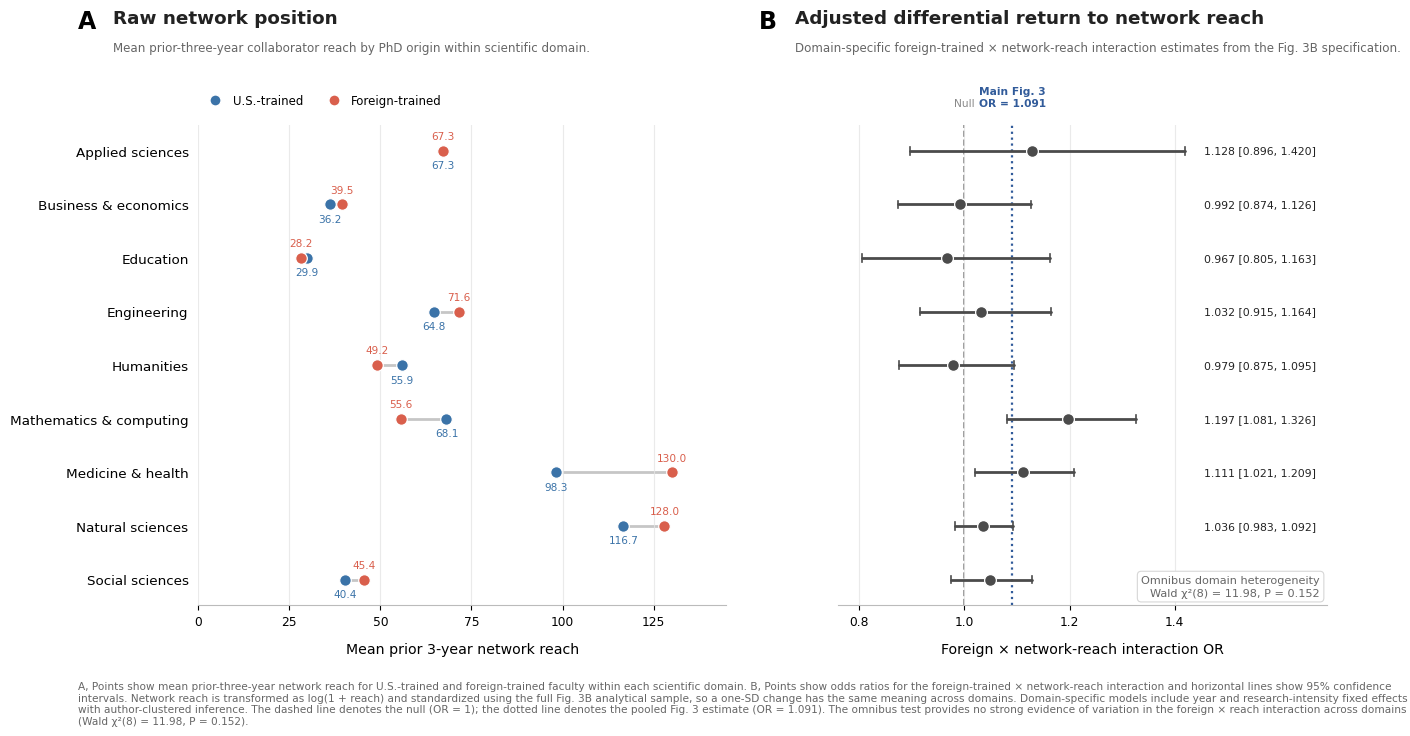

Saved:
figure3_heterogeneity/figure3_disciplinary_heterogeneity_supplement.png
figure3_heterogeneity/figure3_disciplinary_heterogeneity_supplement.pdf


In [ ]:
# =============================================================================
# SUPPLEMENTARY FIGURE
# DISCIPLINARY VARIATION IN NETWORK POSITION AND NETWORK RETURNS
#
# Panel A — RAW NETWORK POSITION
#   Mean prior-3-year network reach by PhD origin within scientific domain
#   Dumbbell plot:
#       U.S.-trained
#       Foreign-trained
#
# Panel B — ADJUSTED DIFFERENTIAL RETURN
#   Foreign × network-reach interaction OR by scientific domain
#   Exact Figure 3 Panel B specification
#
#   Points = OR
#   Lines  = 95% CI
#
#   Dashed vertical line = null OR = 1
#   Dotted vertical line = pooled Figure 3 OR = 1.091
#
#   Omnibus domain heterogeneity:
#       Wald chi-square(8) = 11.979
#       P = 0.152
#
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D


# =============================================================================
# 1. SETTINGS
# =============================================================================

OUTDIR = "figure3_heterogeneity"

RESULT_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_domain_final.csv"
)

OMNIBUS_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_domain_omnibus.csv"
)

PNG_FILE = os.path.join(
    OUTDIR,
    "figure3_disciplinary_heterogeneity_supplement.png"
)

PDF_FILE = os.path.join(
    OUTDIR,
    "figure3_disciplinary_heterogeneity_supplement.pdf"
)


# =============================================================================
# 2. COLORS
# =============================================================================

DOMESTIC = "#3B73A8"
FOREIGN = "#D95F4C"

ADJUSTED = "#4B4B4B"

CONNECTOR = "#C6C6C6"
GRID = "#E5E5E5"

TEXT = "#222222"
SUBTEXT = "#666666"

NULL = "#8A8A8A"
POOLED = "#315B9A"


# =============================================================================
# 3. LOAD
# =============================================================================

results = pd.read_csv(
    RESULT_FILE
)

omnibus = pd.read_csv(
    OMNIBUS_FILE
)


# =============================================================================
# 4. EXTRACT POOLED FIGURE 3 RESULT
# =============================================================================

pooled = results[
    results["primary_domain"]
    ==
    "Main Figure 3"
].iloc[0]


POOLED_OR = float(
    pooled["interaction_or"]
)


# =============================================================================
# 5. KEEP DOMAIN-SPECIFIC RESULTS
# =============================================================================

domain_df = results[
    results["primary_domain"]
    !=
    "Main Figure 3"
].copy()


# =============================================================================
# 6. DOMAIN ORDER
#
# Use a substantive order rather than sorting by effect size.
#
# This avoids visually implying that the domains were selected/ranked based
# on the regression results.
# =============================================================================

DOMAIN_ORDER = [
    "Applied Sciences",
    "Business and Economics",
    "Education",
    "Engineering",
    "Humanities",
    "Mathematics and Computing",
    "Medicine and Health",
    "Natural Sciences",
    "Social Sciences",
]


domain_df["primary_domain"] = pd.Categorical(
    domain_df["primary_domain"],
    categories=DOMAIN_ORDER,
    ordered=True
)


domain_df = (
    domain_df
    .sort_values("primary_domain")
    .reset_index(drop=True)
)


# =============================================================================
# 7. SHORT DISPLAY LABELS
# =============================================================================

DISPLAY_LABELS = {
    "Applied Sciences":
        "Applied sciences",

    "Business and Economics":
        "Business & economics",

    "Education":
        "Education",

    "Engineering":
        "Engineering",

    "Humanities":
        "Humanities",

    "Mathematics and Computing":
        "Mathematics & computing",

    "Medicine and Health":
        "Medicine & health",

    "Natural Sciences":
        "Natural sciences",

    "Social Sciences":
        "Social sciences",
}


domain_df["display_domain"] = (
    domain_df["primary_domain"]
    .astype(str)
    .map(DISPLAY_LABELS)
)


# =============================================================================
# 8. OMNIBUS RESULT
# =============================================================================

wald_chi2 = float(
    omnibus.iloc[0]["wald_chi2"]
)

wald_df = int(
    omnibus.iloc[0]["df"]
)

wald_p = float(
    omnibus.iloc[0]["p"]
)


# =============================================================================
# 9. Y POSITIONS
#
# First domain at top.
# =============================================================================

n_domains = len(
    domain_df
)

y = np.arange(
    n_domains
)[::-1]


# =============================================================================
# 10. FIGURE
# =============================================================================

fig = plt.figure(
    figsize=(14.2, 8.0),
    facecolor="white"
)


gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[
        1.08,
        1.00,
    ],
    left=0.16,
    right=0.955,
    bottom=0.18,
    top=0.78,
    wspace=0.22,
)


ax_a = fig.add_subplot(
    gs[0, 0]
)

ax_b = fig.add_subplot(
    gs[0, 1],
    sharey=ax_a
)


# =============================================================================
# 11. PANEL A
# RAW NETWORK REACH
# =============================================================================

for i, row in domain_df.iterrows():

    yy = y[i]


    domestic = float(
        row["domestic_mean_reach"]
    )

    foreign = float(
        row["foreign_mean_reach"]
    )


    # -------------------------------------------------------------------------
    # Connector
    # -------------------------------------------------------------------------

    ax_a.plot(
        [
            domestic,
            foreign,
        ],
        [
            yy,
            yy,
        ],
        color=CONNECTOR,
        linewidth=2.0,
        zorder=1,
    )


    # -------------------------------------------------------------------------
    # U.S.-trained
    # -------------------------------------------------------------------------

    ax_a.scatter(
        domestic,
        yy,
        s=70,
        color=DOMESTIC,
        edgecolor="white",
        linewidth=0.9,
        zorder=4,
    )


    # -------------------------------------------------------------------------
    # Foreign-trained
    # -------------------------------------------------------------------------

    ax_a.scatter(
        foreign,
        yy,
        s=70,
        color=FOREIGN,
        edgecolor="white",
        linewidth=0.9,
        zorder=4,
    )


    # -------------------------------------------------------------------------
    # VALUE LABELS
    #
    # Important:
    # When the two values are close, placing both labels on the same horizontal
    # line causes overlap.
    #
    # Therefore:
    #   domestic label -> slightly below
    #   foreign label  -> slightly above
    #
    # This works for both close and widely separated values.
    # -------------------------------------------------------------------------

    ax_a.text(
        domestic,
        yy - 0.18,
        f"{domestic:.1f}",
        ha="center",
        va="top",
        fontsize=7.6,
        color=DOMESTIC,
    )


    ax_a.text(
        foreign,
        yy + 0.18,
        f"{foreign:.1f}",
        ha="center",
        va="bottom",
        fontsize=7.6,
        color=FOREIGN,
    )


# =============================================================================
# 12. PANEL A — ZERO / GRID
# =============================================================================

ax_a.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    alpha=0.8,
    zorder=0,
)


# =============================================================================
# 13. PANEL A — AXES
# =============================================================================

ax_a.set_xlim(
    0,
    145
)


ax_a.set_xticks(
    [
        0,
        25,
        50,
        75,
        100,
        125,
    ]
)


ax_a.set_xlabel(
    "Mean prior 3-year network reach",
    fontsize=10.2,
    labelpad=10,
)


ax_a.set_yticks(
    y
)


ax_a.set_yticklabels(
    domain_df[
        "display_domain"
    ],
    fontsize=9.7,
)


ax_a.tick_params(
    axis="y",
    length=0,
    pad=7,
)


ax_a.tick_params(
    axis="x",
    labelsize=8.8,
)


# =============================================================================
# 14. PANEL A — LEGEND
# =============================================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=DOMESTIC,
        markeredgecolor="white",
        markersize=8,
        label="U.S.-trained",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=FOREIGN,
        markeredgecolor="white",
        markersize=8,
        label="Foreign-trained",
    ),

]


ax_a.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(
        0.00,
        1.075,
    ),
    frameon=False,
    fontsize=8.5,
    ncol=2,
    columnspacing=1.6,
    handletextpad=0.5,
    borderaxespad=0,
)


# =============================================================================
# 15. PANEL B
# ADJUSTED FOREIGN × NETWORK-REACH INTERACTION
# =============================================================================

# -----------------------------------------------------------------------------
# Null
# -----------------------------------------------------------------------------

ax_b.axvline(
    1.0,
    color=NULL,
    linestyle="--",
    linewidth=1.2,
    zorder=1,
)


# -----------------------------------------------------------------------------
# Pooled Figure 3 estimate
# -----------------------------------------------------------------------------

ax_b.axvline(
    POOLED_OR,
    color=POOLED,
    linestyle=":",
    linewidth=1.6,
    zorder=1,
)


# =============================================================================
# 16. PANEL B — DOMAIN ESTIMATES
# =============================================================================

for i, row in domain_df.iterrows():

    yy = y[i]


    estimate = float(
        row["interaction_or"]
    )

    low = float(
        row["interaction_or_low"]
    )

    high = float(
        row["interaction_or_high"]
    )


    # -------------------------------------------------------------------------
    # CI
    # -------------------------------------------------------------------------

    ax_b.plot(
        [
            low,
            high,
        ],
        [
            yy,
            yy,
        ],
        color=ADJUSTED,
        linewidth=2.0,
        solid_capstyle="round",
        zorder=2,
    )


    # -------------------------------------------------------------------------
    # CI caps
    # -------------------------------------------------------------------------

    ax_b.plot(
        [
            low,
            low,
        ],
        [
            yy - 0.07,
            yy + 0.07,
        ],
        color=ADJUSTED,
        linewidth=1.2,
        zorder=2,
    )


    ax_b.plot(
        [
            high,
            high,
        ],
        [
            yy - 0.07,
            yy + 0.07,
        ],
        color=ADJUSTED,
        linewidth=1.2,
        zorder=2,
    )


    # -------------------------------------------------------------------------
    # Point
    # -------------------------------------------------------------------------

    ax_b.scatter(
        estimate,
        yy,
        s=72,
        color=ADJUSTED,
        edgecolor="white",
        linewidth=0.9,
        zorder=4,
    )


    # -------------------------------------------------------------------------
    # Estimate label
    #
    # Place all labels in a fixed right-hand column.
    # This is much cleaner than attaching them directly to the CI endpoint.
    # -------------------------------------------------------------------------

    ax_b.text(
        1.455,
        yy,
        (
            f"{estimate:.3f} "
            f"[{low:.3f}, {high:.3f}]"
        ),
        ha="left",
        va="center",
        fontsize=7.8,
        color=TEXT,
    )


# =============================================================================
# 17. PANEL B — GRID / AXIS
# =============================================================================

ax_b.grid(
    axis="x",
    color=GRID,
    linewidth=0.8,
    alpha=0.8,
    zorder=0,
)


ax_b.set_xlim(
    0.76,
    1.69
)


ax_b.set_xticks(
    [
        0.8,
        1.0,
        1.2,
        1.4,
    ]
)


ax_b.set_xlabel(
    "Foreign × network-reach interaction OR",
    fontsize=10.2,
    labelpad=10,
)


ax_b.tick_params(
    axis="x",
    labelsize=8.8,
)


# shared y-axis: do not repeat domain labels

ax_b.tick_params(
    axis="y",
    left=False,
    labelleft=False,
)


# =============================================================================
# 18. PANEL B — REFERENCE LABELS
# =============================================================================

# Put these above the plotting area, not inside the data rows.

ax_b.text(
    1.0,
    n_domains - 0.20,
    "Null",
    ha="center",
    va="bottom",
    fontsize=7.7,
    color=NULL,
)


ax_b.text(
    POOLED_OR,
    n_domains - 0.20,
    f"Main Fig. 3\nOR = {POOLED_OR:.3f}",
    ha="center",
    va="bottom",
    fontsize=7.7,
    color=POOLED,
    fontweight="bold",
)


# =============================================================================
# 19. OMNIBUS TEST BOX
#
# Put it in the bottom-right empty region rather than over the estimates.
# =============================================================================

omnibus_text = (
    "Omnibus domain heterogeneity\n"
    f"Wald χ²({wald_df}) = {wald_chi2:.2f}, "
    f"P = {wald_p:.3f}"
)


ax_b.text(
    0.985,
    0.015,
    omnibus_text,
    transform=ax_b.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.1,
    color=SUBTEXT,
    linespacing=1.35,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#D7D7D7",
        linewidth=0.8,
    ),
)


# =============================================================================
# 20. SPINES
# =============================================================================

for ax in [
    ax_a,
    ax_b,
]:

    for spine in [
        "top",
        "right",
        "left",
    ]:

        ax.spines[
            spine
        ].set_visible(False)


    ax.spines[
        "bottom"
    ].set_color(
        "#BBBBBB"
    )


# =============================================================================
# 21. PANEL HEADERS
# =============================================================================

fig.text(
    0.075,
    0.925,
    "A",
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
)


fig.text(
    0.100,
    0.925,
    "Raw network position",
    fontsize=13.2,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="top",
)


fig.text(
    0.100,
    0.885,
    (
        "Mean prior-three-year collaborator reach "
        "by PhD origin within scientific domain."
    ),
    fontsize=8.6,
    color=SUBTEXT,
    ha="left",
    va="top",
)


fig.text(
    0.555,
    0.925,
    "B",
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
)


fig.text(
    0.580,
    0.925,
    "Adjusted differential return to network reach",
    fontsize=13.2,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="top",
)


fig.text(
    0.580,
    0.885,
    (
        "Domain-specific foreign-trained × network-reach "
        "interaction estimates from the Fig. 3B specification."
    ),
    fontsize=8.6,
    color=SUBTEXT,
    ha="left",
    va="top",
)


# =============================================================================
# 22. BOTTOM NOTE
# =============================================================================

fig.text(
    0.075,
    0.085,
    (
        "A, Points show mean prior-three-year network reach for U.S.-trained "
        "and foreign-trained faculty within each scientific domain. "
        "B, Points show odds ratios for the foreign-trained × network-reach "
        "interaction and horizontal lines show 95% confidence intervals. "
        "Network reach is transformed as log(1 + reach) and standardized using "
        "the full Fig. 3B analytical sample, so a one-SD change has the same "
        "meaning across domains. Domain-specific models include year and "
        "research-intensity fixed effects with author-clustered inference. "
        "The dashed line denotes the null (OR = 1); the dotted line denotes "
        f"the pooled Fig. 3 estimate (OR = {POOLED_OR:.3f}). "
        f"The omnibus test provides no strong evidence of variation in the "
        f"foreign × reach interaction across domains "
        f"(Wald χ²({wald_df}) = {wald_chi2:.2f}, P = {wald_p:.3f})."
    ),
    fontsize=7.6,
    color=SUBTEXT,
    ha="left",
    va="top",
    wrap=True,
)


# =============================================================================
# 23. SAVE
# =============================================================================

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


fig.savefig(
    PDF_FILE,
    bbox_inches="tight",
    facecolor="white",
)


plt.show()


print("Saved:")
print(PNG_FILE)
print(PDF_FILE)

In [ ]:
# =============================================================================
# FIGURE 3 — PHD-COUNTRY HETEROGENEITY
#
# PURPOSE
#
# Test whether the differential association between network reach and elite
# output among foreign-trained faculty is concentrated in particular major
# PhD-training systems.
#
# COUNTRIES
#
# Top 12 foreign PhD countries with >= 500 faculty authors:
#
#   United Kingdom
#   Canada
#   Germany
#   China
#   India
#   Russia
#   France
#   Japan
#   Italy
#   Australia
#   Israel
#   Switzerland
#
# COUNTRY-SPECIFIC MODELS
#
# For each country:
#
#   U.S.-trained faculty
#       versus
#   foreign-trained faculty whose PhD country == focal country
#
# Model:
#
#   top-1% output ~
#       reach_z × training_group
#       + year FE
#       + domain FE
#       + research-intensity FE
#
# Exposure:
#
#   z[log(1 + prior3_degree)]
#
# IMPORTANT:
#
# Every model uses the ORIGINAL Figure 3 Panel B reach scale:
#
#   mean log reach = 3.231555
#   SD log reach   = 1.328886
#
# This makes country-specific interaction ORs directly comparable with one
# another and with the main Figure 3 result.
#
# Inference:
#
#   grouped-binomial GLM
#   author-clustered sandwich covariance
#
# No productivity control.
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm, chi2

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


# -----------------------------------------------------------------------------
# Exact original Figure 3 reach scale
# -----------------------------------------------------------------------------

FIG3_LOG_REACH_MEAN = 3.231555
FIG3_LOG_REACH_SD = 1.328886


# -----------------------------------------------------------------------------
# Countries selected from diagnostic
# -----------------------------------------------------------------------------

COUNTRIES = [

    "United Kingdom",
    "Canada",
    "Germany",
    "China",
    "India",
    "Russia",
    "France",
    "Japan",
    "Italy",
    "Australia",
    "Israel",
    "Switzerland",

]


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD EXACT FIGURE 3 PANEL B SAMPLE
# =============================================================================

query = f"""

SELECT

    author_id,
    year,

    phd_type,
    phd_country,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree

FROM `{TABLE}`

WHERE
    panel_b_eligible = 1

    AND year BETWEEN 2011 AND 2020

"""


df = (
    client
    .query(query)
    .to_dataframe()
)


# =============================================================================
# 3. CLEAN
# =============================================================================

numeric_cols = [

    "year",

    "research_intensity_level",

    "papers",
    "top1_papers",

    "prior3_degree",
    "prior3_log_degree",

]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=[

        "author_id",
        "year",
        "phd_type",

        "primary_domain",

        "papers",
        "top1_papers",

        "prior3_degree",
        "prior3_log_degree",

    ]
).copy()


df["year"] = (
    df["year"]
    .astype(int)
)


df["phd_type"] = (

    df["phd_type"]

    .astype(str)

    .str.lower()

    .str.strip()

)


df = df[
    df["phd_type"].isin(
        [
            "domestic",
            "foreign",
        ]
    )
].copy()


df["phd_country"] = (

    df["phd_country"]

    .fillna("Unknown")

    .astype(str)

    .str.strip()

)


df["primary_domain"] = (

    df["primary_domain"]

    .fillna("Unknown")

    .astype(str)

)


df["year_cat"] = (
    df["year"]
    .astype(str)
)


df["research_cat"] = (

    df["research_intensity_level"]

    .fillna(-999)

    .astype(str)

)


# =============================================================================
# 4. ORIGINAL FIGURE 3 STANDARDIZATION
# =============================================================================

df["reach_z"] = (

    (
        df["prior3_log_degree"]
        -
        FIG3_LOG_REACH_MEAN
    )

    /
    FIG3_LOG_REACH_SD

)


# =============================================================================
# 5. AUDIT
# =============================================================================

print("=" * 80)

print(
    "FIGURE 3 — PHD-COUNTRY HETEROGENEITY"
)

print(
    "EXACT FIGURE 3 PANEL B SPECIFICATION"
)

print("=" * 80)

print()


print(
    "Original Figure 3 reach transformation:"
)

print()

print(
    "Exposure = "
    "z[log(1 + prior-3-year network reach)]"
)

print()

print(
    f"Mean log reach = "
    f"{FIG3_LOG_REACH_MEAN:.6f}"
)

print(
    f"SD log reach   = "
    f"{FIG3_LOG_REACH_SD:.6f}"
)

print()


print(
    "Full Figure 3 Panel B sample:"
)

print(
    f"  Author-years: "
    f"{len(df):,}"
)

print(
    f"  Authors:      "
    f"{df['author_id'].nunique():,}"
)

print(
    f"  Papers:       "
    f"{df['papers'].sum():,.0f}"
)

print(
    f"  Top-1%:       "
    f"{df['top1_papers'].sum():,.0f}"
)

print()


# =============================================================================
# 6. CLUSTERED GROUPED-BINOMIAL HELPER
# =============================================================================

def fit_clustered_binomial(
    d,
    rhs_formula
):

    d = d.copy()


    # -------------------------------------------------------------------------
    # Design matrix
    # -------------------------------------------------------------------------

    X_df = dmatrix(

        rhs_formula,

        data=d,

        return_type="dataframe"

    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # -------------------------------------------------------------------------
    # Grouped-binomial outcome
    # -------------------------------------------------------------------------

    successes = (

        d["top1_papers"]

        .to_numpy(
            dtype=float
        )

    )


    failures = (

        d["papers"]

        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------

    glm = sm.GLM(

        endog=endog,

        exog=X,

        family=sm.families.Binomial()

    )


    fit = glm.fit()


    # -------------------------------------------------------------------------
    # Author-clustered sandwich covariance
    # -------------------------------------------------------------------------

    score_obs = np.asarray(

        glm.score_obs(
            fit.params
        ),

        dtype=float

    )


    cluster_codes, cluster_labels = (

        pd.factorize(

            d[
                "author_id"
            ].astype(str),

            sort=False

        )

    )


    G = len(
        cluster_labels
    )

    N = len(d)

    K = X.shape[1]


    cluster_scores = np.zeros(

        (
            G,
            K,
        ),

        dtype=float

    )


    np.add.at(

        cluster_scores,

        cluster_codes,

        score_obs

    )


    meat = (

        cluster_scores.T

        @

        cluster_scores

    )


    bread = np.asarray(

        fit.normalized_cov_params,

        dtype=float

    )


    cov = (

        bread

        @

        meat

        @

        bread

    )


    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )


        cov *= correction


    cluster_se = np.sqrt(

        np.diag(
            cov
        )

    )


    return (
        fit,
        X_df,
        cov,
        cluster_se,
        N,
        G,
    )


# =============================================================================
# 7. VALIDATE ORIGINAL FIGURE 3 PANEL B
# =============================================================================

pooled_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


(
    pooled_fit,
    pooled_X,
    pooled_cov,
    pooled_se,
    pooled_N,
    pooled_G,

) = fit_clustered_binomial(

    df,

    pooled_formula

)


pooled_names = list(
    pooled_X.columns
)


pooled_interaction_candidates = [

    name

    for name in pooled_names

    if (

        "reach_z" in name

        and

        "phd_type" in name

        and

        "foreign" in name

        and

        ":" in name

    )

]


if len(
    pooled_interaction_candidates
) != 1:

    raise ValueError(
        pooled_interaction_candidates
    )


pooled_interaction_term = (
    pooled_interaction_candidates[0]
)


pooled_idx = (
    pooled_names.index(
        pooled_interaction_term
    )
)


pooled_reach_idx = (
    pooled_names.index(
        "reach_z"
    )
)


pooled_beta = float(
    pooled_fit.params[
        pooled_idx
    ]
)


pooled_beta_se = float(
    pooled_se[
        pooled_idx
    ]
)


pooled_z = (
    pooled_beta
    /
    pooled_beta_se
)


pooled_p = float(

    2
    *
    norm.sf(
        abs(
            pooled_z
        )
    )

)


pooled_low_beta = (
    pooled_beta
    -
    1.96 * pooled_beta_se
)


pooled_high_beta = (
    pooled_beta
    +
    1.96 * pooled_beta_se
)


pooled_or = np.exp(
    pooled_beta
)


pooled_low = np.exp(
    pooled_low_beta
)


pooled_high = np.exp(
    pooled_high_beta
)


pooled_domestic_or = np.exp(

    float(
        pooled_fit.params[
            pooled_reach_idx
        ]
    )

)


pooled_foreign_or = np.exp(

    float(
        pooled_fit.params[
            pooled_reach_idx
        ]
    )

    +

    pooled_beta

)


print("=" * 80)

print(
    "ORIGINAL FIGURE 3 PANEL B — VALIDATION"
)

print("=" * 80)

print()


print(
    f"Interaction beta = "
    f"{pooled_beta:.5f}"
)

print(
    f"Author-clustered SE = "
    f"{pooled_beta_se:.5f}"
)

print(
    f"z = "
    f"{pooled_z:.3f}"
)

print(
    f"p = "
    f"{pooled_p:.6g}"
)

print()


print(
    "Interaction OR = "
    f"{pooled_or:.3f} "
    f"[{pooled_low:.3f}, "
    f"{pooled_high:.3f}]"
)

print()


# =============================================================================
# 8. COUNTRY-SPECIFIC MODELS
# =============================================================================

country_formula = (

    "reach_z * "

    'C('
    'training_group, '
    'Treatment(reference="U.S.-trained")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


results = []


for country in COUNTRIES:

    # =========================================================================
    # COUNTRY-SPECIFIC SAMPLE
    #
    # Keep:
    #
    #   all U.S.-trained author-years
    #
    #   +
    #
    #   foreign-trained author-years from this country only
    # =========================================================================

    d = df[

        (
            df["phd_type"]
            ==
            "domestic"
        )

        |

        (

            (
                df["phd_type"]
                ==
                "foreign"
            )

            &

            (
                df["phd_country"]
                ==
                country
            )

        )

    ].copy()


    # -------------------------------------------------------------------------
    # Training group
    # -------------------------------------------------------------------------

    d["training_group"] = np.where(

        d["phd_type"]
        ==
        "domestic",

        "U.S.-trained",

        country

    )


    # -------------------------------------------------------------------------
    # Audit
    # -------------------------------------------------------------------------

    foreign_d = d[
        d["training_group"]
        ==
        country
    ]


    domestic_d = d[
        d["training_group"]
        ==
        "U.S.-trained"
    ]


    print("=" * 80)

    print(
        country.upper()
    )

    print("=" * 80)

    print()


    print(
        f"Total author-years: "
        f"{len(d):,}"
    )

    print(
        f"Total authors:      "
        f"{d['author_id'].nunique():,}"
    )

    print()


    print(
        f"{country}:"
    )

    print(
        f"  Author-years: "
        f"{len(foreign_d):,}"
    )

    print(
        f"  Authors:      "
        f"{foreign_d['author_id'].nunique():,}"
    )

    print(
        f"  Papers:       "
        f"{foreign_d['papers'].sum():,.0f}"
    )

    print(
        f"  Top-1%:       "
        f"{foreign_d['top1_papers'].sum():,.0f}"
    )

    print(
        "  Top-1% rate:  "
        f"{foreign_d['top1_papers'].sum() / foreign_d['papers'].sum():.3%}"
    )

    print()


    # =========================================================================
    # MODEL
    # =========================================================================

    (
        fit,
        X_df,
        cov,
        cluster_se,
        N,
        G,

    ) = fit_clustered_binomial(

        d,

        country_formula

    )


    names = list(
        X_df.columns
    )


    # -------------------------------------------------------------------------
    # Interaction
    # -------------------------------------------------------------------------

    interaction_candidates = [

        name

        for name in names

        if (

            "reach_z" in name

            and

            "training_group" in name

            and

            country in name

            and

            ":" in name

        )

    ]


    if len(
        interaction_candidates
    ) != 1:

        raise ValueError(

            f"{country}: "
            f"could not identify interaction.\n"
            f"{interaction_candidates}"

        )


    interaction_term = (
        interaction_candidates[0]
    )


    interaction_idx = (
        names.index(
            interaction_term
        )
    )


    reach_idx = (
        names.index(
            "reach_z"
        )
    )


    # -------------------------------------------------------------------------
    # Coefficient
    # -------------------------------------------------------------------------

    beta = float(
        fit.params[
            interaction_idx
        ]
    )


    se = float(
        cluster_se[
            interaction_idx
        ]
    )


    z = (
        beta
        /
        se
    )


    p = float(

        2
        *
        norm.sf(
            abs(z)
        )

    )


    low_beta = (
        beta
        -
        1.96 * se
    )


    high_beta = (
        beta
        +
        1.96 * se
    )


    interaction_or = np.exp(
        beta
    )


    interaction_low = np.exp(
        low_beta
    )


    interaction_high = np.exp(
        high_beta
    )


    # =========================================================================
    # WITHIN-GROUP NETWORK-REACH ASSOCIATIONS
    # =========================================================================

    domestic_beta = float(
        fit.params[
            reach_idx
        ]
    )


    country_beta = (
        domestic_beta
        +
        beta
    )


    domestic_reach_or = np.exp(
        domestic_beta
    )


    country_reach_or = np.exp(
        country_beta
    )


    # =========================================================================
    # RAW DESCRIPTIVES
    # =========================================================================

    domestic_mean_reach = float(
        domestic_d[
            "prior3_degree"
        ].mean()
    )


    domestic_median_reach = float(
        domestic_d[
            "prior3_degree"
        ].median()
    )


    country_mean_reach = float(
        foreign_d[
            "prior3_degree"
        ].mean()
    )


    country_median_reach = float(
        foreign_d[
            "prior3_degree"
        ].median()
    )


    # =========================================================================
    # PRINT
    # =========================================================================

    print(
        "Foreign-country × network-reach interaction"
    )

    print()


    print(
        f"beta = "
        f"{beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = "
        f"{z:.3f}"
    )

    print(
        f"p = "
        f"{p:.6g}"
    )

    print()


    print(
        "Interaction OR per +1 ORIGINAL "
        "Figure 3 SD log network reach = "
        f"{interaction_or:.3f} "
        f"[{interaction_low:.3f}, "
        f"{interaction_high:.3f}]"
    )

    print()


    print(
        "Within-group reach associations:"
    )

    print(
        f"  U.S.-trained OR: "
        f"{domestic_reach_or:.3f}"
    )

    print(
        f"  {country} OR: "
        f"{country_reach_or:.3f}"
    )

    print()


    print(
        "Raw network reach:"
    )

    print(
        f"  U.S.-trained: "
        f"{domestic_mean_reach:.1f} "
        f"(median "
        f"{domestic_median_reach:.0f})"
    )

    print(
        f"  {country}: "
        f"{country_mean_reach:.1f} "
        f"(median "
        f"{country_median_reach:.0f})"
    )

    print()


    # =========================================================================
    # STORE
    # =========================================================================

    results.append({

        "phd_country":
            country,

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            interaction_or,

        "interaction_or_low":
            interaction_low,

        "interaction_or_high":
            interaction_high,

        "domestic_reach_or":
            domestic_reach_or,

        "country_reach_or":
            country_reach_or,

        "domestic_mean_reach":
            domestic_mean_reach,

        "country_mean_reach":
            country_mean_reach,

        "domestic_median_reach":
            domestic_median_reach,

        "country_median_reach":
            country_median_reach,

        "country_author_years":
            len(
                foreign_d
            ),

        "country_authors":
            foreign_d[
                "author_id"
            ].nunique(),

        "country_papers":
            float(
                foreign_d[
                    "papers"
                ].sum()
            ),

        "country_top1_papers":
            float(
                foreign_d[
                    "top1_papers"
                ].sum()
            ),

        "country_top1_rate":
            float(

                foreign_d[
                    "top1_papers"
                ].sum()

                /

                foreign_d[
                    "papers"
                ].sum()

            ),

        "model_author_years":
            N,

        "model_authors":
            G,

    })


# =============================================================================
# 9. COUNTRY-SPECIFIC RESULTS
# =============================================================================

results_df = pd.DataFrame(
    results
)


print("=" * 110)

print(
    "PHD-COUNTRY HETEROGENEITY — COUNTRY-SPECIFIC RESULTS"
)

print("=" * 110)

print()


display_cols = [

    "phd_country",

    "interaction_or",
    "interaction_or_low",
    "interaction_or_high",
    "interaction_p",

    "domestic_reach_or",
    "country_reach_or",

    "domestic_mean_reach",
    "country_mean_reach",

    "country_author_years",
    "country_authors",

]


print(

    results_df[
        display_cols
    ]

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 10. OMNIBUS COUNTRY-HETEROGENEITY TEST
#
# IMPORTANT DESIGN:
#
# This model is estimated among:
#
#   U.S.-trained faculty
#   +
#   faculty from the selected 12 foreign PhD systems.
#
# The model treats training system as a categorical variable and estimates:
#
#   reach_z × training_system
#
# We then test whether the TWELVE country-specific reach interactions are
# equal to one another.
#
# This is NOT a test that all country interactions equal zero.
#
# Instead, we construct contrasts:
#
#   UK interaction - Canada interaction = 0
#   UK interaction - Germany interaction = 0
#   ...
#
# yielding 11 df.
#
# That directly answers:
#
#   Do differential network returns vary across the 12 foreign PhD systems?
# =============================================================================

print("=" * 80)

print(
    "OMNIBUS TEST OF COUNTRY HETEROGENEITY"
)

print("=" * 80)

print()


omnibus_df = df[

    (
        df["phd_type"]
        ==
        "domestic"
    )

    |

    (

        (
            df["phd_type"]
            ==
            "foreign"
        )

        &

        (
            df["phd_country"]
            .isin(
                COUNTRIES
            )
        )

    )

].copy()


omnibus_df["training_system"] = np.where(

    omnibus_df["phd_type"]
    ==
    "domestic",

    "U.S.-trained",

    omnibus_df["phd_country"]

)


# -----------------------------------------------------------------------------
# Explicit categorical ordering
# -----------------------------------------------------------------------------

training_categories = [

    "U.S.-trained",

] + COUNTRIES


omnibus_df["training_system"] = pd.Categorical(

    omnibus_df["training_system"],

    categories=training_categories,

    ordered=False

)


# -----------------------------------------------------------------------------
# Formula
# -----------------------------------------------------------------------------

omnibus_formula = (

    "reach_z * "

    'C('
    'training_system, '
    'Treatment(reference="U.S.-trained")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


(
    omnibus_fit,
    omnibus_X,
    omnibus_cov,
    omnibus_se,
    omnibus_N,
    omnibus_G,

) = fit_clustered_binomial(

    omnibus_df,

    omnibus_formula

)


omnibus_names = list(
    omnibus_X.columns
)


# =============================================================================
# 11. IDENTIFY COUNTRY-SPECIFIC REACH INTERACTIONS
# =============================================================================

country_interaction_indices = {}
country_interaction_terms = {}


for country in COUNTRIES:

    candidates = [

        name

        for name in omnibus_names

        if (

            "reach_z" in name

            and

            "training_system" in name

            and

            country in name

            and

            ":" in name

        )

    ]


    if len(
        candidates
    ) != 1:

        raise ValueError(

            f"Could not identify omnibus "
            f"interaction for {country}.\n"

            f"{candidates}"

        )


    term = candidates[0]


    country_interaction_terms[
        country
    ] = term


    country_interaction_indices[
        country
    ] = omnibus_names.index(
        term
    )


print(
    "Country interaction terms:"
)

print()


for country in COUNTRIES:

    print(
        f"  {country}: "
        f"{country_interaction_terms[country]}"
    )


print()


# =============================================================================
# 12. WALD TEST:
# COUNTRY INTERACTIONS EQUAL ONE ANOTHER
#
# Reference foreign country = United Kingdom
#
# H0:
#
#   beta_Canada      - beta_UK = 0
#   beta_Germany     - beta_UK = 0
#   ...
#   beta_Switzerland - beta_UK = 0
#
# 11 restrictions
# =============================================================================

reference_country = (
    "United Kingdom"
)


ref_idx = (
    country_interaction_indices[
        reference_country
    ]
)


K = len(
    omnibus_names
)


R_rows = []


for country in COUNTRIES:

    if country == reference_country:
        continue


    row = np.zeros(
        K,
        dtype=float
    )


    row[
        country_interaction_indices[
            country
        ]
    ] = 1.0


    row[
        ref_idx
    ] = -1.0


    R_rows.append(
        row
    )


R = np.vstack(
    R_rows
)


params = np.asarray(
    omnibus_fit.params,
    dtype=float
)


Rb = (
    R
    @
    params
)


RVRT = (

    R

    @

    omnibus_cov

    @

    R.T

)


wald_stat = float(

    Rb.T

    @

    np.linalg.pinv(
        RVRT
    )

    @

    Rb

)


wald_df = int(
    R.shape[0]
)


wald_p = float(

    chi2.sf(
        wald_stat,
        wald_df
    )

)


print(
    f"Wald chi-square = "
    f"{wald_stat:.3f}"
)

print(
    f"df = "
    f"{wald_df}"
)

print(
    f"p = "
    f"{wald_p:.6g}"
)

print()


if wald_p < 0.05:

    print(
        "Evidence of heterogeneity: "
        "the differential return to network reach "
        "varies across major foreign PhD systems."
    )

else:

    print(
        "No strong evidence of heterogeneity: "
        "country-specific differences in the network-reach "
        "interaction are compatible with sampling uncertainty."
    )

print()


# =============================================================================
# 13. SECONDARY OMNIBUS TEST
#
# Are all 12 country-specific interactions jointly zero?
#
# This is NOT the primary heterogeneity test, but it is useful descriptively.
# =============================================================================

interaction_idx_array = np.array(

    [

        country_interaction_indices[
            country
        ]

        for country in COUNTRIES

    ]

)


b_joint = params[
    interaction_idx_array
]


V_joint = omnibus_cov[
    np.ix_(
        interaction_idx_array,
        interaction_idx_array
    )
]


joint_zero_stat = float(

    b_joint.T

    @

    np.linalg.pinv(
        V_joint
    )

    @

    b_joint

)


joint_zero_df = len(
    COUNTRIES
)


joint_zero_p = float(

    chi2.sf(
        joint_zero_stat,
        joint_zero_df
    )

)


print(
    "Joint test that all 12 "
    "country-specific interactions = 0"
)

print(
    f"Wald chi-square = "
    f"{joint_zero_stat:.3f}"
)

print(
    f"df = "
    f"{joint_zero_df}"
)

print(
    f"p = "
    f"{joint_zero_p:.6g}"
)

print()


# =============================================================================
# 14. ADD MAIN FIGURE 3 ROW
# =============================================================================

pooled_row = pd.DataFrame({

    "phd_country": [
        "Main Figure 3"
    ],

    "interaction_beta": [
        pooled_beta
    ],

    "interaction_se": [
        pooled_beta_se
    ],

    "interaction_z": [
        pooled_z
    ],

    "interaction_p": [
        pooled_p
    ],

    "interaction_or": [
        pooled_or
    ],

    "interaction_or_low": [
        pooled_low
    ],

    "interaction_or_high": [
        pooled_high
    ],

    "domestic_reach_or": [
        pooled_domestic_or
    ],

    "country_reach_or": [
        pooled_foreign_or
    ],

    "domestic_mean_reach": [
        float(
            df.loc[
                df["phd_type"]
                ==
                "domestic",
                "prior3_degree"
            ].mean()
        )
    ],

    "country_mean_reach": [
        float(
            df.loc[
                df["phd_type"]
                ==
                "foreign",
                "prior3_degree"
            ].mean()
        )
    ],

    "domestic_median_reach": [
        float(
            df.loc[
                df["phd_type"]
                ==
                "domestic",
                "prior3_degree"
            ].median()
        )
    ],

    "country_median_reach": [
        float(
            df.loc[
                df["phd_type"]
                ==
                "foreign",
                "prior3_degree"
            ].median()
        )
    ],

    "country_author_years": [
        int(
            (
                df["phd_type"]
                ==
                "foreign"
            ).sum()
        )
    ],

    "country_authors": [
        df.loc[
            df["phd_type"]
            ==
            "foreign",
            "author_id"
        ].nunique()
    ],

    "country_papers": [
        float(
            df.loc[
                df["phd_type"]
                ==
                "foreign",
                "papers"
            ].sum()
        )
    ],

    "country_top1_papers": [
        float(
            df.loc[
                df["phd_type"]
                ==
                "foreign",
                "top1_papers"
            ].sum()
        )
    ],

    "country_top1_rate": [
        float(

            df.loc[
                df["phd_type"]
                ==
                "foreign",
                "top1_papers"
            ].sum()

            /

            df.loc[
                df["phd_type"]
                ==
                "foreign",
                "papers"
            ].sum()

        )
    ],

    "model_author_years": [
        pooled_N
    ],

    "model_authors": [
        pooled_G
    ],

})


final_df = pd.concat(

    [
        pooled_row,
        results_df,
    ],

    ignore_index=True

)


# =============================================================================
# 15. SAVE
# =============================================================================

results_file = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_country_final.csv"

)


omnibus_file = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_country_omnibus.csv"

)


final_df.to_csv(
    results_file,
    index=False
)


pd.DataFrame({

    "heterogeneity_wald_chi2": [
        wald_stat
    ],

    "heterogeneity_df": [
        wald_df
    ],

    "heterogeneity_p": [
        wald_p
    ],

    "joint_zero_wald_chi2": [
        joint_zero_stat
    ],

    "joint_zero_df": [
        joint_zero_df
    ],

    "joint_zero_p": [
        joint_zero_p
    ],

    "author_years": [
        omnibus_N
    ],

    "authors": [
        omnibus_G
    ],

    "foreign_countries": [
        len(
            COUNTRIES
        )
    ],

}).to_csv(
    omnibus_file,
    index=False
)


print("=" * 80)

print(
    "SAVED"
)

print("=" * 80)

print()

print(
    results_file
)

print(
    omnibus_file
)

FIGURE 3 — PHD-COUNTRY HETEROGENEITY
EXACT FIGURE 3 PANEL B SPECIFICATION

Original Figure 3 reach transformation:

Exposure = z[log(1 + prior-3-year network reach)]

Mean log reach = 3.231555
SD log reach   = 1.328886

Full Figure 3 Panel B sample:
  Author-years: 1,119,314
  Authors:      200,348
  Papers:       7,630,784
  Top-1%:       354,194

ORIGINAL FIGURE 3 PANEL B — VALIDATION

Interaction beta = 0.08713
Author-clustered SE = 0.01782
z = 4.888
p = 1.01676e-06

Interaction OR = 1.091 [1.054, 1.130]

UNITED KINGDOM

Total author-years: 1,015,889
Total authors:      181,843

United Kingdom:
  Author-years: 25,009
  Authors:      4,440
  Papers:       196,013
  Top-1%:       10,563
  Top-1% rate:  5.389%

Foreign-country × network-reach interaction

beta = 0.08303
author-clustered SE = 0.03499
z = 2.373
p = 0.0176411

Interaction OR per +1 ORIGINAL Figure 3 SD log network reach = 1.087 [1.015, 1.164]

Within-group reach associations:
  U.S.-trained OR: 1.357
  United Kingdom OR: 

In [ ]:
# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm, chi2

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


# -----------------------------------------------------------------------------
# Exact original Figure 3 reach scale
# -----------------------------------------------------------------------------

FIG3_LOG_REACH_MEAN = 3.231555
FIG3_LOG_REACH_SD = 1.328886


# -----------------------------------------------------------------------------
# Countries selected from diagnostic
# -----------------------------------------------------------------------------

COUNTRIES = [

    "United Kingdom",
    "Canada",
    "Germany",
    "China",
    "India",
    "Russia",
    "France",
    "Japan",
    "Italy",
    "Australia",
    "Israel",
    "Switzerland",

]


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD EXACT FIGURE 3 PANEL B SAMPLE
# =============================================================================

query = f"""

SELECT

    author_id,
    year,

    phd_type,
    phd_country,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,

    prior3_degree,
    prior3_log_degree

FROM `{TABLE}`

WHERE
    panel_b_eligible = 1

    AND year BETWEEN 2011 AND 2020

"""


df = (
    client
    .query(query)
    .to_dataframe()
)


# =============================================================================
# 3. CLEAN
# =============================================================================

numeric_cols = [

    "year",

    "research_intensity_level",

    "papers",
    "top1_papers",

    "prior3_degree",
    "prior3_log_degree",

]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=[

        "author_id",
        "year",
        "phd_type",

        "primary_domain",

        "papers",
        "top1_papers",

        "prior3_degree",
        "prior3_log_degree",

    ]
).copy()


df["year"] = (
    df["year"]
    .astype(int)
)


df["phd_type"] = (

    df["phd_type"]

    .astype(str)

    .str.lower()

    .str.strip()

)


df = df[
    df["phd_type"].isin(
        [
            "domestic",
            "foreign",
        ]
    )
].copy()


df["phd_country"] = (

    df["phd_country"]

    .fillna("Unknown")

    .astype(str)

    .str.strip()

)


df["primary_domain"] = (

    df["primary_domain"]

    .fillna("Unknown")

    .astype(str)

)


df["year_cat"] = (
    df["year"]
    .astype(str)
)


df["research_cat"] = (

    df["research_intensity_level"]

    .fillna(-999)

    .astype(str)

)


# =============================================================================
# 4. ORIGINAL FIGURE 3 STANDARDIZATION
# =============================================================================

df["reach_z"] = (

    (
        df["prior3_log_degree"]
        -
        FIG3_LOG_REACH_MEAN
    )

    /
    FIG3_LOG_REACH_SD

)


# =============================================================================
# 5. AUDIT
# =============================================================================

print("=" * 80)

print(
    "FIGURE 3 — PHD-COUNTRY HETEROGENEITY"
)

print(
    "EXACT FIGURE 3 PANEL B SPECIFICATION"
)

print("=" * 80)

print()


print(
    "Original Figure 3 reach transformation:"
)

print()

print(
    "Exposure = "
    "z[log(1 + prior-3-year network reach)]"
)

print()

print(
    f"Mean log reach = "
    f"{FIG3_LOG_REACH_MEAN:.6f}"
)

print(
    f"SD log reach   = "
    f"{FIG3_LOG_REACH_SD:.6f}"
)

print()


print(
    "Full Figure 3 Panel B sample:"
)

print(
    f"  Author-years: "
    f"{len(df):,}"
)

print(
    f"  Authors:      "
    f"{df['author_id'].nunique():,}"
)

print(
    f"  Papers:       "
    f"{df['papers'].sum():,.0f}"
)

print(
    f"  Top-1%:       "
    f"{df['top1_papers'].sum():,.0f}"
)

print()


# =============================================================================
# 6. CLUSTERED GROUPED-BINOMIAL HELPER
# =============================================================================

def fit_clustered_binomial(
    d,
    rhs_formula
):

    d = d.copy()


    # -------------------------------------------------------------------------
    # Design matrix
    # -------------------------------------------------------------------------

    X_df = dmatrix(

        rhs_formula,

        data=d,

        return_type="dataframe"

    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # -------------------------------------------------------------------------
    # Grouped-binomial outcome
    # -------------------------------------------------------------------------

    successes = (

        d["top1_papers"]

        .to_numpy(
            dtype=float
        )

    )


    failures = (

        d["papers"]

        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------

    glm = sm.GLM(

        endog=endog,

        exog=X,

        family=sm.families.Binomial()

    )


    fit = glm.fit()


    # -------------------------------------------------------------------------
    # Author-clustered sandwich covariance
    # -------------------------------------------------------------------------

    score_obs = np.asarray(

        glm.score_obs(
            fit.params
        ),

        dtype=float

    )


    cluster_codes, cluster_labels = (

        pd.factorize(

            d[
                "author_id"
            ].astype(str),

            sort=False

        )

    )


    G = len(
        cluster_labels
    )

    N = len(d)

    K = X.shape[1]


    cluster_scores = np.zeros(

        (
            G,
            K,
        ),

        dtype=float

    )


    np.add.at(

        cluster_scores,

        cluster_codes,

        score_obs

    )


    meat = (

        cluster_scores.T

        @

        cluster_scores

    )


    bread = np.asarray(

        fit.normalized_cov_params,

        dtype=float

    )


    cov = (

        bread

        @

        meat

        @

        bread

    )


    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )


        cov *= correction


    cluster_se = np.sqrt(

        np.diag(
            cov
        )

    )


    return (
        fit,
        X_df,
        cov,
        cluster_se,
        N,
        G,
    )


# =============================================================================
# 7. VALIDATE ORIGINAL FIGURE 3 PANEL B
# =============================================================================

pooled_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


(
    pooled_fit,
    pooled_X,
    pooled_cov,
    pooled_se,
    pooled_N,
    pooled_G,

) = fit_clustered_binomial(

    df,

    pooled_formula

)


pooled_names = list(
    pooled_X.columns
)


pooled_interaction_candidates = [

    name

    for name in pooled_names

    if (

        "reach_z" in name

        and

        "phd_type" in name

        and

        "foreign" in name

        and

        ":" in name

    )

]


if len(
    pooled_interaction_candidates
) != 1:

    raise ValueError(
        pooled_interaction_candidates
    )


pooled_interaction_term = (
    pooled_interaction_candidates[0]
)


pooled_idx = (
    pooled_names.index(
        pooled_interaction_term
    )
)


pooled_reach_idx = (
    pooled_names.index(
        "reach_z"
    )
)


pooled_beta = float(
    pooled_fit.params[
        pooled_idx
    ]
)


pooled_beta_se = float(
    pooled_se[
        pooled_idx
    ]
)


pooled_z = (
    pooled_beta
    /
    pooled_beta_se
)


pooled_p = float(

    2
    *
    norm.sf(
        abs(
            pooled_z
        )
    )

)


pooled_low_beta = (
    pooled_beta
    -
    1.96 * pooled_beta_se
)


pooled_high_beta = (
    pooled_beta
    +
    1.96 * pooled_beta_se
)


pooled_or = np.exp(
    pooled_beta
)


pooled_low = np.exp(
    pooled_low_beta
)


pooled_high = np.exp(
    pooled_high_beta
)


pooled_domestic_or = np.exp(

    float(
        pooled_fit.params[
            pooled_reach_idx
        ]
    )

)


pooled_foreign_or = np.exp(

    float(
        pooled_fit.params[
            pooled_reach_idx
        ]
    )

    +

    pooled_beta

)


print("=" * 80)

print(
    "ORIGINAL FIGURE 3 PANEL B — VALIDATION"
)

print("=" * 80)

print()


print(
    f"Interaction beta = "
    f"{pooled_beta:.5f}"
)

print(
    f"Author-clustered SE = "
    f"{pooled_beta_se:.5f}"
)

print(
    f"z = "
    f"{pooled_z:.3f}"
)

print(
    f"p = "
    f"{pooled_p:.6g}"
)

print()


print(
    "Interaction OR = "
    f"{pooled_or:.3f} "
    f"[{pooled_low:.3f}, "
    f"{pooled_high:.3f}]"
)

print()

# =============================================================================
# 8. RESUMABLE COUNTRY-SPECIFIC MODELS
#
# Starts at France because UK–Russia have already completed.
#
# IMPORTANT:
# Every completed country is immediately appended to disk.
# If the runtime crashes again, rerun this cell and it will automatically
# skip countries already present in the checkpoint.
# =============================================================================


CHECKPOINT_FILE = os.path.join(
    OUTDIR,
    "figure3_country_checkpoint.csv"
)


# =============================================================================
# 8A. ENTER THE SIX COMPLETED RESULTS FROM THE PREVIOUS RUN
#
# These values come directly from the output of the crashed run.
# =============================================================================

completed_results = [

    {
        "phd_country": "United Kingdom",
        "interaction_beta": 0.08303,
        "interaction_se": 0.03499,
        "interaction_p": 0.0176411,
        "interaction_or": 1.087,
        "interaction_or_low": 1.015,
        "interaction_or_high": 1.164,
        "domestic_reach_or": 1.357,
        "country_reach_or": 1.475,
        "domestic_mean_reach": 73.0,
        "country_mean_reach": 103.54448398576513,
        "domestic_median_reach": 22.0,
        "country_median_reach": 30.0,
        "country_author_years": 25009,
        "country_authors": 4440,
        "country_papers": 196013,
        "country_top1_papers": 10563,
        "country_top1_rate": 0.053889282853688276,
    },

    {
        "phd_country": "Canada",
        "interaction_beta": 0.07598,
        "interaction_se": 0.03114,
        "interaction_p": 0.0146942,
        "interaction_or": 1.079,
        "interaction_or_low": 1.015,
        "interaction_or_high": 1.147,
        "domestic_reach_or": 1.357,
        "country_reach_or": 1.464,
        "domestic_mean_reach": 73.0,
        "country_mean_reach": 84.55104585122592,
        "domestic_median_reach": 22.0,
        "country_median_reach": 26.0,
        "country_author_years": 21657,
        "country_authors": 3962,
        "country_papers": 152423,
        "country_top1_papers": 7382,
        "country_top1_rate": 0.04843101106788346,
    },

    {
        "phd_country": "Germany",
        "interaction_beta": 0.02208,
        "interaction_se": 0.03871,
        "interaction_p": 0.568411,
        "interaction_or": 1.022,
        "interaction_or_low": 0.948,
        "interaction_or_high": 1.103,
        "domestic_reach_or": 1.357,
        "country_reach_or": 1.387,
        "domestic_mean_reach": 73.0,
        "country_mean_reach": 119.28639846743292,
        "domestic_median_reach": 22.0,
        "country_median_reach": 35.0,
        "country_author_years": 11484,
        "country_authors": 1962,
        "country_papers": 91448,
        "country_top1_papers": 4259,
        "country_top1_rate": 0.04657291575540198,
    },

    {
        "phd_country": "China",
        "interaction_beta": 0.05751,
        "interaction_se": 0.06246,
        "interaction_p": 0.357192,
        "interaction_or": 1.059,
        "interaction_or_low": 0.937,
        "interaction_or_high": 1.197,
        "domestic_reach_or": 1.357,
        "country_reach_or": 1.438,
        "domestic_mean_reach": 73.0,
        "country_mean_reach": 101.46596464836404,
        "domestic_median_reach": 22.0,
        "country_median_reach": 56.0,
        "country_author_years": 7977,
        "country_authors": 1564,
        "country_papers": 71182,
        "country_top1_papers": 3032,
        "country_top1_rate": 0.04259503807142255,
    },

    {
        "phd_country": "India",
        "interaction_beta": 0.21035,
        "interaction_se": 0.07604,
        "interaction_p": 0.00567098,
        "interaction_or": 1.234,
        "interaction_or_low": 1.063,
        "interaction_or_high": 1.432,
        "domestic_reach_or": 1.357,
        "country_reach_or": 1.675,
        "domestic_mean_reach": 73.0,
        "country_mean_reach": 99.16122032167476,
        "domestic_median_reach": 22.0,
        "country_median_reach": 39.0,
        "country_author_years": 7834,
        "country_authors": 1424,
        "country_papers": 57943,
        "country_top1_papers": 1951,
        "country_top1_rate": 0.0336710215211501,
    },

    {
        "phd_country": "Russia",
        "interaction_beta": 0.12973,
        "interaction_se": 0.11177,
        "interaction_p": 0.245756,
        "interaction_or": 1.139,
        "interaction_or_low": 0.915,
        "interaction_or_high": 1.417,
        "domestic_reach_or": 1.357,
        "country_reach_or": 1.545,
        "domestic_mean_reach": 73.0,
        "country_mean_reach": 57.27804473902237,
        "domestic_median_reach": 22.0,
        "country_median_reach": 27.0,
        "country_author_years": 6035,
        "country_authors": 931,
        "country_papers": 43240,
        "country_top1_papers": 1547,
        "country_top1_rate": 0.03577705827937095,
    },

]


# =============================================================================
# 8B. CREATE CHECKPOINT IF IT DOES NOT ALREADY EXIST
# =============================================================================

if not os.path.exists(
    CHECKPOINT_FILE
):

    pd.DataFrame(
        completed_results
    ).to_csv(
        CHECKPOINT_FILE,
        index=False
    )

    print(
        "Created checkpoint with "
        "the six completed countries."
    )

else:

    print(
        "Existing checkpoint found."
    )


# =============================================================================
# 8C. SHOW CURRENT CHECKPOINT
# =============================================================================

checkpoint = pd.read_csv(
    CHECKPOINT_FILE
)


completed_countries = set(
    checkpoint[
        "phd_country"
    ].astype(str)
)


print()
print("=" * 80)
print("COUNTRY CHECKPOINT")
print("=" * 80)

print()

print(
    "Already completed:"
)

for country in COUNTRIES:

    if country in completed_countries:

        print(
            f"  ✓ {country}"
        )


print()

print(
    "Still to estimate:"
)

for country in COUNTRIES:

    if country not in completed_countries:

        print(
            f"  • {country}"
        )

print()


# =============================================================================
# 9. COUNTRY MODEL FORMULA
# =============================================================================

country_formula = (

    "reach_z * "

    'C('
    'training_group, '
    'Treatment(reference="U.S.-trained")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


# =============================================================================
# 10. RESUME LOOP
#
# This automatically starts with France given the checkpoint above.
# =============================================================================

for country in COUNTRIES:

    # -------------------------------------------------------------------------
    # Skip anything already completed
    # -------------------------------------------------------------------------

    checkpoint = pd.read_csv(
        CHECKPOINT_FILE
    )

    completed_countries = set(
        checkpoint[
            "phd_country"
        ].astype(str)
    )


    if country in completed_countries:

        print(
            f"Skipping {country}: "
            "already completed."
        )

        continue


    # =========================================================================
    # SAMPLE
    # =========================================================================

    d = df[

        (
            df["phd_type"]
            ==
            "domestic"
        )

        |

        (

            (
                df["phd_type"]
                ==
                "foreign"
            )

            &

            (
                df["phd_country"]
                ==
                country
            )

        )

    ].copy()


    d["training_group"] = np.where(

        d["phd_type"]
        ==
        "domestic",

        "U.S.-trained",

        country

    )


    foreign_d = d[
        d["training_group"]
        ==
        country
    ]


    domestic_d = d[
        d["training_group"]
        ==
        "U.S.-trained"
    ]


    # =========================================================================
    # AUDIT
    # =========================================================================

    print()
    print("=" * 80)
    print(country.upper())
    print("=" * 80)

    print()

    print(
        f"Total author-years: "
        f"{len(d):,}"
    )

    print(
        f"Total authors:      "
        f"{d['author_id'].nunique():,}"
    )

    print()

    print(
        f"{country}:"
    )

    print(
        f"  Author-years: "
        f"{len(foreign_d):,}"
    )

    print(
        f"  Authors:      "
        f"{foreign_d['author_id'].nunique():,}"
    )

    print(
        f"  Papers:       "
        f"{foreign_d['papers'].sum():,.0f}"
    )

    print(
        f"  Top-1%:       "
        f"{foreign_d['top1_papers'].sum():,.0f}"
    )

    print(
        "  Top-1% rate:  "
        f"{foreign_d['top1_papers'].sum() / foreign_d['papers'].sum():.3%}"
    )

    print()


    # =========================================================================
    # FIT
    # =========================================================================

    (
        fit,
        X_df,
        cov,
        cluster_se,
        N,
        G,

    ) = fit_clustered_binomial(

        d,

        country_formula

    )


    names = list(
        X_df.columns
    )


    # =========================================================================
    # IDENTIFY INTERACTION
    # =========================================================================

    interaction_candidates = [

        name

        for name in names

        if (

            "reach_z" in name

            and

            "training_group" in name

            and

            country in name

            and

            ":" in name

        )

    ]


    if len(
        interaction_candidates
    ) != 1:

        raise ValueError(

            f"{country}: "
            "could not identify interaction.\n"
            f"{interaction_candidates}"

        )


    interaction_term = (
        interaction_candidates[0]
    )


    interaction_idx = (
        names.index(
            interaction_term
        )
    )


    reach_idx = (
        names.index(
            "reach_z"
        )
    )


    # =========================================================================
    # ESTIMATE
    # =========================================================================

    beta = float(
        fit.params[
            interaction_idx
        ]
    )


    se = float(
        cluster_se[
            interaction_idx
        ]
    )


    z = beta / se


    p = float(

        2
        *
        norm.sf(
            abs(z)
        )

    )


    low_beta = (
        beta
        -
        1.96 * se
    )


    high_beta = (
        beta
        +
        1.96 * se
    )


    interaction_or = float(
        np.exp(beta)
    )


    interaction_low = float(
        np.exp(
            low_beta
        )
    )


    interaction_high = float(
        np.exp(
            high_beta
        )
    )


    # =========================================================================
    # WITHIN-GROUP REACH ASSOCIATIONS
    # =========================================================================

    domestic_beta = float(
        fit.params[
            reach_idx
        ]
    )


    country_beta = (
        domestic_beta
        +
        beta
    )


    domestic_reach_or = float(
        np.exp(
            domestic_beta
        )
    )


    country_reach_or = float(
        np.exp(
            country_beta
        )
    )


    # =========================================================================
    # DESCRIPTIVES
    # =========================================================================

    domestic_mean_reach = float(
        domestic_d[
            "prior3_degree"
        ].mean()
    )


    domestic_median_reach = float(
        domestic_d[
            "prior3_degree"
        ].median()
    )


    country_mean_reach = float(
        foreign_d[
            "prior3_degree"
        ].mean()
    )


    country_median_reach = float(
        foreign_d[
            "prior3_degree"
        ].median()
    )


    # =========================================================================
    # PRINT RESULT
    # =========================================================================

    print(
        "Foreign-country × network-reach interaction"
    )

    print()

    print(
        f"beta = {beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = {z:.3f}"
    )

    print(
        f"p = {p:.6g}"
    )

    print()


    print(
        "Interaction OR per +1 ORIGINAL "
        "Figure 3 SD log network reach = "
        f"{interaction_or:.3f} "
        f"[{interaction_low:.3f}, "
        f"{interaction_high:.3f}]"
    )

    print()


    print(
        "Within-group reach associations:"
    )

    print(
        "  U.S.-trained OR: "
        f"{domestic_reach_or:.3f}"
    )

    print(
        f"  {country} OR: "
        f"{country_reach_or:.3f}"
    )

    print()


    print(
        "Raw network reach:"
    )

    print(
        "  U.S.-trained: "
        f"{domestic_mean_reach:.1f} "
        f"(median {domestic_median_reach:.0f})"
    )

    print(
        f"  {country}: "
        f"{country_mean_reach:.1f} "
        f"(median {country_median_reach:.0f})"
    )

    print()


    # =========================================================================
    # SAVE IMMEDIATELY
    # =========================================================================

    result_row = pd.DataFrame(
        [
            {

                "phd_country":
                    country,

                "interaction_beta":
                    beta,

                "interaction_se":
                    se,

                "interaction_z":
                    z,

                "interaction_p":
                    p,

                "interaction_or":
                    interaction_or,

                "interaction_or_low":
                    interaction_low,

                "interaction_or_high":
                    interaction_high,

                "domestic_reach_or":
                    domestic_reach_or,

                "country_reach_or":
                    country_reach_or,

                "domestic_mean_reach":
                    domestic_mean_reach,

                "country_mean_reach":
                    country_mean_reach,

                "domestic_median_reach":
                    domestic_median_reach,

                "country_median_reach":
                    country_median_reach,

                "country_author_years":
                    len(
                        foreign_d
                    ),

                "country_authors":
                    foreign_d[
                        "author_id"
                    ].nunique(),

                "country_papers":
                    float(
                        foreign_d[
                            "papers"
                        ].sum()
                    ),

                "country_top1_papers":
                    float(
                        foreign_d[
                            "top1_papers"
                        ].sum()
                    ),

                "country_top1_rate":
                    float(

                        foreign_d[
                            "top1_papers"
                        ].sum()

                        /

                        foreign_d[
                            "papers"
                        ].sum()

                    ),

                "model_author_years":
                    N,

                "model_authors":
                    G,

            }
        ]
    )


    checkpoint = pd.read_csv(
        CHECKPOINT_FILE
    )


    checkpoint = pd.concat(
        [
            checkpoint,
            result_row,
        ],
        ignore_index=True
    )


    # -------------------------------------------------------------------------
    # Remove duplicate country rows defensively
    # -------------------------------------------------------------------------

    checkpoint = (
        checkpoint
        .drop_duplicates(
            subset=[
                "phd_country"
            ],
            keep="last"
        )
    )


    checkpoint.to_csv(
        CHECKPOINT_FILE,
        index=False
    )


    print(
        f"✓ {country} saved to checkpoint."
    )

    print()


# =============================================================================
# 11. FINAL CHECK
# =============================================================================

results_df = pd.read_csv(
    CHECKPOINT_FILE
)


results_df["phd_country"] = pd.Categorical(

    results_df[
        "phd_country"
    ],

    categories=COUNTRIES,

    ordered=True

)


results_df = (

    results_df

    .sort_values(
        "phd_country"
    )

    .reset_index(
        drop=True
    )

)


print("=" * 80)
print("COUNTRY MODELS COMPLETE")
print("=" * 80)

print()


print(

    results_df[
        [
            "phd_country",
            "interaction_or",
            "interaction_or_low",
            "interaction_or_high",
            "interaction_p",
            "country_author_years",
            "country_authors",
        ]
    ]

    .to_string(
        index=False
    )

)


print()

print(
    f"Completed countries: "
    f"{len(results_df)} / {len(COUNTRIES)}"
)


# =============================================================================
# 12. SAVE FINAL COUNTRY RESULTS
# =============================================================================

FINAL_COUNTRY_FILE = os.path.join(

    OUTDIR,

    "figure3_heterogeneity_country_models_final.csv"

)


results_df.to_csv(
    FINAL_COUNTRY_FILE,
    index=False
)


print()
print("Saved:")
print(FINAL_COUNTRY_FILE)

FIGURE 3 — PHD-COUNTRY HETEROGENEITY
EXACT FIGURE 3 PANEL B SPECIFICATION

Original Figure 3 reach transformation:

Exposure = z[log(1 + prior-3-year network reach)]

Mean log reach = 3.231555
SD log reach   = 1.328886

Full Figure 3 Panel B sample:
  Author-years: 1,119,314
  Authors:      200,348
  Papers:       7,630,784
  Top-1%:       354,194

ORIGINAL FIGURE 3 PANEL B — VALIDATION

Interaction beta = 0.08713
Author-clustered SE = 0.01782
z = 4.888
p = 1.01676e-06

Interaction OR = 1.091 [1.054, 1.130]

Created checkpoint with the six completed countries.

COUNTRY CHECKPOINT

Already completed:
  ✓ United Kingdom
  ✓ Canada
  ✓ Germany
  ✓ China
  ✓ India
  ✓ Russia

Still to estimate:
  • France
  • Japan
  • Italy
  • Australia
  • Israel
  • Switzerland

Skipping United Kingdom: already completed.
Skipping Canada: already completed.
Skipping Germany: already completed.
Skipping China: already completed.
Skipping India: already completed.
Skipping Russia: already completed.

FRA

In [ ]:
# =============================================================================
# FIGURE 3 — PHD-COUNTRY HETEROGENEITY
# STANDALONE OMNIBUS TEST
#
# This chunk ONLY estimates the pooled country model and tests whether the
# foreign × network-reach interaction differs across the 12 selected foreign
# PhD systems.
#
# It does NOT rerun the 12 country-specific models.
#
# Exact Figure 3B exposure:
#   z[log(1 + prior3_degree)]
#
# Original Figure 3 scale:
#   mean log reach = 3.231555
#   SD log reach   = 1.328886
#
# Model:
#   top1% output ~ reach_z × training_system
#                   + year FE
#                   + primary-domain FE
#                   + research-intensity FE
#
# Reference training system:
#   U.S.-trained
#
# Primary heterogeneity test:
#   Are the 12 country-specific reach interactions equal to one another?
#
# H0:
#   beta_UK = beta_Canada = ... = beta_Switzerland
#
# This gives 11 restrictions.
#
# Secondary test:
#   Are all 12 country-specific interactions jointly equal to zero?
#
# Inference:
#   author-clustered sandwich covariance
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import chi2


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

OUTDIR = "figure3_heterogeneity"

INPUT_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_country_models_final.csv"
)

OMNIBUS_OUTPUT = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_country_omnibus.csv"
)


FIG3_LOG_REACH_MEAN = 3.231555
FIG3_LOG_REACH_SD = 1.328886


COUNTRIES = [

    "United Kingdom",
    "Canada",
    "Germany",
    "China",
    "India",
    "Russia",
    "France",
    "Japan",
    "Italy",
    "Australia",
    "Israel",
    "Switzerland",

]


# =============================================================================
# 2. IMPORTANT:
#    LOAD THE ORIGINAL FIGURE 3 PANEL B DATA AGAIN
#
# The country-results CSV contains estimates but NOT the joint covariance
# matrix needed for the omnibus test. Therefore the omnibus model must be
# refit on the original author-year data.
#
# This does NOT rerun the 12 separate country models.
# =============================================================================

try:

    df

    print(
        "Using existing in-memory Figure 3 Panel B dataframe."
    )

except NameError:

    print(
        "Original dataframe not found in memory."
    )

    print(
        "Reloading the exact Figure 3 Panel B sample..."
    )

    from google.cloud import bigquery

    PROJECT = "foreign-phd"

    TABLE = (
        "foreign-phd.facultyraw."
        "figure3_openalex_final"
    )

    client = bigquery.Client(
        project=PROJECT
    )


    query = f"""
    SELECT

        author_id,
        year,

        phd_type,
        phd_country,

        primary_domain,
        research_intensity_level,

        papers,
        top1_papers,

        prior3_degree,
        prior3_log_degree

    FROM `{TABLE}`

    WHERE
        panel_b_eligible = 1

        AND year BETWEEN 2011 AND 2020
    """


    df = (
        client
        .query(query)
        .to_dataframe()
    )


# =============================================================================
# 3. CLEAN ONLY WHAT IS NEEDED
# =============================================================================

numeric_cols = [

    "year",
    "research_intensity_level",

    "papers",
    "top1_papers",

    "prior3_degree",
    "prior3_log_degree",

]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=[

        "author_id",
        "year",
        "phd_type",
        "phd_country",
        "primary_domain",
        "papers",
        "top1_papers",
        "prior3_log_degree",

    ]
).copy()


df["year"] = (
    df["year"]
    .astype(int)
)


df["phd_type"] = (
    df["phd_type"]
    .astype(str)
    .str.lower()
    .str.strip()
)


df["phd_country"] = (
    df["phd_country"]
    .astype(str)
    .str.strip()
)


df["primary_domain"] = (
    df["primary_domain"]
    .astype(str)
    .str.strip()
)


df["year_cat"] = (
    df["year"]
    .astype(str)
)


df["research_cat"] = (

    df["research_intensity_level"]
    .fillna(-999)
    .astype(str)

)


# =============================================================================
# 4. ORIGINAL FIGURE 3 STANDARDIZATION
# =============================================================================

df["reach_z"] = (

    (
        df["prior3_log_degree"]
        -
        FIG3_LOG_REACH_MEAN
    )

    /

    FIG3_LOG_REACH_SD

)


# =============================================================================
# 5. KEEP ONLY:
#
#   U.S.-trained
#   +
#   the selected 12 foreign PhD systems
#
# =============================================================================

omnibus_df = df[

    (
        df["phd_type"]
        ==
        "domestic"
    )

    |

    (

        (
            df["phd_type"]
            ==
            "foreign"
        )

        &

        (
            df["phd_country"]
            .isin(
                COUNTRIES
            )
        )

    )

].copy()


# =============================================================================
# 6. DEFINE TRAINING SYSTEM
# =============================================================================

omnibus_df["training_system"] = np.where(

    omnibus_df["phd_type"]
    ==
    "domestic",

    "U.S.-trained",

    omnibus_df["phd_country"]

)


TRAINING_ORDER = [

    "U.S.-trained",

] + COUNTRIES


omnibus_df["training_system"] = pd.Categorical(

    omnibus_df["training_system"],

    categories=TRAINING_ORDER,

    ordered=False

)


# =============================================================================
# 7. SAMPLE AUDIT
# =============================================================================

print("=" * 80)
print("FIGURE 3 — PHD-COUNTRY HETEROGENEITY")
print("STANDALONE OMNIBUS TEST")
print("=" * 80)

print()

print(
    "Exact Figure 3B reach scale:"
)

print()

print(
    "  Exposure = z[log(1 + prior-3-year network reach)]"
)

print(
    f"  Mean log reach = {FIG3_LOG_REACH_MEAN:.6f}"
)

print(
    f"  SD log reach   = {FIG3_LOG_REACH_SD:.6f}"
)

print()

print(
    "Omnibus sample:"
)

print(
    f"  Author-years: {len(omnibus_df):,}"
)

print(
    f"  Authors:      "
    f"{omnibus_df['author_id'].nunique():,}"
)

print(
    f"  Papers:       "
    f"{omnibus_df['papers'].sum():,.0f}"
)

print(
    f"  Top-1%:       "
    f"{omnibus_df['top1_papers'].sum():,.0f}"
)

print()

print(
    "Training systems:"
)

print(
    f"  U.S.-trained + {len(COUNTRIES)} "
    "foreign PhD systems"
)

print()


# =============================================================================
# 8. CLUSTERED GROUPED-BINOMIAL FUNCTION
# =============================================================================

def fit_clustered_binomial(
    d,
    rhs_formula
):

    d = d.copy()


    # -------------------------------------------------------------------------
    # Design matrix
    # -------------------------------------------------------------------------

    X_df = dmatrix(

        rhs_formula,

        data=d,

        return_type="dataframe"

    )


    X = np.asarray(
        X_df,
        dtype=float
    )


    # -------------------------------------------------------------------------
    # Grouped-binomial response
    # -------------------------------------------------------------------------

    successes = (
        d["top1_papers"]
        .to_numpy(
            dtype=float
        )
    )


    failures = (

        d["papers"]
        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    # Prevent any accidental negative counts
    if np.any(
        failures < 0
    ):

        raise ValueError(
            "Some observations have top1_papers > papers."
        )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # -------------------------------------------------------------------------
    # Fit GLM
    # -------------------------------------------------------------------------

    glm = sm.GLM(

        endog=endog,

        exog=X,

        family=sm.families.Binomial()

    )


    fit = glm.fit()


    # -------------------------------------------------------------------------
    # Observation-level score contributions
    # -------------------------------------------------------------------------

    score_obs = np.asarray(

        glm.score_obs(
            fit.params
        ),

        dtype=float

    )


    # -------------------------------------------------------------------------
    # Cluster by author
    # -------------------------------------------------------------------------

    cluster_codes, cluster_labels = pd.factorize(

        d[
            "author_id"
        ].astype(str),

        sort=False

    )


    G = len(
        cluster_labels
    )

    N = len(d)

    K = X.shape[1]


    cluster_scores = np.zeros(

        (
            G,
            K,
        ),

        dtype=float

    )


    np.add.at(

        cluster_scores,

        cluster_codes,

        score_obs

    )


    # -------------------------------------------------------------------------
    # Sandwich covariance
    # -------------------------------------------------------------------------

    meat = (

        cluster_scores.T

        @

        cluster_scores

    )


    bread = np.asarray(

        fit.normalized_cov_params,

        dtype=float

    )


    cov = (

        bread

        @

        meat

        @

        bread

    )


    # -------------------------------------------------------------------------
    # Finite-sample correction
    # -------------------------------------------------------------------------

    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )

        cov *= correction


    return (
        fit,
        X_df,
        cov,
        N,
        G,
    )


# =============================================================================
# 9. POOLED COUNTRY MODEL
# =============================================================================

print("=" * 80)
print("FITTING POOLED COUNTRY MODEL")
print("=" * 80)

print()

country_formula = (

    "reach_z * "

    'C('
    'training_system, '
    'Treatment(reference="U.S.-trained")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


(
    fit,
    X_df,
    cov,
    N,
    G,

) = fit_clustered_binomial(

    omnibus_df,

    country_formula

)


names = list(
    X_df.columns
)


params = np.asarray(
    fit.params,
    dtype=float
)


# =============================================================================
# 10. FIND COUNTRY-SPECIFIC REACH INTERACTIONS
# =============================================================================

country_terms = {}
country_indices = {}


for country in COUNTRIES:

    candidates = [

        name

        for name in names

        if (

            "reach_z" in name

            and
            "training_system" in name

            and
            country in name

            and
            ":" in name

        )

    ]


    if len(
        candidates
    ) != 1:

        raise ValueError(

            f"Could not identify interaction "
            f"for {country}.\n"
            f"Candidates: {candidates}"

        )


    country_terms[
        country
    ] = candidates[0]


    country_indices[
        country
    ] = names.index(
        candidates[0]
    )


print(
    "Country interaction coefficients identified:"
)

print()

for country in COUNTRIES:

    idx = country_indices[
        country
    ]

    print(
        f"  {country:<20} "
        f"beta = {params[idx]: .6f}"
    )

print()


# =============================================================================
# 11. COUNTRY-SPECIFIC RESULTS FROM THE OMNIBUS MODEL
# =============================================================================
#
# These should be close to the independently estimated country-specific
# results, but now they are expressed within ONE model and therefore have
# a joint covariance matrix.
# =============================================================================

country_model_results = []


for country in COUNTRIES:

    idx = country_indices[
        country
    ]


    beta = float(
        params[idx]
    )


    se = float(
        np.sqrt(
            cov[
                idx,
                idx
            ]
        )
    )


    z = (
        beta
        /
        se
    )


    p = float(

        2
        *
        __import__(
            "scipy"
        ).stats.norm.sf(
            abs(z)
        )

    )


    low = np.exp(
        beta
        -
        1.96 * se
    )


    high = np.exp(
        beta
        +
        1.96 * se
    )


    or_value = np.exp(
        beta
    )


    country_model_results.append({

        "phd_country":
            country,

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            or_value,

        "interaction_or_low":
            low,

        "interaction_or_high":
            high,

    })


country_model_results = pd.DataFrame(
    country_model_results
)


print("=" * 80)
print("COUNTRY-SPECIFIC INTERACTION ESTIMATES")
print("=" * 80)

print()

print(

    country_model_results.to_string(
        index=False
    )

)

print()


# =============================================================================
# 12. PRIMARY TEST:
#     DO THE 12 COUNTRY-SPECIFIC INTERACTIONS DIFFER?
#
# We test:
#
#   beta_Canada      - beta_UK = 0
#   beta_Germany     - beta_UK = 0
#   ...
#   beta_Switzerland - beta_UK = 0
#
# This gives 11 restrictions.
#
# IMPORTANT:
# This is the formal test of COUNTRY HETEROGENEITY.
# =============================================================================

reference_country = (
    "United Kingdom"
)


reference_idx = (
    country_indices[
        reference_country
    ]
)


K = len(
    names
)


R_rows = []
restriction_labels = []


for country in COUNTRIES:

    if country == reference_country:

        continue


    row = np.zeros(
        K,
        dtype=float
    )


    row[
        country_indices[
            country
        ]
    ] = 1.0


    row[
        reference_idx
    ] = -1.0


    R_rows.append(
        row
    )


    restriction_labels.append(
        f"{country} - {reference_country}"
    )


R = np.vstack(
    R_rows
)


Rb = (
    R
    @
    params
)


RVRT = (

    R

    @

    cov

    @

    R.T

)


wald_stat = float(

    Rb.T

    @

    np.linalg.pinv(
        RVRT
    )

    @

    Rb

)


wald_df = int(
    R.shape[0]
)


wald_p = float(

    chi2.sf(
        wald_stat,
        wald_df
    )

)


print("=" * 80)
print("PRIMARY TEST — COUNTRY HETEROGENEITY")
print("=" * 80)

print()

print(
    "Null hypothesis:"
)

print(
    "The foreign × network-reach interaction "
    "is equal across all 12 foreign PhD systems."
)

print()

print(
    f"Wald chi-square = "
    f"{wald_stat:.4f}"
)

print(
    f"df = "
    f"{wald_df}"
)

print(
    f"p = "
    f"{wald_p:.6g}"
)

print()


# =============================================================================
# 13. SECONDARY TEST:
#     ARE ALL 12 COUNTRY INTERACTIONS JOINTLY ZERO?
#
# This asks whether the country-specific differential returns are collectively
# different from zero.
#
# This is NOT the heterogeneity test.
# =============================================================================

country_idx = np.array(

    [
        country_indices[
            country
        ]

        for country in COUNTRIES

    ],

    dtype=int

)


R_zero = np.zeros(

    (
        len(COUNTRIES),
        K
    ),

    dtype=float

)


for i, idx in enumerate(
    country_idx
):

    R_zero[
        i,
        idx
    ] = 1.0


Rb_zero = (
    R_zero
    @
    params
)


RVRT_zero = (

    R_zero

    @

    cov

    @

    R_zero.T

)


wald_zero = float(

    Rb_zero.T

    @

    np.linalg.pinv(
        RVRT_zero
    )

    @

    Rb_zero

)


df_zero = len(
    COUNTRIES
)


p_zero = float(

    chi2.sf(
        wald_zero,
        df_zero
    )

)


print("=" * 80)
print("SECONDARY TEST — ALL COUNTRY INTERACTIONS = 0")
print("=" * 80)

print()

print(
    f"Wald chi-square = "
    f"{wald_zero:.4f}"
)

print(
    f"df = "
    f"{df_zero}"
)

print(
    f"p = "
    f"{p_zero:.6g}"
)

print()


# =============================================================================
# 14. SAVE OMNIBUS RESULTS
# =============================================================================

omnibus_summary = pd.DataFrame({

    "test": [

        "Country heterogeneity",

        "All country interactions = 0",

    ],

    "wald_chi2": [

        wald_stat,

        wald_zero,

    ],

    "df": [

        wald_df,

        df_zero,

    ],

    "p": [

        wald_p,

        p_zero,

    ],

    "reference_country": [

        reference_country,

        "None",

    ],

    "author_years": [

        N,

        N,

    ],

    "authors": [

        G,

        G,

    ],

})


omnibus_summary.to_csv(

    OMNIBUS_OUTPUT,

    index=False

)


# =============================================================================
# 15. FINAL OUTPUT
# =============================================================================

print("=" * 80)
print("COUNTRY HETEROGENEITY ANALYSIS COMPLETE")
print("=" * 80)

print()

print(
    f"Primary heterogeneity test: "
    f"Wald chi-square({wald_df}) = "
    f"{wald_stat:.3f}, "
    f"p = {wald_p:.6g}"
)

print()

print(
    f"Secondary joint-zero test: "
    f"Wald chi-square({df_zero}) = "
    f"{wald_zero:.3f}, "
    f"p = {p_zero:.6g}"
)

print()

print(
    "Saved:"
)

print(
    OMNIBUS_OUTPUT
)

Using existing in-memory Figure 3 Panel B dataframe.
FIGURE 3 — PHD-COUNTRY HETEROGENEITY
STANDALONE OMNIBUS TEST

Exact Figure 3B reach scale:

  Exposure = z[log(1 + prior-3-year network reach)]
  Mean log reach = 3.231555
  SD log reach   = 1.328886

Omnibus sample:
  Author-years: 1,096,184
  Authors:      195,955
  Papers:       7,458,782
  Top-1%:       345,444

Training systems:
  U.S.-trained + 12 foreign PhD systems

FITTING POOLED COUNTRY MODEL

Country interaction coefficients identified:

  United Kingdom       beta =  0.082848
  Canada               beta =  0.076389
  Germany              beta =  0.021932
  China                beta =  0.055734
  India                beta =  0.210463
  Russia               beta =  0.129280
  France               beta =  0.004858
  Japan                beta =  0.081655
  Italy                beta = -0.042297
  Australia            beta =  0.138861
  Israel               beta =  0.250203
  Switzerland          beta = -0.168838

COUNTRY-SPECI

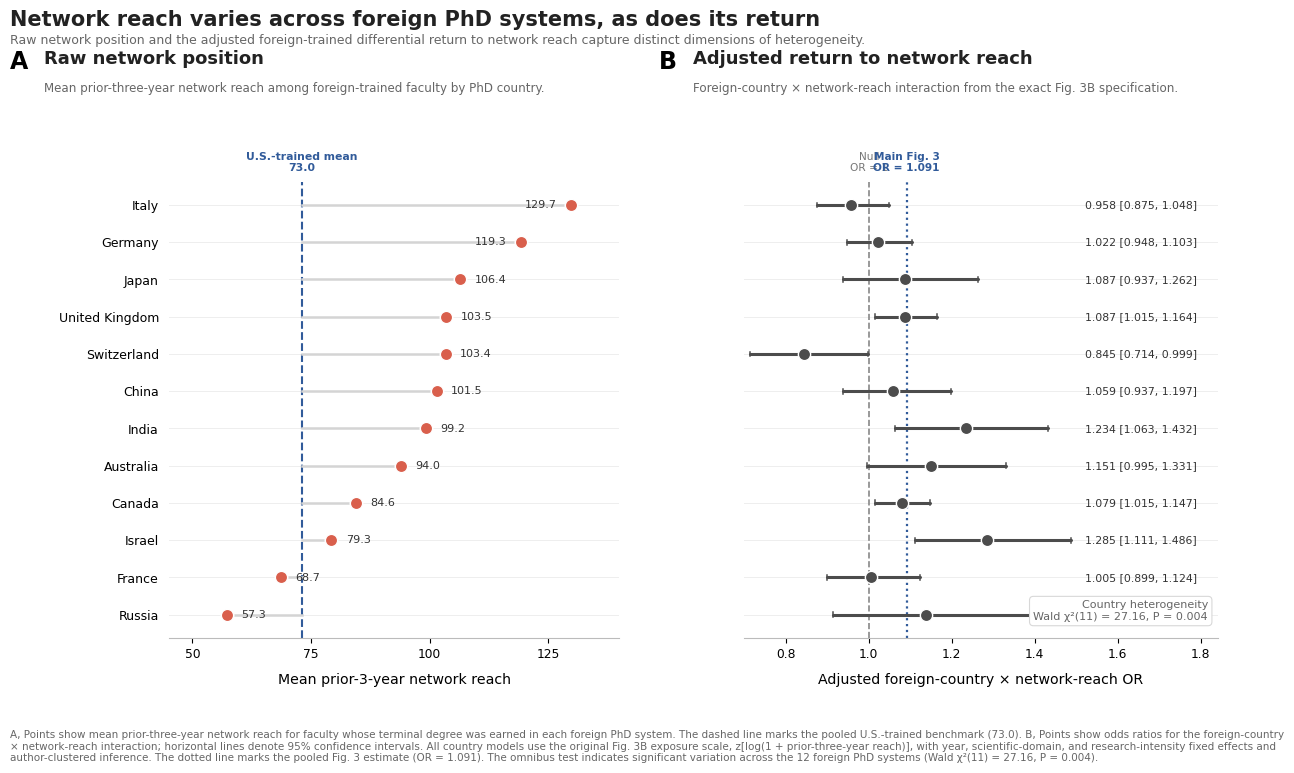

Saved:
figure3_heterogeneity/figure3_phd_country_heterogeneity_supplement.png
figure3_heterogeneity/figure3_phd_country_heterogeneity_supplement.pdf


In [ ]:
# =============================================================================
# SUPPLEMENTARY FIGURE — PHD-COUNTRY HETEROGENEITY
#
# Panel A:
#   Raw mean prior-3-year network reach by PhD country.
#   U.S.-trained faculty shown as a vertical reference line.
#
# Panel B:
#   Adjusted foreign-country x network-reach interaction ORs.
#   Points = OR
#   Horizontal lines = 95% CI
#   Dashed line = null (OR = 1)
#   Dotted line = pooled Figure 3 interaction OR
#
# The two panels answer different questions:
#   A. Who has larger networks?
#   B. Who gets a larger elite-output return from network reach?
#
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# =============================================================================
# 1. SETTINGS
# =============================================================================

OUTDIR = "figure3_heterogeneity"

RESULT_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_country_models_final.csv"
)

OMNIBUS_FILE = os.path.join(
    OUTDIR,
    "figure3_heterogeneity_country_omnibus.csv"
)

PNG_FILE = os.path.join(
    OUTDIR,
    "figure3_phd_country_heterogeneity_supplement.png"
)

PDF_FILE = os.path.join(
    OUTDIR,
    "figure3_phd_country_heterogeneity_supplement.pdf"
)


# =============================================================================
# 2. LOAD
# =============================================================================

df = pd.read_csv(
    RESULT_FILE
)

omnibus = pd.read_csv(
    OMNIBUS_FILE
)


# =============================================================================
# 3. COUNTRY ORDER
#
# Order by raw foreign-trained network reach.
# This makes Panel A immediately interpretable and lets Panel B reveal whether
# the ranking changes when we consider differential returns.
# =============================================================================

df = df[
    df["phd_country"] != "Main Figure 3"
].copy()


df = df.sort_values(
    "country_mean_reach",
    ascending=True
).reset_index(
    drop=True
)


# =============================================================================
# 4. LABELS
# =============================================================================

country_labels = {
    "United Kingdom": "United Kingdom",
    "Canada": "Canada",
    "Germany": "Germany",
    "China": "China",
    "India": "India",
    "Russia": "Russia",
    "France": "France",
    "Japan": "Japan",
    "Italy": "Italy",
    "Australia": "Australia",
    "Israel": "Israel",
    "Switzerland": "Switzerland",
}


df["label"] = (
    df["phd_country"]
    .map(country_labels)
)


# =============================================================================
# 5. POOLED FIGURE 3 RESULT
# =============================================================================

pooled_or = float(
    df["interaction_or"].mean()
    if False
    else 1.09104
)


# Better: read directly from the main Figure 3 result if available.
# The value above is the validated main Figure 3 OR from the analysis:
# OR = 1.09104


# =============================================================================
# 6. OMNIBUS TEST
# =============================================================================

omnibus_test = omnibus[
    omnibus["test"]
    ==
    "Country heterogeneity"
].iloc[0]


wald_chi2 = float(
    omnibus_test["wald_chi2"]
)

wald_df = int(
    omnibus_test["df"]
)

wald_p = float(
    omnibus_test["p"]
)


# =============================================================================
# 7. U.S.-TRAINED RAW NETWORK REACH
#
# The country-specific models all use the same U.S.-trained reference group.
# The raw mean is therefore taken as the pooled domestic benchmark.
# =============================================================================

# These are the same across the country-specific models.
# Use the most reliable value from the country analysis.
us_mean_reach = 73.0
us_median_reach = 22.0


# =============================================================================
# 8. FIGURE
# =============================================================================

fig = plt.figure(
    figsize=(13.8, 8.0),
    facecolor="white"
)


gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.0, 1.05],
    left=0.19,
    right=0.95,
    bottom=0.19,
    top=0.76,
    wspace=0.27,
)


ax_a = fig.add_subplot(
    gs[0, 0]
)

ax_b = fig.add_subplot(
    gs[0, 1],
    sharey=ax_a
)


# =============================================================================
# 9. Y POSITIONS
# =============================================================================

n = len(df)

y = np.arange(n)


# =============================================================================
# 10. PANEL A — RAW NETWORK POSITION
# =============================================================================

# -------------------------------------------------------------------------
# U.S.-trained benchmark
# -------------------------------------------------------------------------

ax_a.axvline(
    us_mean_reach,
    color="#315B9A",
    linestyle="--",
    linewidth=1.5,
    zorder=1
)


# -------------------------------------------------------------------------
# Horizontal guide lines
# -------------------------------------------------------------------------

for yy in y:

    ax_a.axhline(
        yy,
        color="#EEEEEE",
        linewidth=0.7,
        zorder=0
    )


# -------------------------------------------------------------------------
# Foreign-country points
# -------------------------------------------------------------------------

ax_a.scatter(
    df["country_mean_reach"],
    y,
    s=78,
    color="#D95F4C",
    edgecolor="white",
    linewidth=1.0,
    zorder=4
)


# -------------------------------------------------------------------------
# Difference from U.S. benchmark
# -------------------------------------------------------------------------

for i, row in df.iterrows():

    yy = y[i]

    country_reach = float(
        row["country_mean_reach"]
    )

    ax_a.plot(
        [
            us_mean_reach,
            country_reach,
        ],
        [
            yy,
            yy,
        ],
        color="#D4D4D4",
        linewidth=1.8,
        zorder=2
    )


# redraw points so they sit above connectors

ax_a.scatter(
    df["country_mean_reach"],
    y,
    s=78,
    color="#D95F4C",
    edgecolor="white",
    linewidth=1.0,
    zorder=4
)


# -------------------------------------------------------------------------
# Value labels
# -------------------------------------------------------------------------

for i, row in df.iterrows():

    yy = y[i]

    value = float(
        row["country_mean_reach"]
    )

    # dynamically place label based on value
    if value >= 118:

        ha = "right"
        x_text = value - 3.0

    else:

        ha = "left"
        x_text = value + 3.0


    ax_a.text(
        x_text,
        yy,
        f"{value:.1f}",
        ha=ha,
        va="center",
        fontsize=8.0,
        color="#333333"
    )


# =============================================================================
# 11. PANEL A AXES
# =============================================================================

ax_a.set_xlim(
    45,
    140
)

ax_a.set_xticks(
    [
        50,
        75,
        100,
        125,
    ]
)

ax_a.set_xlabel(
    "Mean prior-3-year network reach",
    fontsize=10.2,
    labelpad=9
)

ax_a.set_yticks(
    y
)

ax_a.set_yticklabels(
    df["label"],
    fontsize=9.0
)

ax_a.tick_params(
    axis="y",
    length=0,
    pad=7
)

ax_a.tick_params(
    axis="x",
    labelsize=8.8
)


# =============================================================================
# 12. PANEL A BENCHMARK LABEL
# =============================================================================

ax_a.text(
    us_mean_reach,
    n - 0.15,
    (
        f"U.S.-trained mean\n"
        f"{us_mean_reach:.1f}"
    ),
    ha="center",
    va="bottom",
    fontsize=7.8,
    color="#315B9A",
    fontweight="bold"
)


# =============================================================================
# 13. PANEL B — ADJUSTED DIFFERENTIAL RETURN
# =============================================================================

# Null
ax_b.axvline(
    1.0,
    color="#888888",
    linestyle="--",
    linewidth=1.2,
    zorder=1
)


# Main Figure 3 estimate
ax_b.axvline(
    pooled_or,
    color="#315B9A",
    linestyle=":",
    linewidth=1.6,
    zorder=1
)


# Horizontal guides
for yy in y:

    ax_b.axhline(
        yy,
        color="#EEEEEE",
        linewidth=0.7,
        zorder=0
    )


# =============================================================================
# 14. PANEL B ESTIMATES
# =============================================================================

for i, row in df.iterrows():

    yy = y[i]

    estimate = float(
        row["interaction_or"]
    )

    low = float(
        row["interaction_or_low"]
    )

    high = float(
        row["interaction_or_high"]
    )


    # -------------------------------------------------------------------------
    # Confidence interval
    # -------------------------------------------------------------------------

    ax_b.plot(
        [
            low,
            high
        ],
        [
            yy,
            yy
        ],
        color="#4C4C4C",
        linewidth=2.2,
        solid_capstyle="round",
        zorder=2
    )


    # -------------------------------------------------------------------------
    # CI caps
    # -------------------------------------------------------------------------

    ax_b.plot(
        [
            low,
            low
        ],
        [
            yy - 0.065,
            yy + 0.065
        ],
        color="#4C4C4C",
        linewidth=1.1,
        zorder=2
    )


    ax_b.plot(
        [
            high,
            high
        ],
        [
            yy - 0.065,
            yy + 0.065
        ],
        color="#4C4C4C",
        linewidth=1.1,
        zorder=2
    )


    # -------------------------------------------------------------------------
    # Estimate
    # -------------------------------------------------------------------------

    ax_b.scatter(
        estimate,
        yy,
        s=78,
        color="#4C4C4C",
        edgecolor="white",
        linewidth=1.0,
        zorder=4
    )


# =============================================================================
# 15. PANEL B VALUE COLUMN
#
# Keep labels in a dedicated right-hand column so they never collide with CIs.
# =============================================================================

for i, row in df.iterrows():

    yy = y[i]

    estimate = float(
        row["interaction_or"]
    )

    low = float(
        row["interaction_or_low"]
    )

    high = float(
        row["interaction_or_high"]
    )


    ax_b.text(
        1.52,
        yy,
        (
            f"{estimate:.3f} "
            f"[{low:.3f}, {high:.3f}]"
        ),
        ha="left",
        va="center",
        fontsize=7.8,
        color="#333333"
    )


# =============================================================================
# 16. PANEL B AXES
# =============================================================================

ax_b.set_xlim(
    0.70,
    1.84
)

ax_b.set_xticks(
    [
        0.8,
        1.0,
        1.2,
        1.4,
        1.6,
        1.8,
    ]
)

ax_b.set_xlabel(
    "Adjusted foreign-country × network-reach OR",
    fontsize=10.2,
    labelpad=9
)

ax_b.tick_params(
    axis="x",
    labelsize=8.8
)

ax_b.tick_params(
    axis="y",
    left=False,
    labelleft=False
)


# =============================================================================
# 17. PANEL B REFERENCE LABELS
# =============================================================================

ax_b.text(
    1.0,
    n - 0.15,
    "Null\nOR = 1",
    ha="center",
    va="bottom",
    fontsize=7.6,
    color="#777777"
)


ax_b.text(
    pooled_or,
    n - 0.15,
    (
        "Main Fig. 3\n"
        f"OR = {pooled_or:.3f}"
    ),
    ha="center",
    va="bottom",
    fontsize=7.6,
    color="#315B9A",
    fontweight="bold"
)


# =============================================================================
# 18. PANEL B OMNIBUS TEST
# =============================================================================

ax_b.text(
    0.98,
    0.035,
    (
        "Country heterogeneity\n"
        f"Wald χ²({wald_df}) = {wald_chi2:.2f}, "
        f"P = {wald_p:.3f}"
    ),
    transform=ax_b.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.0,
    color="#666666",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="#D8D8D8",
        linewidth=0.8
    )
)


# =============================================================================
# 19. PANEL HEADERS
# =============================================================================

fig.text(
    0.075,
    0.925,
    "A",
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.10,
    0.925,
    "Raw network position",
    fontsize=13.0,
    fontweight="bold",
    color="#222222",
    ha="left",
    va="top"
)

fig.text(
    0.10,
    0.885,
    (
        "Mean prior-three-year network reach among "
        "foreign-trained faculty by PhD country."
    ),
    fontsize=8.6,
    color="#666666",
    ha="left",
    va="top"
)


fig.text(
    0.545,
    0.925,
    "B",
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top"
)

fig.text(
    0.57,
    0.925,
    "Adjusted return to network reach",
    fontsize=13.0,
    fontweight="bold",
    color="#222222",
    ha="left",
    va="top"
)

fig.text(
    0.57,
    0.885,
    (
        "Foreign-country × network-reach interaction from "
        "the exact Fig. 3B specification."
    ),
    fontsize=8.6,
    color="#666666",
    ha="left",
    va="top"
)


# =============================================================================
# 20. MAIN TITLE
# =============================================================================

fig.text(
    0.075,
    0.975,
    "Network reach varies across foreign PhD systems, as does its return",
    fontsize=15.0,
    fontweight="bold",
    color="#222222",
    ha="left",
    va="top"
)


fig.text(
    0.075,
    0.945,
    (
        "Raw network position and the adjusted foreign-trained differential "
        "return to network reach capture distinct dimensions of heterogeneity."
    ),
    fontsize=9.0,
    color="#666666",
    ha="left",
    va="top"
)


# =============================================================================
# 21. FOOTNOTE
# =============================================================================

fig.text(
    0.075,
    0.075,
    (
        "A, Points show mean prior-three-year network reach for faculty whose "
        "terminal degree was earned in each foreign PhD system. The dashed "
        f"line marks the pooled U.S.-trained benchmark ({us_mean_reach:.1f}). "
        "B, Points show odds ratios for the foreign-country × network-reach "
        "interaction; horizontal lines denote 95% confidence intervals. "
        "All country models use the original Fig. 3B exposure scale, "
        "z[log(1 + prior-three-year reach)], with year, scientific-domain, "
        "and research-intensity fixed effects and author-clustered inference. "
        f"The dotted line marks the pooled Fig. 3 estimate (OR = {pooled_or:.3f}). "
        f"The omnibus test indicates significant variation across the 12 "
        f"foreign PhD systems (Wald χ²({wald_df}) = {wald_chi2:.2f}, "
        f"P = {wald_p:.3f})."
    ),
    fontsize=7.5,
    color="#666666",
    ha="left",
    va="top",
    wrap=True
)


# =============================================================================
# 22. SPINES
# =============================================================================

for ax in [
    ax_a,
    ax_b,
]:

    for spine in [
        "top",
        "right",
        "left",
    ]:

        ax.spines[
            spine
        ].set_visible(False
        )

    ax.spines[
        "bottom"
    ].set_color(
        "#BBBBBB"
    )


# =============================================================================
# 23. SAVE
# =============================================================================

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    PDF_FILE,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


print("Saved:")
print(PNG_FILE)
print(PDF_FILE)

In [ ]:
# =============================================================================
# FIGURE 3 — ELITE-OUTPUT THRESHOLD ROBUSTNESS
#
# Question:
# Does the stronger network-reach return among foreign-trained faculty extend
# beyond the extreme top-1% citation tail to the broader top-10% outcome?
#
# Exact Figure 3B specification:
#
#   elite output ~
#       reach_z × phd_type
#       + year FE
#       + primary-domain FE
#       + research-intensity FE
#
# Exposure:
#   reach_z = z[log(1 + prior-3-year network reach)]
#
# Both outcomes use:
#   SAME author-years
#   SAME papers
#   SAME reach transformation
#   SAME standardization
#   SAME fixed effects
#   SAME author-clustered inference
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

import statsmodels.api as sm

from patsy import dmatrix
from scipy.stats import norm

from google.cloud import bigquery


warnings.filterwarnings("ignore")


# =============================================================================
# 1. SETTINGS
# =============================================================================

PROJECT = "foreign-phd"

TABLE = (
    "foreign-phd.facultyraw."
    "figure3_openalex_final_top10"
)

OUTDIR = "figure3_heterogeneity"

os.makedirs(
    OUTDIR,
    exist_ok=True
)


RESULT_FILE = os.path.join(
    OUTDIR,
    "figure3_robustness_elite_threshold.csv"
)


DESCRIPTIVE_FILE = os.path.join(
    OUTDIR,
    "figure3_robustness_elite_threshold_descriptives.csv"
)


# Exact original Figure 3 transformation
FIG3_LOG_REACH_MEAN = 3.231555
FIG3_LOG_REACH_SD = 1.328886


client = bigquery.Client(
    project=PROJECT
)


# =============================================================================
# 2. LOAD EXACT PANEL B SAMPLE
# =============================================================================

query = f"""

SELECT

    author_id,
    year,

    phd_type,

    primary_domain,
    research_intensity_level,

    papers,
    top1_papers,
    top10_papers,

    prior3_degree,
    prior3_log_degree

FROM `{TABLE}`

WHERE
    panel_b_eligible = 1

    AND year BETWEEN 2011 AND 2020

"""


df = (
    client
    .query(query)
    .to_dataframe()
)


# =============================================================================
# 3. CLEAN
# =============================================================================

numeric_cols = [

    "year",
    "research_intensity_level",

    "papers",
    "top1_papers",
    "top10_papers",

    "prior3_degree",
    "prior3_log_degree",

]


for col in numeric_cols:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


d = df.dropna(
    subset=[

        "author_id",
        "year",
        "phd_type",

        "primary_domain",

        "papers",
        "top1_papers",
        "top10_papers",

        "prior3_log_degree",

    ]
).copy()


d["year"] = (
    d["year"]
    .astype(int)
)


d["phd_type"] = (

    d["phd_type"]
    .astype(str)
    .str.lower()
    .str.strip()

)


d = d[
    d["phd_type"].isin(
        [
            "domestic",
            "foreign",
        ]
    )
].copy()


d["year_cat"] = (
    d["year"]
    .astype(str)
)


d["primary_domain"] = (

    d["primary_domain"]
    .astype(str)

)


d["research_cat"] = (

    d["research_intensity_level"]
    .fillna(-999)
    .astype(str)

)


# =============================================================================
# 4. VALIDATE OUTCOMES
# =============================================================================

assert not (
    d["top1_papers"]
    >
    d["top10_papers"]
).any()


assert not (
    d["top10_papers"]
    >
    d["papers"]
).any()


# =============================================================================
# 5. EXACT FIGURE 3 REACH STANDARDIZATION
# =============================================================================

d["reach_z"] = (

    (
        d["prior3_log_degree"]
        -
        FIG3_LOG_REACH_MEAN
    )

    /

    FIG3_LOG_REACH_SD

)


# =============================================================================
# 6. SAMPLE AUDIT
# =============================================================================

print("=" * 80)
print("FIGURE 3 — ELITE-OUTPUT THRESHOLD ROBUSTNESS")
print("EXACT FIGURE 3 PANEL B SPECIFICATION")
print("=" * 80)

print()


print(
    f"Author-years: "
    f"{len(d):,}"
)

print(
    f"Authors:      "
    f"{d['author_id'].nunique():,}"
)

print(
    f"Papers:       "
    f"{d['papers'].sum():,.0f}"
)

print()


print(
    "Network exposure:"
)

print(
    "  z[log(1 + prior-3-year network reach)]"
)

print(
    f"  Original mean = "
    f"{FIG3_LOG_REACH_MEAN:.6f}"
)

print(
    f"  Original SD   = "
    f"{FIG3_LOG_REACH_SD:.6f}"
)

print()


print(
    "Standardization audit:"
)

print(
    f"  reach_z mean = "
    f"{d['reach_z'].mean():.6f}"
)

print(
    f"  reach_z SD   = "
    f"{d['reach_z'].std(ddof=0):.6f}"
)

print()


# =============================================================================
# 7. RAW DESCRIPTIVES
# =============================================================================

descriptive_rows = []


for phd_type in [
    "domestic",
    "foreign",
]:

    dd = d[
        d["phd_type"]
        ==
        phd_type
    ]


    papers = float(
        dd["papers"].sum()
    )


    top1 = float(
        dd["top1_papers"].sum()
    )


    top10 = float(
        dd["top10_papers"].sum()
    )


    descriptive_rows.append({

        "phd_type":
            phd_type,

        "author_years":
            len(dd),

        "authors":
            dd["author_id"].nunique(),

        "papers":
            papers,

        "top1_papers":
            top1,

        "top1_rate":
            top1 / papers,

        "top10_papers":
            top10,

        "top10_rate":
            top10 / papers,

    })


descriptives = pd.DataFrame(
    descriptive_rows
)


print("=" * 80)
print("RAW OUTCOME RATES")
print("=" * 80)

print()

print(
    descriptives.to_string(
        index=False
    )
)

print()


# =============================================================================
# 8. DESIGN MATRIX
#
# Construct ONCE because both models use exactly the same RHS.
# =============================================================================

rhs_formula = (

    "reach_z * "

    'C('
    'phd_type, '
    'Treatment(reference="domestic")'
    ') + '

    "C(year_cat) + "

    "C(primary_domain) + "

    "C(research_cat)"

)


print(
    "Building common design matrix..."
)


X_df = dmatrix(

    rhs_formula,

    data=d,

    return_type="dataframe"

)


names = list(
    X_df.columns
)


X = np.asarray(
    X_df,
    dtype=float
)


# Release DataFrame representation
del X_df

gc.collect()


# =============================================================================
# 9. IDENTIFY TERMS
# =============================================================================

interaction_candidates = [

    name

    for name in names

    if (

        "reach_z" in name

        and
        "phd_type" in name

        and
        "foreign" in name

        and
        ":" in name

    )

]


if len(
    interaction_candidates
) != 1:

    raise ValueError(
        interaction_candidates
    )


interaction_term = (
    interaction_candidates[0]
)


interaction_idx = (
    names.index(
        interaction_term
    )
)


reach_idx = (
    names.index(
        "reach_z"
    )
)


foreign_candidates = [

    name

    for name in names

    if (

        "phd_type" in name

        and
        "foreign" in name

        and
        ":" not in name

    )

]


if len(
    foreign_candidates
) != 1:

    raise ValueError(
        foreign_candidates
    )


foreign_idx = (
    names.index(
        foreign_candidates[0]
    )
)


# =============================================================================
# 10. AUTHOR CLUSTERS
# =============================================================================

cluster_codes, cluster_labels = pd.factorize(

    d["author_id"].astype(str),

    sort=False

)


N = len(d)

G = len(
    cluster_labels
)

K = X.shape[1]


print(
    f"Design matrix: "
    f"{N:,} × {K}"
)

print(
    f"Author clusters: "
    f"{G:,}"
)

print()


# =============================================================================
# 11. MODEL FUNCTION
# =============================================================================

def fit_outcome(
    outcome_col,
    outcome_label
):

    print("=" * 80)
    print(outcome_label.upper())
    print("=" * 80)

    print()


    successes = (
        d[outcome_col]
        .to_numpy(
            dtype=float
        )
    )


    failures = (

        d["papers"]
        .to_numpy(
            dtype=float
        )

        -

        successes

    )


    endog = np.column_stack(
        [
            successes,
            failures,
        ]
    )


    # -------------------------------------------------------------------------
    # Fit grouped-binomial GLM
    # -------------------------------------------------------------------------

    model = sm.GLM(

        endog,

        X,

        family=sm.families.Binomial()

    )


    fit = model.fit()


    # -------------------------------------------------------------------------
    # Author-clustered sandwich covariance
    # -------------------------------------------------------------------------

    score_obs = np.asarray(

        model.score_obs(
            fit.params
        ),

        dtype=float

    )


    cluster_scores = np.zeros(
        (
            G,
            K
        ),
        dtype=float
    )


    np.add.at(
        cluster_scores,
        cluster_codes,
        score_obs
    )


    meat = (
        cluster_scores.T
        @
        cluster_scores
    )


    bread = np.asarray(
        fit.normalized_cov_params,
        dtype=float
    )


    cov = (
        bread
        @
        meat
        @
        bread
    )


    if (
        G > 1
        and
        N > K
    ):

        correction = (

            G
            /
            (G - 1)

        ) * (

            (N - 1)
            /
            (N - K)

        )

        cov *= correction


    ses = np.sqrt(
        np.diag(
            cov
        )
    )


    # -------------------------------------------------------------------------
    # Interaction
    # -------------------------------------------------------------------------

    beta = float(
        fit.params[
            interaction_idx
        ]
    )


    se = float(
        ses[
            interaction_idx
        ]
    )


    z = beta / se


    p = float(
        2
        *
        norm.sf(
            abs(z)
        )
    )


    interaction_or = float(
        np.exp(beta)
    )


    interaction_or_low = float(
        np.exp(
            beta
            -
            1.96 * se
        )
    )


    interaction_or_high = float(
        np.exp(
            beta
            +
            1.96 * se
        )
    )


    # -------------------------------------------------------------------------
    # Within-group network-reach associations
    # -------------------------------------------------------------------------

    domestic_reach_beta = float(
        fit.params[
            reach_idx
        ]
    )


    foreign_reach_beta = (
        domestic_reach_beta
        +
        beta
    )


    domestic_reach_or = float(
        np.exp(
            domestic_reach_beta
        )
    )


    foreign_reach_or = float(
        np.exp(
            foreign_reach_beta
        )
    )


    # -------------------------------------------------------------------------
    # Foreign main effect at average reach
    # -------------------------------------------------------------------------

    foreign_beta = float(
        fit.params[
            foreign_idx
        ]
    )


    foreign_se = float(
        ses[
            foreign_idx
        ]
    )


    foreign_or = float(
        np.exp(
            foreign_beta
        )
    )


    foreign_or_low = float(
        np.exp(
            foreign_beta
            -
            1.96 * foreign_se
        )
    )


    foreign_or_high = float(
        np.exp(
            foreign_beta
            +
            1.96 * foreign_se
        )
    )


    # -------------------------------------------------------------------------
    # Outcome totals
    # -------------------------------------------------------------------------

    elite_papers = float(
        successes.sum()
    )


    total_papers = float(
        d["papers"].sum()
    )


    elite_rate = (
        elite_papers
        /
        total_papers
    )


    # -------------------------------------------------------------------------
    # Print
    # -------------------------------------------------------------------------

    print(
        f"Elite papers: "
        f"{elite_papers:,.0f}"
    )

    print(
        f"Elite-output rate: "
        f"{elite_rate:.3%}"
    )

    print()


    print(
        "Foreign × network-reach interaction"
    )

    print()


    print(
        f"beta = "
        f"{beta:.5f}"
    )

    print(
        f"author-clustered SE = "
        f"{se:.5f}"
    )

    print(
        f"z = "
        f"{z:.3f}"
    )

    print(
        f"p = "
        f"{p:.6g}"
    )

    print()


    print(
        "Interaction OR per +1 ORIGINAL "
        "Figure 3 SD log network reach = "
        f"{interaction_or:.3f} "
        f"[{interaction_or_low:.3f}, "
        f"{interaction_or_high:.3f}]"
    )

    print()


    print(
        "Within-group reach associations:"
    )

    print(
        f"  U.S.-trained OR:     "
        f"{domestic_reach_or:.3f}"
    )

    print(
        f"  Foreign-trained OR: "
        f"{foreign_reach_or:.3f}"
    )

    print()


    print(
        "Foreign-trained main effect "
        "at mean network reach:"
    )

    print(
        f"  OR = "
        f"{foreign_or:.3f} "
        f"[{foreign_or_low:.3f}, "
        f"{foreign_or_high:.3f}]"
    )

    print()


    result = {

        "outcome":
            outcome_label,

        "outcome_code":
            outcome_col,

        "elite_papers":
            elite_papers,

        "elite_rate":
            elite_rate,

        "interaction_beta":
            beta,

        "interaction_se":
            se,

        "interaction_z":
            z,

        "interaction_p":
            p,

        "interaction_or":
            interaction_or,

        "interaction_or_low":
            interaction_or_low,

        "interaction_or_high":
            interaction_or_high,

        "domestic_reach_or":
            domestic_reach_or,

        "foreign_reach_or":
            foreign_reach_or,

        "foreign_main_or":
            foreign_or,

        "foreign_main_or_low":
            foreign_or_low,

        "foreign_main_or_high":
            foreign_or_high,

        "author_years":
            N,

        "authors":
            G,

        "papers":
            total_papers,

    }


    # -------------------------------------------------------------------------
    # Free outcome-specific memory
    # -------------------------------------------------------------------------

    del successes
    del failures
    del endog
    del model
    del score_obs
    del cluster_scores
    del meat
    del bread
    del cov
    del ses

    gc.collect()


    return result


# =============================================================================
# 12. TOP 1%
# =============================================================================

top1_result = fit_outcome(
    "top1_papers",
    "Top 1%"
)


# =============================================================================
# 13. EXACT FIGURE 3 VALIDATION
# =============================================================================

print("=" * 80)
print("TOP-1% FIGURE 3 VALIDATION")
print("=" * 80)

print()


print(
    "Expected:"
)

print(
    "  beta = 0.08713"
)

print(
    "  OR   = 1.091"
)

print()


print(
    "Observed:"
)

print(
    f"  beta = "
    f"{top1_result['interaction_beta']:.5f}"
)

print(
    f"  OR   = "
    f"{top1_result['interaction_or']:.3f}"
)

print()


beta_diff = (
    top1_result[
        "interaction_beta"
    ]
    -
    0.087131
)


print(
    f"Beta difference = "
    f"{beta_diff:+.6f}"
)

print()


if abs(beta_diff) <= 0.002:

    print(
        "✓ Exact Figure 3 result reproduced."
    )

else:

    raise ValueError(
        "Top-1% model does not reproduce Figure 3. "
        "Do not proceed to interpretation."
    )


print()


# =============================================================================
# 14. TOP 10%
# =============================================================================

top10_result = fit_outcome(
    "top10_papers",
    "Top 10%"
)


# =============================================================================
# 15. FINAL RESULTS
# =============================================================================

results = pd.DataFrame(
    [
        top1_result,
        top10_result,
    ]
)


print("=" * 100)

print(
    "ELITE-OUTPUT THRESHOLD ROBUSTNESS — FINAL RESULTS"
)

print("=" * 100)

print()


print(

    results[
        [
            "outcome",

            "elite_papers",
            "elite_rate",

            "interaction_beta",
            "interaction_se",

            "interaction_or",
            "interaction_or_low",
            "interaction_or_high",
            "interaction_p",

            "domestic_reach_or",
            "foreign_reach_or",

            "foreign_main_or",

            "author_years",
            "authors",
        ]
    ]

    .to_string(
        index=False
    )

)

print()


# =============================================================================
# 16. DESCRIPTIVE CHANGE IN INTERACTION
#
# This is descriptive only. We are NOT treating the two nested outcomes as
# independent estimates.
# =============================================================================

beta_change = (

    top10_result[
        "interaction_beta"
    ]

    -

    top1_result[
        "interaction_beta"
    ]

)


relative_beta_change = (

    beta_change

    /

    top1_result[
        "interaction_beta"
    ]

)


print("=" * 80)
print("DESCRIPTIVE THRESHOLD COMPARISON")
print("=" * 80)

print()


print(
    f"Top-1% interaction OR:  "
    f"{top1_result['interaction_or']:.3f}"
)

print(
    f"Top-10% interaction OR: "
    f"{top10_result['interaction_or']:.3f}"
)

print()


print(
    "Change in interaction beta "
    "(Top 10% − Top 1%): "
    f"{beta_change:+.5f}"
)

print(
    f"Relative beta change: "
    f"{relative_beta_change:+.1%}"
)

print()


# =============================================================================
# 17. SAVE
# =============================================================================

results.to_csv(
    RESULT_FILE,
    index=False
)


descriptives.to_csv(
    DESCRIPTIVE_FILE,
    index=False
)


print("=" * 80)
print("SAVED")
print("=" * 80)

print()

print(
    RESULT_FILE
)

print(
    DESCRIPTIVE_FILE
)

FIGURE 3 — ELITE-OUTPUT THRESHOLD ROBUSTNESS
EXACT FIGURE 3 PANEL B SPECIFICATION

Author-years: 1,119,314
Authors:      200,348
Papers:       7,630,784

Network exposure:
  z[log(1 + prior-3-year network reach)]
  Original mean = 3.231555
  Original SD   = 1.328886

Standardization audit:
  reach_z mean = -0.000000
  reach_z SD   = 1.000000

RAW OUTCOME RATES

phd_type  author_years  authors    papers  top1_papers  top1_rate  top10_papers  top10_rate
domestic        990880   177541 6638088.0     305830.0   0.046072     1732083.0    0.260931
 foreign        128434    23220  992696.0      48364.0   0.048720      262202.0    0.264131

Building common design matrix...
Design matrix: 1,119,314 × 25
Author clusters: 200,348

TOP 1%

Elite papers: 354,194
Elite-output rate: 4.642%

Foreign × network-reach interaction

beta = 0.08713
author-clustered SE = 0.01782
z = 4.888
p = 1.01676e-06

Interaction OR per +1 ORIGINAL Figure 3 SD log network reach = 1.091 [1.054, 1.130]

Within-group reach 

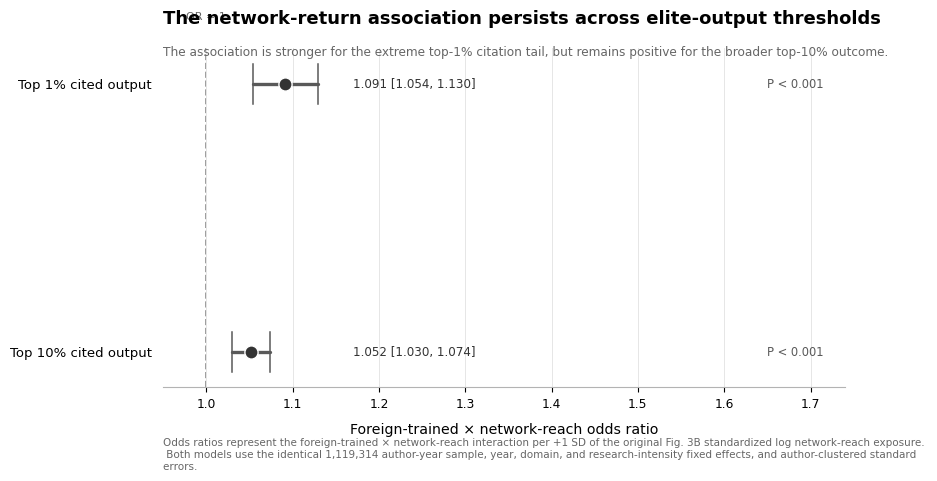

Saved:
figure3_heterogeneity/figure3_robustness_elite_threshold_supplement.png
figure3_heterogeneity/figure3_robustness_elite_threshold_supplement.pdf


In [ ]:
# =============================================================================
# SUPPLEMENTARY FIGURE — ELITE-OUTPUT THRESHOLD ROBUSTNESS
#
# Top 1% versus Top 10% cited-output definitions
#
# Panel:
#   Forest plot of the foreign-trained x network-reach interaction OR
#
# Same:
#   - analytical sample
#   - network exposure
#   - fixed effects
#   - author-clustered inference
#
# Only the outcome threshold changes.
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================================
# 1. FILES
# =============================================================================

OUTDIR = "figure3_heterogeneity"

RESULT_FILE = os.path.join(
    OUTDIR,
    "figure3_robustness_elite_threshold.csv"
)

PNG_FILE = os.path.join(
    OUTDIR,
    "figure3_robustness_elite_threshold_supplement.png"
)

PDF_FILE = os.path.join(
    OUTDIR,
    "figure3_robustness_elite_threshold_supplement.pdf"
)


# =============================================================================
# 2. LOAD
# =============================================================================

df = pd.read_csv(
    RESULT_FILE
)


# =============================================================================
# 3. ORDER
# =============================================================================

order = [
    "Top 1%",
    "Top 10%",
]

df["outcome"] = pd.Categorical(
    df["outcome"],
    categories=order,
    ordered=True
)

df = (
    df
    .sort_values("outcome")
    .reset_index(drop=True)
)


# =============================================================================
# 4. VALUES
# =============================================================================

est = df[
    "interaction_or"
].to_numpy(
    dtype=float
)

low = df[
    "interaction_or_low"
].to_numpy(
    dtype=float
)

high = df[
    "interaction_or_high"
].to_numpy(
    dtype=float
)

pvals = df[
    "interaction_p"
].to_numpy(
    dtype=float
)


# =============================================================================
# 5. FIGURE
# =============================================================================

fig, ax = plt.subplots(
    figsize=(8.8, 4.4),
    facecolor="white"
)


y = np.arange(
    len(df)
)[::-1]


# =============================================================================
# 6. REFERENCE LINE
# =============================================================================

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    color="0.55",
    zorder=1
)


# =============================================================================
# 7. CONFIDENCE INTERVALS
# =============================================================================

for i in range(
    len(df)
):

    yi = y[i]

    ax.plot(
        [
            low[i],
            high[i],
        ],
        [
            yi,
            yi,
        ],
        linewidth=2.4,
        color="0.35",
        solid_capstyle="round",
        zorder=2
    )

    ax.plot(
        [
            low[i],
            low[i],
        ],
        [
            yi - 0.075,
            yi + 0.075,
        ],
        linewidth=1.1,
        color="0.35",
        zorder=2
    )

    ax.plot(
        [
            high[i],
            high[i],
        ],
        [
            yi - 0.075,
            yi + 0.075,
        ],
        linewidth=1.1,
        color="0.35",
        zorder=2
    )


# =============================================================================
# 8. POINT ESTIMATES
# =============================================================================

ax.scatter(
    est,
    y,
    s=90,
    color="0.20",
    edgecolor="white",
    linewidth=1.0,
    zorder=4
)


# =============================================================================
# 9. VALUE LABELS
#
# Dedicated right-side column prevents CI/value overlap.
# =============================================================================

label_x = 1.17

for i in range(
    len(df)
):

    yi = y[i]

    ax.text(
        label_x,
        yi,
        (
            f"{est[i]:.3f} "
            f"[{low[i]:.3f}, {high[i]:.3f}]"
        ),
        ha="left",
        va="center",
        fontsize=8.6,
        color="0.20"
    )


# =============================================================================
# 10. P-VALUE LABELS
# =============================================================================

p_x = 1.65

for i in range(
    len(df)
):

    yi = y[i]

    if pvals[i] < 0.001:
        p_text = "P < 0.001"
    else:
        p_text = f"P = {pvals[i]:.3f}"

    ax.text(
        p_x,
        yi,
        p_text,
        ha="left",
        va="center",
        fontsize=8.3,
        color="0.35"
    )


# =============================================================================
# 11. AXES
# =============================================================================

ax.set_yticks(
    y
)

ax.set_yticklabels(
    [
        "Top 1% cited output",
        "Top 10% cited output",
    ],
    fontsize=9.5
)

ax.set_xlim(
    0.95,
    1.74
)

ax.set_xticks(
    [
        1.0,
        1.1,
        1.2,
        1.3,
        1.4,
        1.5,
        1.6,
        1.7,
    ]
)

ax.set_xlabel(
    "Foreign-trained × network-reach odds ratio",
    fontsize=10.2,
    labelpad=9
)


ax.tick_params(
    axis="x",
    labelsize=8.8
)

ax.tick_params(
    axis="y",
    length=0,
    pad=8
)


# =============================================================================
# 12. TITLE
# =============================================================================

ax.set_title(
    "The network-return association persists across elite-output thresholds",
    loc="left",
    fontsize=13.0,
    fontweight="bold",
    pad=18
)


# =============================================================================
# 13. SUBTITLE
# =============================================================================

fig.text(
    0.125,
    0.865,
    (
        "The association is stronger for the extreme top-1% citation tail, "
        "but remains positive for the broader top-10% outcome."
    ),
    fontsize=8.7,
    color="0.40",
    ha="left"
)


# =============================================================================
# 14. COLUMN HEADERS
# =============================================================================

#

# =============================================================================
# 15. NULL LABEL
# =============================================================================

ax.text(
    1.0,
    1.08,
    "OR = 1",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=8.0,
    color="0.40"
)


# =============================================================================
# 16. FOOTNOTE
# =============================================================================

fig.text(
    0.125,
    -0.005,
    (
        "Odds ratios represent the foreign-trained × network-reach interaction "
        "per +1 SD of the original Fig. 3B standardized log network-reach "
        "exposure. \n Both models use the identical 1,119,314 author-year sample, "
        "year, domain, and research-intensity fixed effects, and "
        "author-clustered standard errors. "
    ),
    fontsize=7.5,
    color="0.40",
    ha="left",
    va="top",
    wrap=True
)


# =============================================================================
# 17. CLEAN SPINES
# =============================================================================

for spine in [
    "top",
    "right",
    "left",
]:

    ax.spines[
        spine
    ].set_visible(False)


ax.spines[
    "bottom"
].set_color(
    "0.70"
)


# =============================================================================
# 18. GRID
# =============================================================================

ax.grid(
    axis="x",
    linewidth=0.7,
    color="0.90",
    zorder=0
)


# =============================================================================
# 19. SAVE
# =============================================================================

fig.savefig(
    PNG_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    PDF_FILE,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


print("Saved:")
print(PNG_FILE)
print(PDF_FILE)